In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Data paths
SILVER_PATH = Path('../data/lake/silver/domain1')
print(f'Loading from: {SILVER_PATH.absolute()}')

Loading from: c:\Users\USER\Documents\Python Projects\f1-strategy\notebooks\..\data\lake\silver\domain1


In [2]:
# Load the processed data
clean_air_laps = pd.read_parquet(SILVER_PATH / 'clean_air_laps.parquet')
stints = pd.read_parquet(SILVER_PATH / 'stints_degradation.parquet')

print(f'Clean-air laps: {len(clean_air_laps):,}')
print(f'Stints: {len(stints):,}')
print(f'Years: {sorted(stints["year"].unique())}')
print(f'Compounds: {sorted(stints["compound"].dropna().unique())}')

Clean-air laps: 28,819
Stints: 1,905
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Compounds: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'None', 'SOFT', 'WET']


## 1. Degradation Rate Overview

In [3]:
# Filter to good fits (R² > 0.3) and reasonable degradation
good_fits = stints[
    (stints['deg_r_squared'] > 0.3) & 
    (stints['deg_rate_per_lap'].abs() < 0.5)  # Less than 500ms/lap
].copy()

print(f'Good fits: {len(good_fits)} ({100*len(good_fits)/len(stints):.1f}%)')

# Convert to ms/lap
good_fits['deg_ms_per_lap'] = good_fits['deg_rate_per_lap'] * 1000

# Summary by compound
compound_summary = good_fits.groupby('compound').agg({
    'deg_ms_per_lap': ['mean', 'std', 'count'],
    'num_laps': 'mean',
    'deg_r_squared': 'mean'
}).round(2)
print('\nDegradation by Compound:')
compound_summary

Good fits: 755 (39.6%)

Degradation by Compound:


deg_ms_per_lap               num_laps deg_r_squared
                       mean     std count     mean          mean
compound                                                        
HARD                 -75.23  226.34   347    17.49          0.61
INTERMEDIATE        -126.48  240.71    40    16.00          0.73
MEDIUM               -49.54  230.44   274    15.09          0.61
SOFT                 -58.25  235.74    94    13.95          0.66

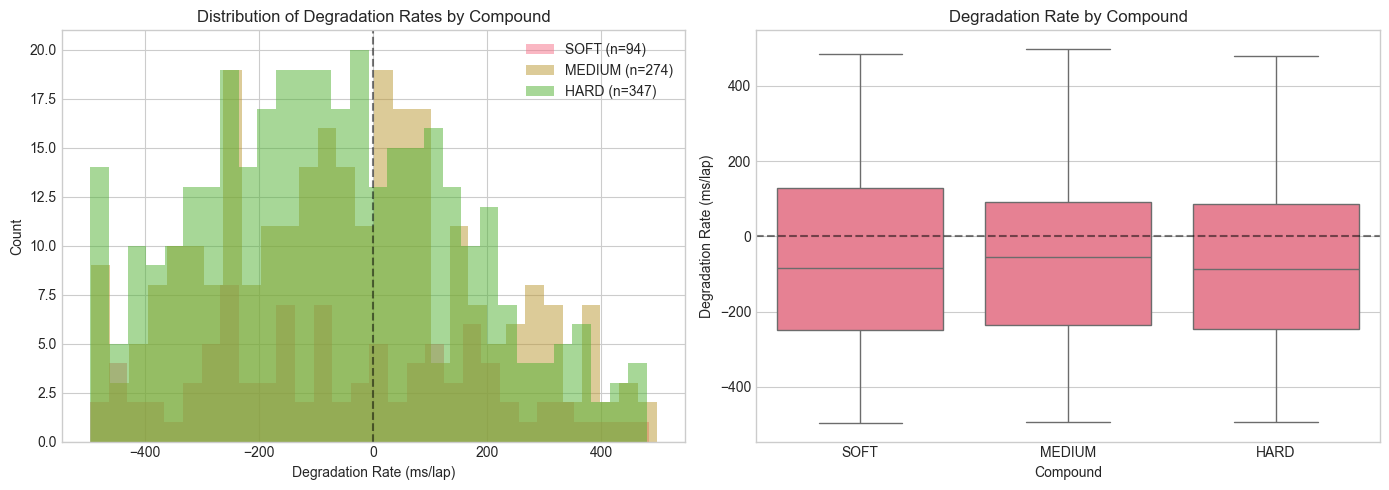

In [4]:
# Distribution of degradation rates by compound
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = good_fits[good_fits['compound'] == compound]['deg_ms_per_lap']
    if len(data) > 0:
        axes[0].hist(data, bins=30, alpha=0.5, label=f'{compound} (n={len(data)})')

axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Degradation Rate (ms/lap)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Degradation Rates by Compound')
axes[0].legend()

# Box plot
sns.boxplot(data=good_fits, x='compound', y='deg_ms_per_lap', 
            order=['SOFT', 'MEDIUM', 'HARD'], ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Compound')
axes[1].set_ylabel('Degradation Rate (ms/lap)')
axes[1].set_title('Degradation Rate by Compound')

plt.tight_layout()
plt.show()

## 2. Example Stint Degradation Curves

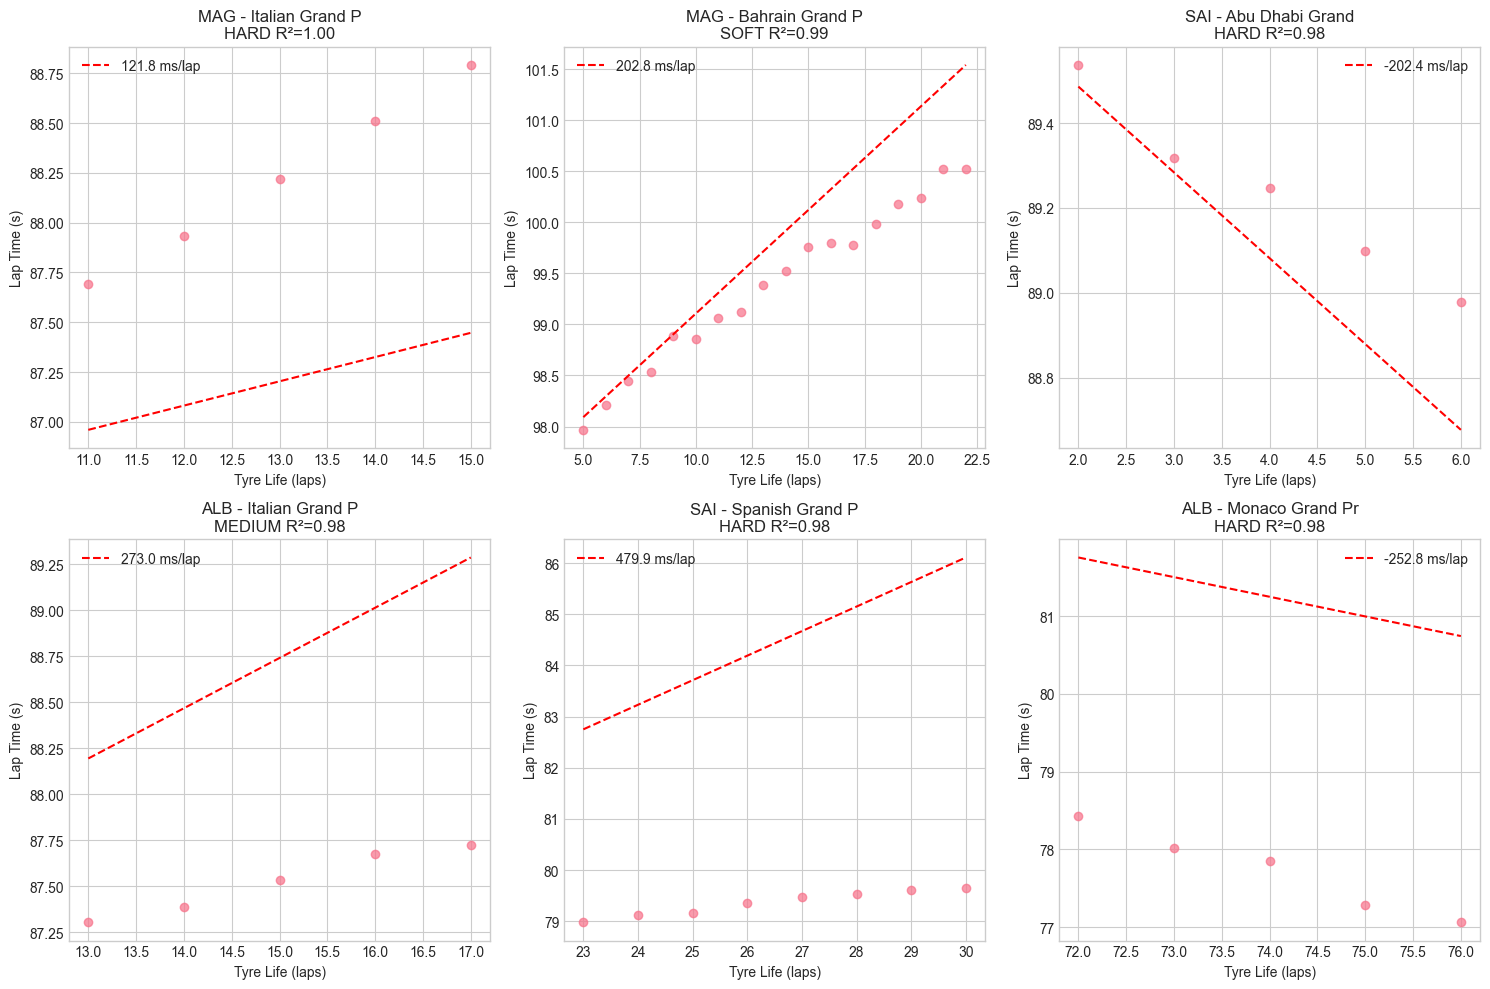

In [5]:
# Select some example stints with good fits
example_stints = good_fits.nlargest(6, 'deg_r_squared')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, stint) in enumerate(example_stints.iterrows()):
    # Get laps for this stint
    mask = (
        (clean_air_laps['session_id'] == stint['session_id']) &
        (clean_air_laps['driver'] == stint['driver']) &
        (clean_air_laps['stint'] == stint['stint']) &
        (clean_air_laps['segment_id'] == stint['segment_id'])
    )
    laps = clean_air_laps[mask].sort_values('lap_number')
    
    ax = axes[i]
    ax.scatter(laps['tyre_life'], laps['lap_time_s'], alpha=0.7)
    
    # Fit line
    x = laps['tyre_life'].values
    y_fit = stint['deg_intercept'] + stint['deg_rate_per_lap'] * x
    ax.plot(x, y_fit, 'r--', label=f'{stint["deg_rate_per_lap"]*1000:.1f} ms/lap')
    
    ax.set_xlabel('Tyre Life (laps)')
    ax.set_ylabel('Lap Time (s)')
    ax.set_title(f"{stint['driver']} - {stint['gp_name'][:15]}\n{stint['compound']} R²={stint['deg_r_squared']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Track Degradation Analysis

In [6]:
# Degradation by track
track_deg = good_fits.groupby('gp_name').agg({
    'deg_ms_per_lap': ['mean', 'std'],
    'deg_r_squared': 'mean',
    'session_id': 'count'
}).round(2)
track_deg.columns = ['avg_deg', 'std_deg', 'avg_r2', 'n_stints']
track_deg = track_deg.sort_values('avg_deg', ascending=False)

print('Top 10 High Degradation Tracks:')
print(track_deg.head(10))
print('\nTop 10 Low Degradation Tracks:')
print(track_deg.tail(10))

Top 10 High Degradation Tracks:
                        avg_deg  std_deg  avg_r2  n_stints
gp_name                                                   
Belgian Grand Prix        73.45   257.35    0.63        34
Japanese Grand Prix       51.09   277.73    0.67        30
Austrian Grand Prix       23.81   192.90    0.62        43
Bahrain Grand Prix         7.86   228.67    0.70        57
Spanish Grand Prix         6.03   258.08    0.60        54
Chinese Grand Prix       -16.67   190.14    0.65        14
Italian Grand Prix       -32.60   252.75    0.62        31
Hungarian Grand Prix     -44.26   238.47    0.57        47
Mexico City Grand Prix   -53.30   216.67    0.52        29
French Grand Prix        -62.99   254.10    0.53         7

Top 10 Low Degradation Tracks:
                           avg_deg  std_deg  avg_r2  n_stints
gp_name                                                      
São Paulo Grand Prix       -104.86   222.05    0.61        39
Abu Dhabi Grand Prix       -112.73   217.3

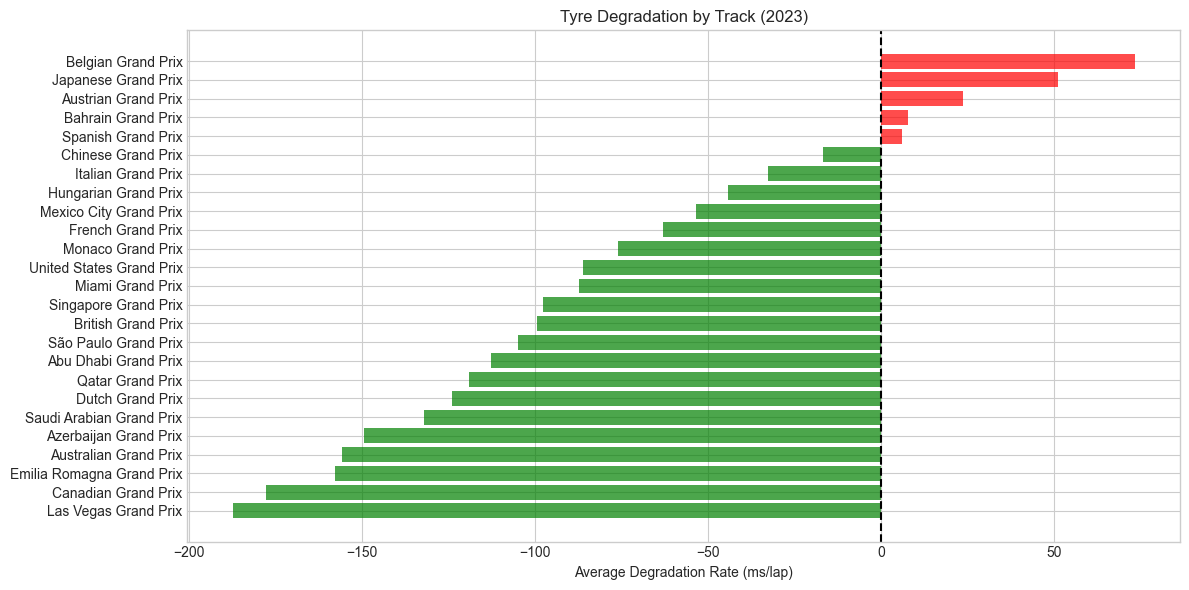

In [7]:
# Visualize track degradation
fig, ax = plt.subplots(figsize=(12, 6))

tracks_to_plot = track_deg[track_deg['n_stints'] >= 5].sort_values('avg_deg')
colors = ['green' if x < 0 else 'red' for x in tracks_to_plot['avg_deg']]

ax.barh(range(len(tracks_to_plot)), tracks_to_plot['avg_deg'], color=colors, alpha=0.7)
ax.set_yticks(range(len(tracks_to_plot)))
ax.set_yticklabels(tracks_to_plot.index)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Average Degradation Rate (ms/lap)')
ax.set_title('Tyre Degradation by Track (2023)')

plt.tight_layout()
plt.show()

## 4. Fuel Effect Analysis

Many stints show **negative degradation** (lap times getting faster). This is likely due to:
1. **Fuel burn effect**: Car gets ~0.1s/lap faster as fuel burns off
2. **Track evolution**: Rubber laid down improves grip
3. **Tyre warmup**: First few laps on new tyres are slower

For short stints, fuel effect can mask tyre degradation entirely!

C:\Users\USER\AppData\Local\Temp\ipykernel_20924\598352468.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = good_fits.groupby('stint_bin')['deg_ms_per_lap'].mean()


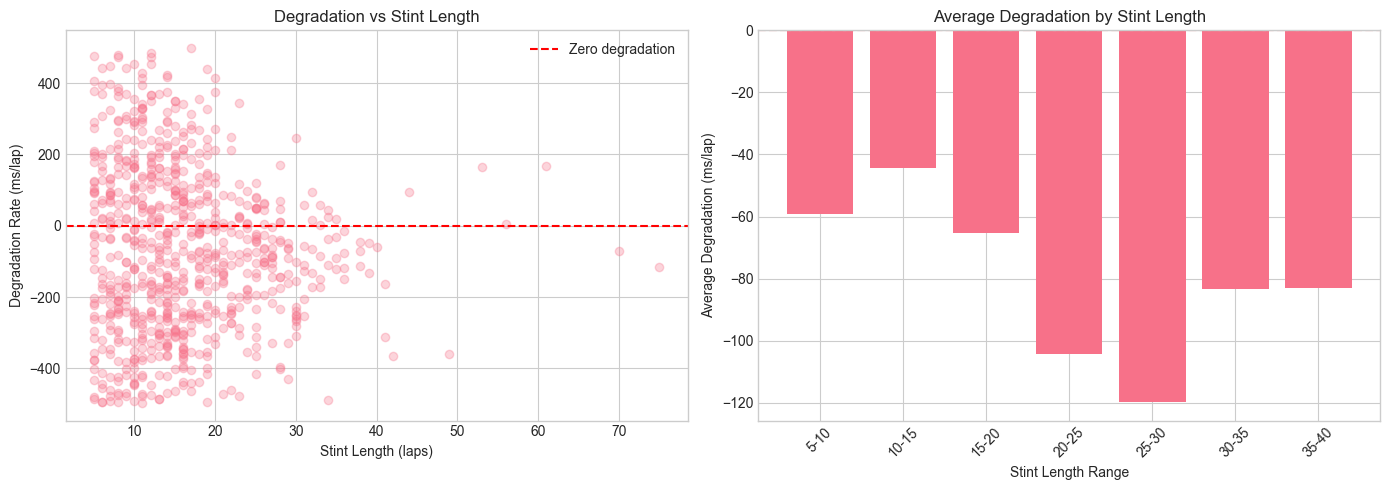


Observation: Short stints tend to show more negative degradation due to fuel effect!


In [8]:
# Analyze relationship between stint length and observed degradation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(good_fits['num_laps'], good_fits['deg_ms_per_lap'], alpha=0.3)
ax.axhline(0, color='red', linestyle='--', label='Zero degradation')
ax.set_xlabel('Stint Length (laps)')
ax.set_ylabel('Degradation Rate (ms/lap)')
ax.set_title('Degradation vs Stint Length')
ax.legend()

# Average by stint length bins
ax = axes[1]
bins = [5, 10, 15, 20, 25, 30, 35, 40]
good_fits['stint_bin'] = pd.cut(good_fits['num_laps'], bins)
binned = good_fits.groupby('stint_bin')['deg_ms_per_lap'].mean()
ax.bar(range(len(binned)), binned.values)
ax.set_xticks(range(len(binned)))
ax.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in binned.index], rotation=45)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Stint Length Range')
ax.set_ylabel('Average Degradation (ms/lap)')
ax.set_title('Average Degradation by Stint Length')

plt.tight_layout()
plt.show()

print('\nObservation: Short stints tend to show more negative degradation due to fuel effect!')

## 5. Next Steps

To improve degradation estimation:

1. **Fuel Correction**: Apply ~0.06-0.08 s/lap fuel burn correction
2. **Minimum Stint Length**: Use stints >= 15 laps for reliable degradation
3. **Track Normalization**: Normalize by track-specific baseline pace
4. **Compound-Specific Models**: Separate models for SOFT, MEDIUM, HARD

In [9]:
# Summary statistics
print('=== Domain 1 Summary Statistics ===\n')
print(f'Total clean-air laps: {len(clean_air_laps):,}')
print(f'Total stints: {len(stints):,}')
print(f'Good fit stints (R² > 0.3, <500ms/lap): {len(good_fits):,}')
print(f'\nDegradation by Compound (good fits):')
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    comp_data = good_fits[good_fits['compound'] == compound]
    if len(comp_data) > 0:
        avg = comp_data['deg_ms_per_lap'].mean()
        std = comp_data['deg_ms_per_lap'].std()
        print(f'  {compound}: {avg:.1f} ± {std:.1f} ms/lap (n={len(comp_data)})')

=== Domain 1 Summary Statistics ===

Total clean-air laps: 28,819
Total stints: 1,905
Good fit stints (R² > 0.3, <500ms/lap): 755

Degradation by Compound (good fits):
  SOFT: -58.3 ± 235.7 ms/lap (n=94)
  MEDIUM: -49.5 ± 230.4 ms/lap (n=274)
  HARD: -75.2 ± 226.3 ms/lap (n=347)


## 6. Fuel Correction Analysis

Comparing RAW (uncorrected) vs CORRECTED degradation rates to see fuel effect impact.

In [10]:
# Reload data with fuel correction columns
stints = pd.read_parquet(SILVER_PATH / 'stints_degradation.parquet')

# Check if fuel correction columns exist
if 'deg_rate_raw' in stints.columns:
    print('=== Fuel Correction Impact ===\n')
    
    # Filter to reasonable values
    good = stints[stints['deg_r_squared'] > 0.3].copy()
    good['deg_ms_corrected'] = good['deg_rate_per_lap'] * 1000
    good['deg_ms_raw'] = good['deg_rate_raw'] * 1000
    
    print(f'RAW (no correction):')
    print(f'  Mean: {good["deg_ms_raw"].mean():.1f} ms/lap')
    print(f'  Median: {good["deg_ms_raw"].median():.1f} ms/lap')
    print()
    print(f'CORRECTED (with 70ms/lap fuel correction):')
    print(f'  Mean: {good["deg_ms_corrected"].mean():.1f} ms/lap')
    print(f'  Median: {good["deg_ms_corrected"].median():.1f} ms/lap')
    print()
    shift = good['deg_ms_corrected'].mean() - good['deg_ms_raw'].mean()
    print(f'Average shift: +{shift:.1f} ms/lap')
else:
    print('No fuel correction columns found - rerun ETL with updated code')

=== Fuel Correction Impact ===

RAW (no correction):
  Mean: -867.8 ms/lap
  Median: -145.5 ms/lap

CORRECTED (with 70ms/lap fuel correction):
  Mean: -797.8 ms/lap
  Median: -75.5 ms/lap

Average shift: +70.0 ms/lap


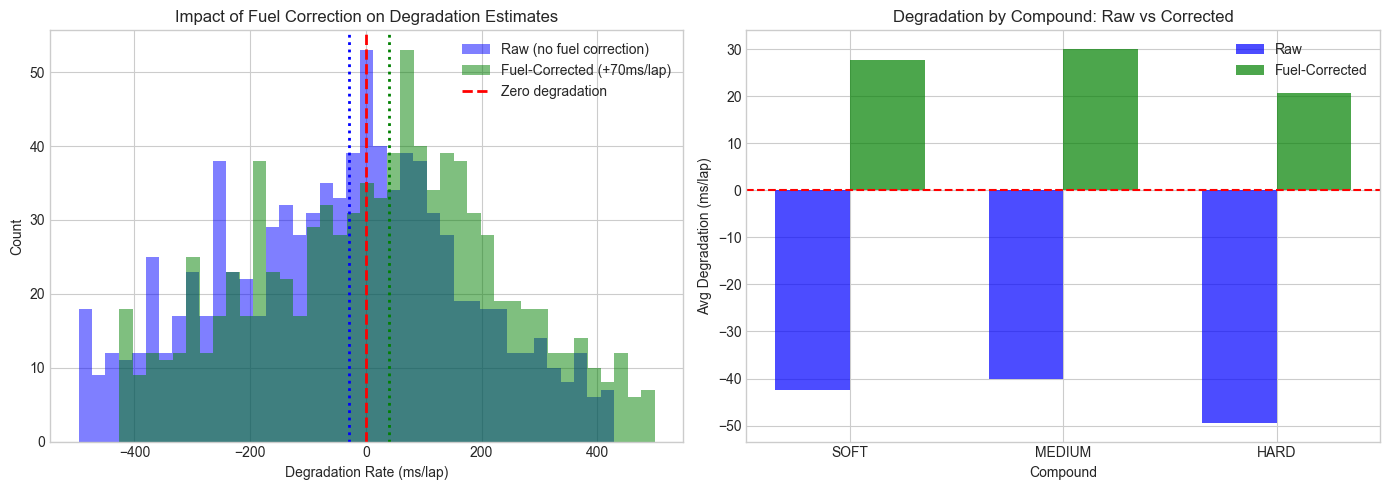


By Compound (Corrected values):
  SOFT: 27.6 ms/lap (shifted +70.0 from raw)
  MEDIUM: 30.0 ms/lap (shifted +70.0 from raw)
  HARD: 20.6 ms/lap (shifted +70.0 from raw)


In [11]:
# Visualize RAW vs CORRECTED distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to reasonable range
plot_data = good[(good['deg_ms_raw'].abs() < 500) & (good['deg_ms_corrected'].abs() < 500)]

# Histogram comparison
ax = axes[0]
ax.hist(plot_data['deg_ms_raw'], bins=40, alpha=0.5, label='Raw (no fuel correction)', color='blue')
ax.hist(plot_data['deg_ms_corrected'], bins=40, alpha=0.5, label='Fuel-Corrected (+70ms/lap)', color='green')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero degradation')
ax.axvline(plot_data['deg_ms_raw'].median(), color='blue', linestyle=':', linewidth=2)
ax.axvline(plot_data['deg_ms_corrected'].median(), color='green', linestyle=':', linewidth=2)
ax.set_xlabel('Degradation Rate (ms/lap)')
ax.set_ylabel('Count')
ax.set_title('Impact of Fuel Correction on Degradation Estimates')
ax.legend()

# By compound comparison
ax = axes[1]
compounds = ['SOFT', 'MEDIUM', 'HARD']
x = np.arange(len(compounds))
width = 0.35

raw_means = [plot_data[plot_data['compound']==c]['deg_ms_raw'].mean() for c in compounds]
corr_means = [plot_data[plot_data['compound']==c]['deg_ms_corrected'].mean() for c in compounds]

bars1 = ax.bar(x - width/2, raw_means, width, label='Raw', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, corr_means, width, label='Fuel-Corrected', color='green', alpha=0.7)

ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Compound')
ax.set_ylabel('Avg Degradation (ms/lap)')
ax.set_title('Degradation by Compound: Raw vs Corrected')
ax.set_xticks(x)
ax.set_xticklabels(compounds)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary
print('\nBy Compound (Corrected values):')
for c in compounds:
    cd = plot_data[plot_data['compound']==c]
    if len(cd) > 0:
        print(f'  {c}: {cd["deg_ms_corrected"].mean():.1f} ms/lap (shifted +{cd["deg_ms_corrected"].mean()-cd["deg_ms_raw"].mean():.1f} from raw)')

## 7. Year-on-Year Trend Analysis

Analyzing how tyre degradation patterns have evolved across 2022, 2023, and 2024 seasons.

In [12]:
# Year-on-Year Analysis
# Filter to good fits with reasonable degradation values
analysis_df = stints[
    (stints['deg_r_squared'] > 0.3) & 
    (stints['deg_rate_per_lap'].abs() < 0.5) &
    (stints['compound'].isin(['SOFT', 'MEDIUM', 'HARD']))
].copy()

analysis_df['deg_ms'] = analysis_df['deg_rate_per_lap'] * 1000

print(f"Analysis dataset: {len(analysis_df)} stints")
print(f"Years: {sorted(analysis_df['year'].unique())}")
print(f"Drivers: {analysis_df['driver'].nunique()}")
print(f"Circuits: {analysis_df['gp_name'].nunique()}")

# Year-over-year summary
year_summary = analysis_df.groupby('year').agg({
    'deg_ms': ['mean', 'median', 'std', 'count'],
    'deg_r_squared': 'mean',
    'num_laps': 'mean'
}).round(2)
year_summary.columns = ['Mean Deg (ms)', 'Median Deg (ms)', 'Std Dev', 'Stint Count', 'Avg R²', 'Avg Stint Length']
print("\n=== Year-over-Year Degradation Summary ===")
year_summary

Analysis dataset: 893 stints
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Drivers: 27
Circuits: 25

=== Year-over-Year Degradation Summary ===


,Mean Deg (ms),Median Deg (ms),Std Dev,Stint Count,Avg R²,Avg Stint Length
year,,,,,,
2022,16.05,37.01,219.16,284,0.73,15.39
2023,4.84,35.00,218.48,298,0.70,16.70
2024,14.42,38.64,233.04,311,0.72,16.36


C:\Users\USER\AppData\Local\Temp\ipykernel_20924\3681444516.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True)


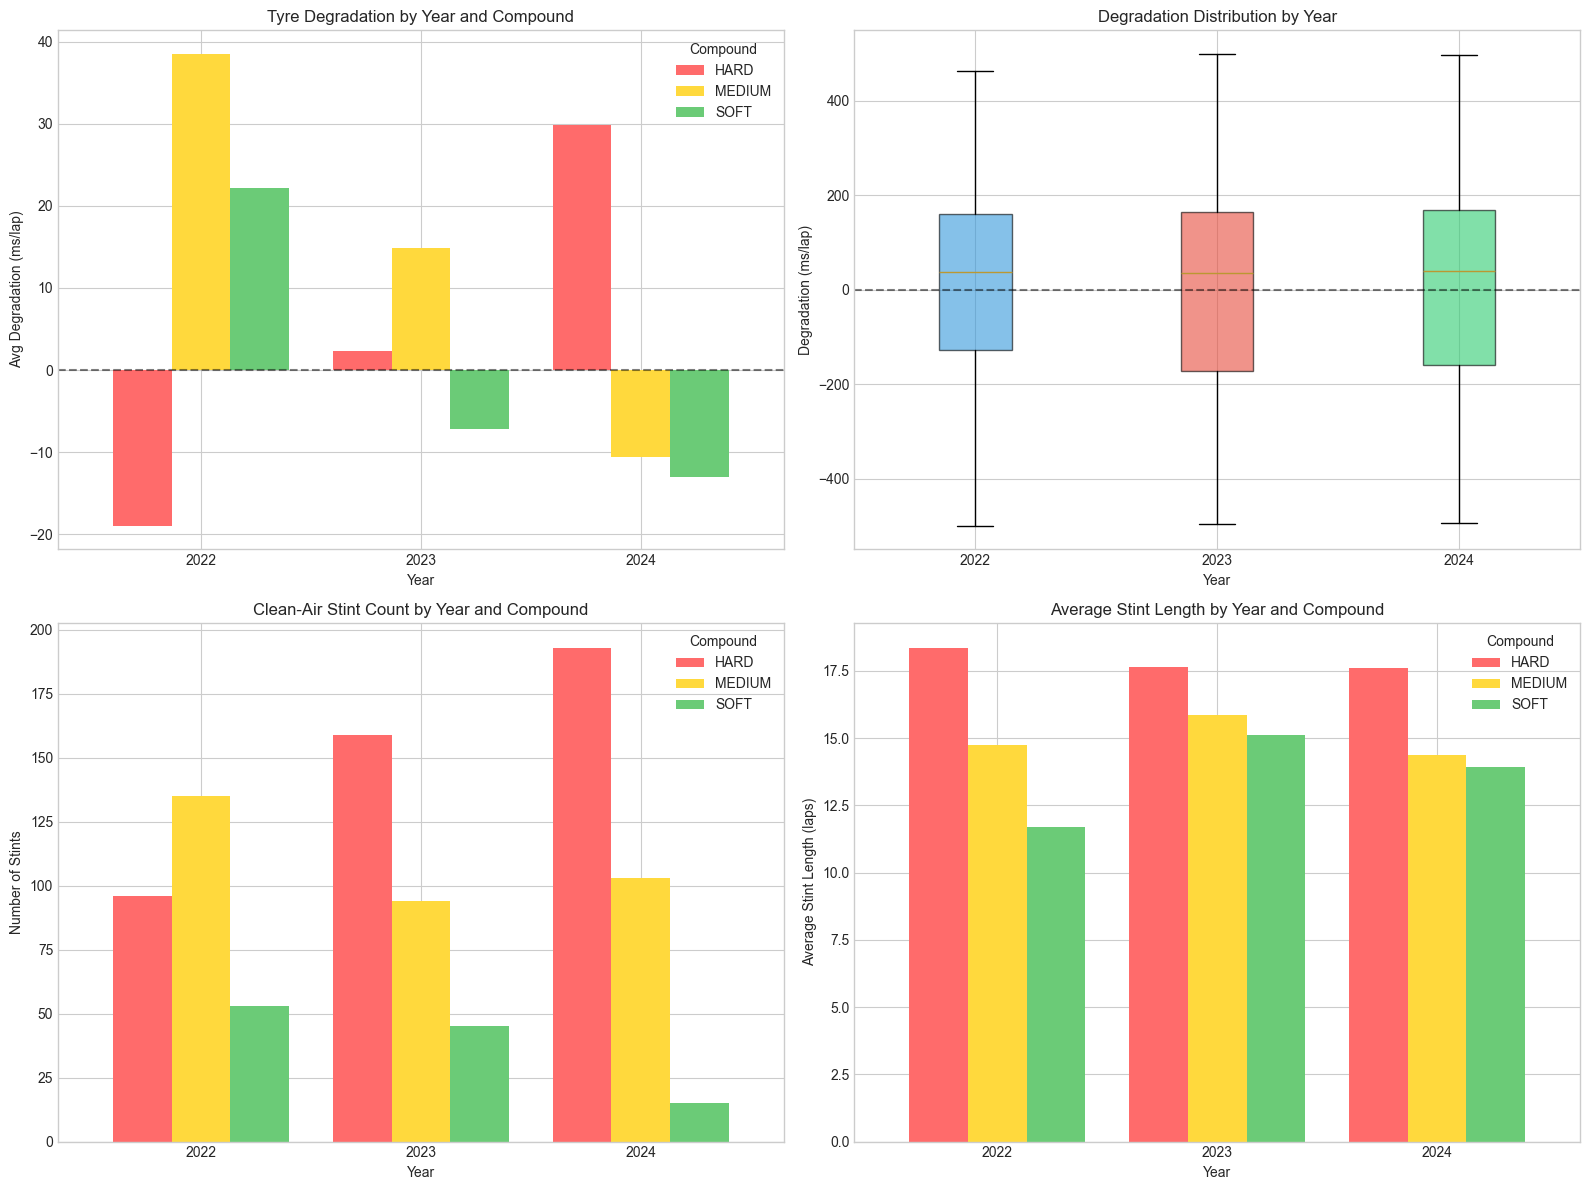

In [13]:
# Visualization: Year-over-Year by Compound
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Degradation by Year and Compound
ax = axes[0, 0]
year_compound = analysis_df.groupby(['year', 'compound'])['deg_ms'].mean().unstack()
year_compound.plot(kind='bar', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Avg Degradation (ms/lap)')
ax.set_title('Tyre Degradation by Year and Compound')
ax.legend(title='Compound')
ax.tick_params(axis='x', rotation=0)

# 2. Distribution by Year (Box Plot)
ax = axes[0, 1]
years = sorted(analysis_df['year'].unique())
data_by_year = [analysis_df[analysis_df['year'] == y]['deg_ms'].values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True)
colors_year = ['#3498db', '#e74c3c', '#2ecc71']
for patch, color in zip(bp['boxes'], colors_year):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Degradation (ms/lap)')
ax.set_title('Degradation Distribution by Year')

# 3. Stint Count by Year and Compound
ax = axes[1, 0]
stint_counts = analysis_df.groupby(['year', 'compound']).size().unstack()
stint_counts.plot(kind='bar', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
ax.set_xlabel('Year')
ax.set_ylabel('Number of Stints')
ax.set_title('Clean-Air Stint Count by Year and Compound')
ax.legend(title='Compound')
ax.tick_params(axis='x', rotation=0)

# 4. Average Stint Length by Year
ax = axes[1, 1]
stint_length = analysis_df.groupby(['year', 'compound'])['num_laps'].mean().unstack()
stint_length.plot(kind='bar', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
ax.set_xlabel('Year')
ax.set_ylabel('Average Stint Length (laps)')
ax.set_title('Average Stint Length by Year and Compound')
ax.legend(title='Compound')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Circuit-by-Circuit Analysis

Detailed breakdown of degradation characteristics for each circuit across all years.

In [14]:
# Circuit Analysis - Comprehensive breakdown
circuit_analysis = analysis_df.groupby('gp_name').agg({
    'deg_ms': ['mean', 'median', 'std', 'count'],
    'deg_r_squared': 'mean',
    'num_laps': 'mean',
    'year': lambda x: list(x.unique())
}).round(2)

circuit_analysis.columns = ['Mean Deg', 'Median Deg', 'Std Dev', 'Stints', 'Avg R²', 'Avg Length', 'Years']
circuit_analysis = circuit_analysis.sort_values('Mean Deg', ascending=False)

print("=== Circuit Degradation Rankings (Fuel-Corrected) ===")
print(f"{'Circuit':<30} {'Mean':>8} {'Median':>8} {'Stints':>8} {'R²':>6}")
print("-" * 65)
for circuit, row in circuit_analysis.iterrows():
    print(f"{circuit:<30} {row['Mean Deg']:>8.1f} {row['Median Deg']:>8.1f} {int(row['Stints']):>8} {row['Avg R²']:>6.2f}")

=== Circuit Degradation Rankings (Fuel-Corrected) ===
Circuit                            Mean   Median   Stints     R²
-----------------------------------------------------------------
Belgian Grand Prix                139.2    206.8       37   0.70
Bahrain Grand Prix                 95.7    139.4       67   0.84
Japanese Grand Prix                70.2    155.9       30   0.76
Spanish Grand Prix                 59.9     95.0       73   0.75
São Paulo Grand Prix               53.5     79.8       34   0.72
Austrian Grand Prix                46.7     89.7       66   0.79
Chinese Grand Prix                 38.7    117.1       16   0.82
Abu Dhabi Grand Prix               33.2     45.7       49   0.75
Miami Grand Prix                   20.5     75.3       24   0.57
French Grand Prix                  19.2     30.6       14   0.69
Hungarian Grand Prix               17.2     43.6       65   0.75
United States Grand Prix            9.9    -17.1       35   0.62
Italian Grand Prix                 

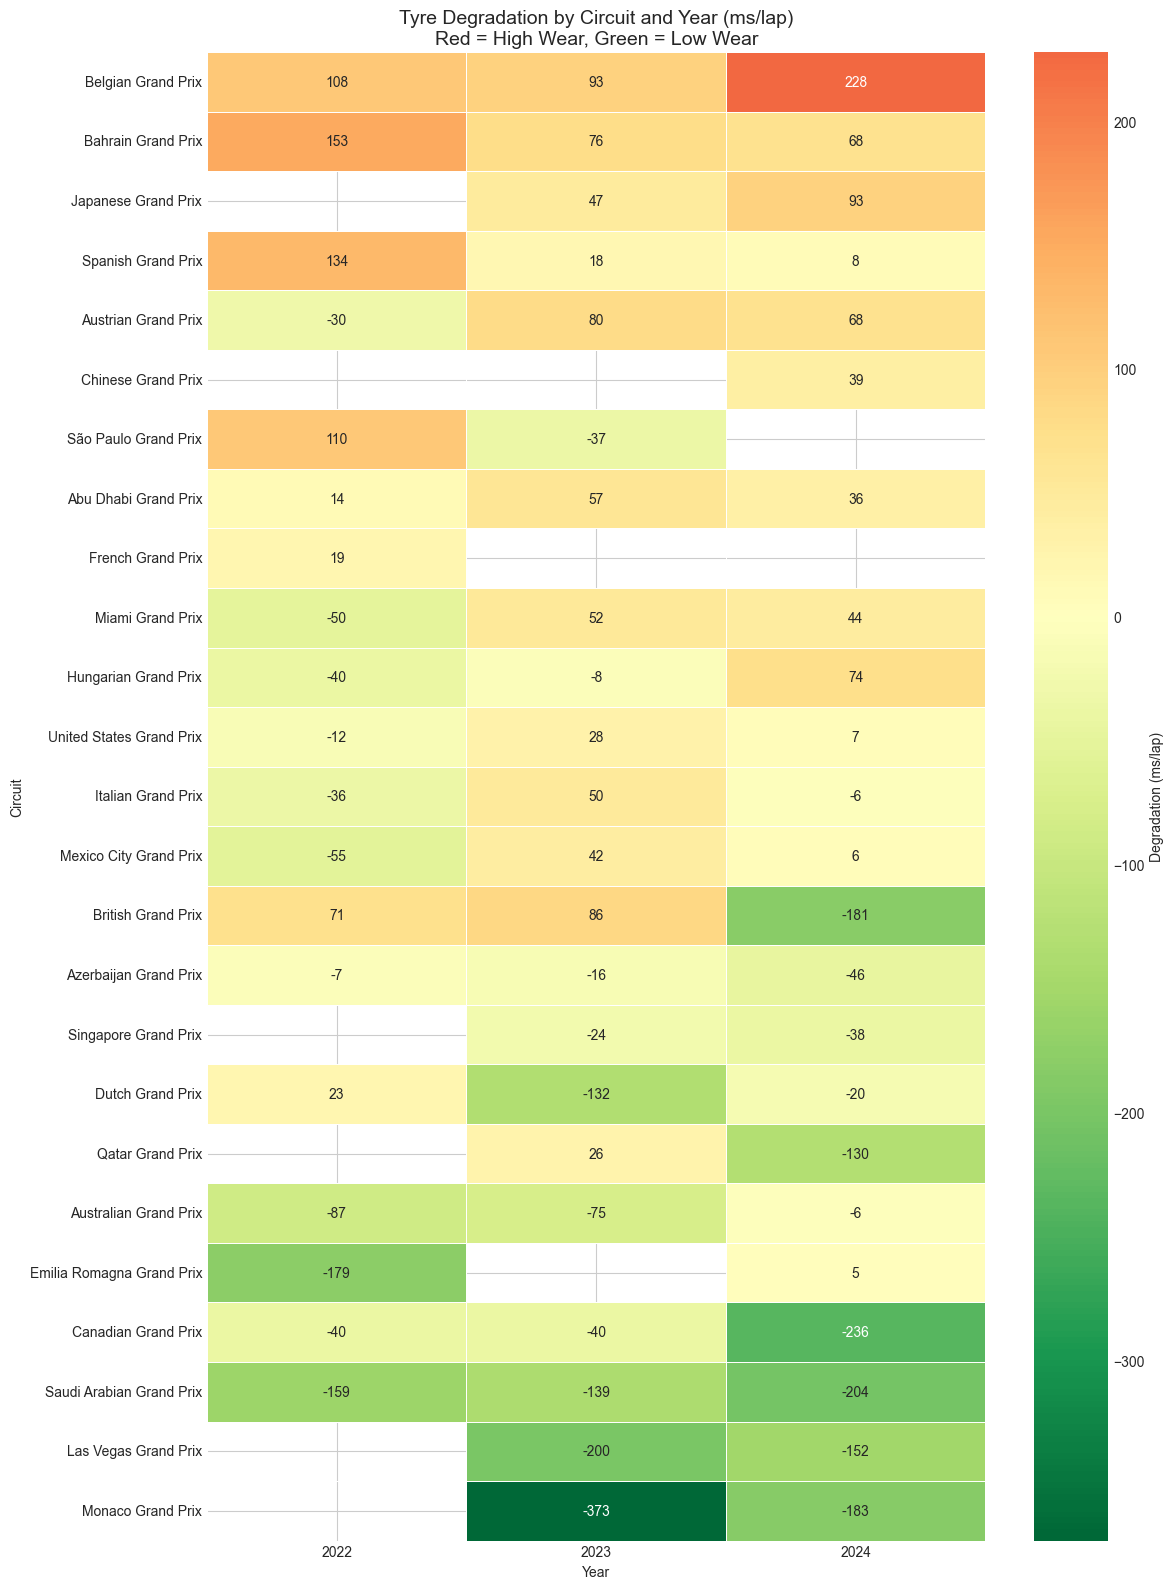


Note: Empty cells indicate no clean-air stint data for that circuit-year combination.


In [15]:
# Circuit degradation heatmap by Year
circuit_year = analysis_df.pivot_table(
    values='deg_ms', 
    index='gp_name', 
    columns='year', 
    aggfunc='mean'
).round(1)

# Sort by overall average
circuit_year['avg'] = circuit_year.mean(axis=1)
circuit_year = circuit_year.sort_values('avg', ascending=False).drop('avg', axis=1)

fig, ax = plt.subplots(figsize=(12, 16))
sns.heatmap(circuit_year, annot=True, fmt='.0f', cmap='RdYlGn_r', center=0,
            cbar_kws={'label': 'Degradation (ms/lap)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Tyre Degradation by Circuit and Year (ms/lap)\nRed = High Wear, Green = Low Wear', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Circuit')
plt.tight_layout()
plt.show()

print("\nNote: Empty cells indicate no clean-air stint data for that circuit-year combination.")

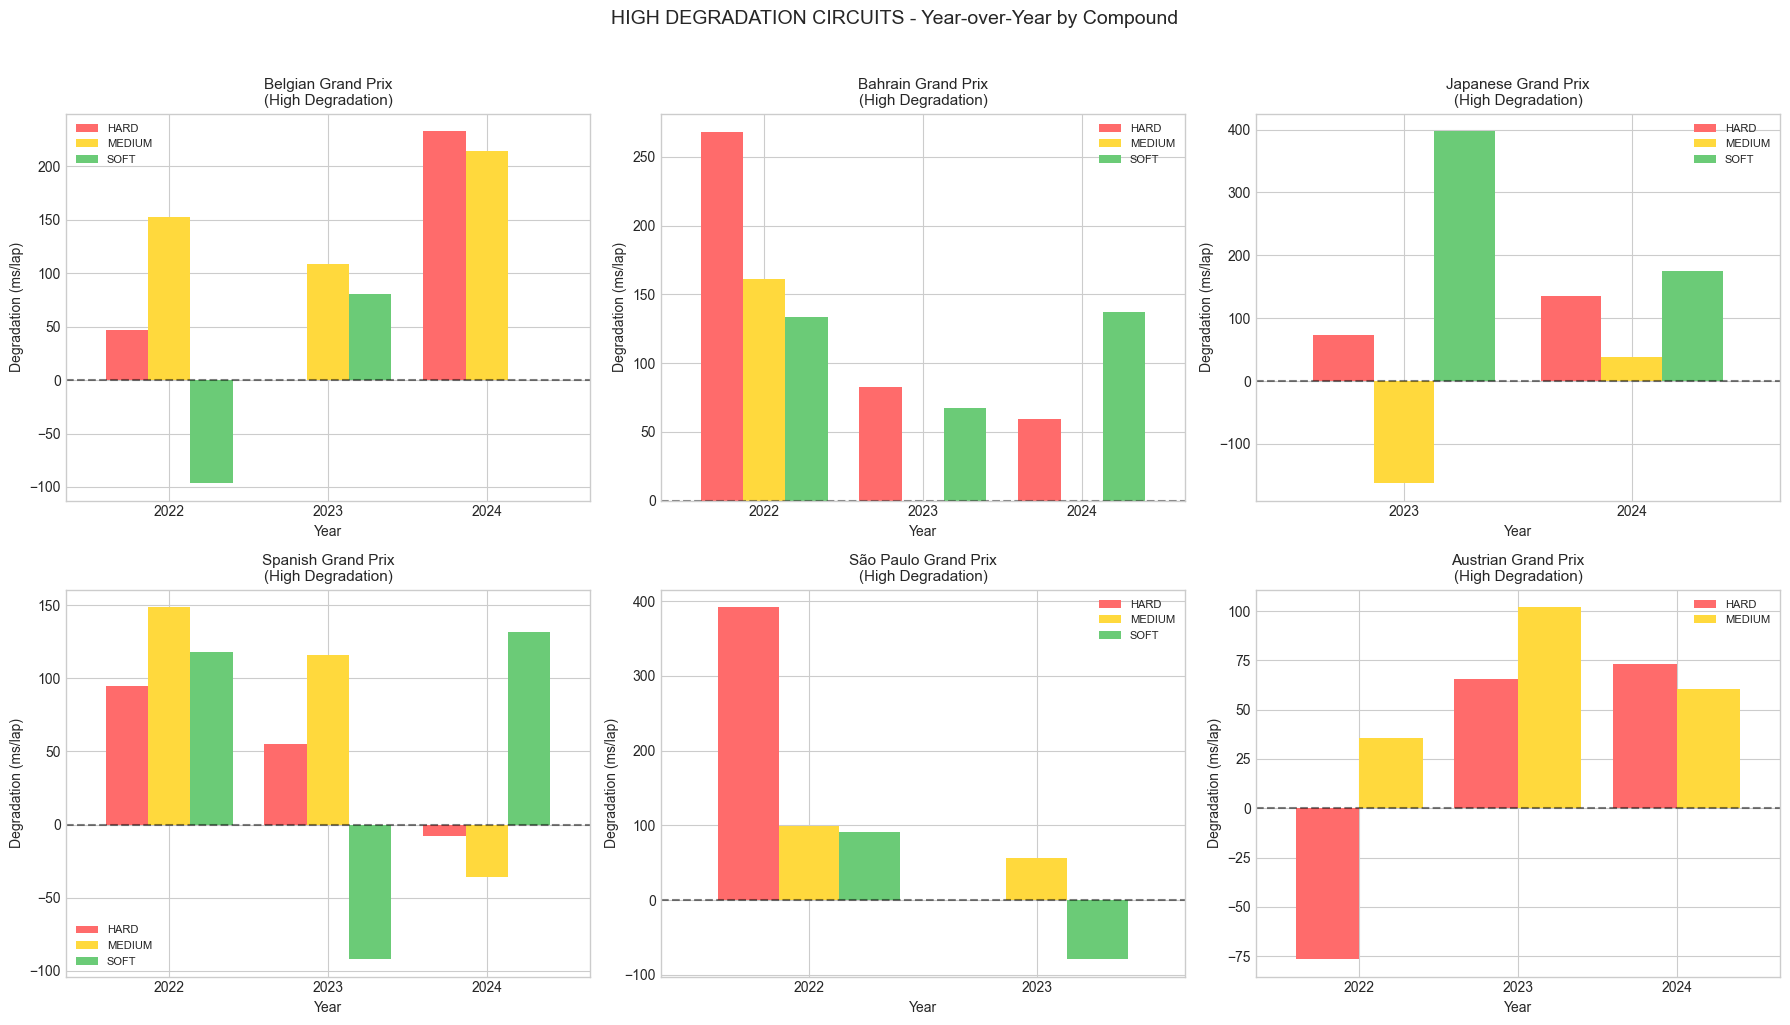

In [16]:
# Top 6 Circuits - Detailed Year-over-Year Comparison
top_circuits = circuit_analysis.head(6).index.tolist()
bottom_circuits = circuit_analysis.tail(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, circuit in enumerate(top_circuits):
    ax = axes[i]
    circuit_data = analysis_df[analysis_df['gp_name'] == circuit]
    
    # Group by year and compound
    pivot = circuit_data.pivot_table(values='deg_ms', index='year', columns='compound', aggfunc='mean')
    pivot.plot(kind='bar', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'{circuit}\n(High Degradation)', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Degradation (ms/lap)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='', fontsize=8)

plt.suptitle('HIGH DEGRADATION CIRCUITS - Year-over-Year by Compound', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

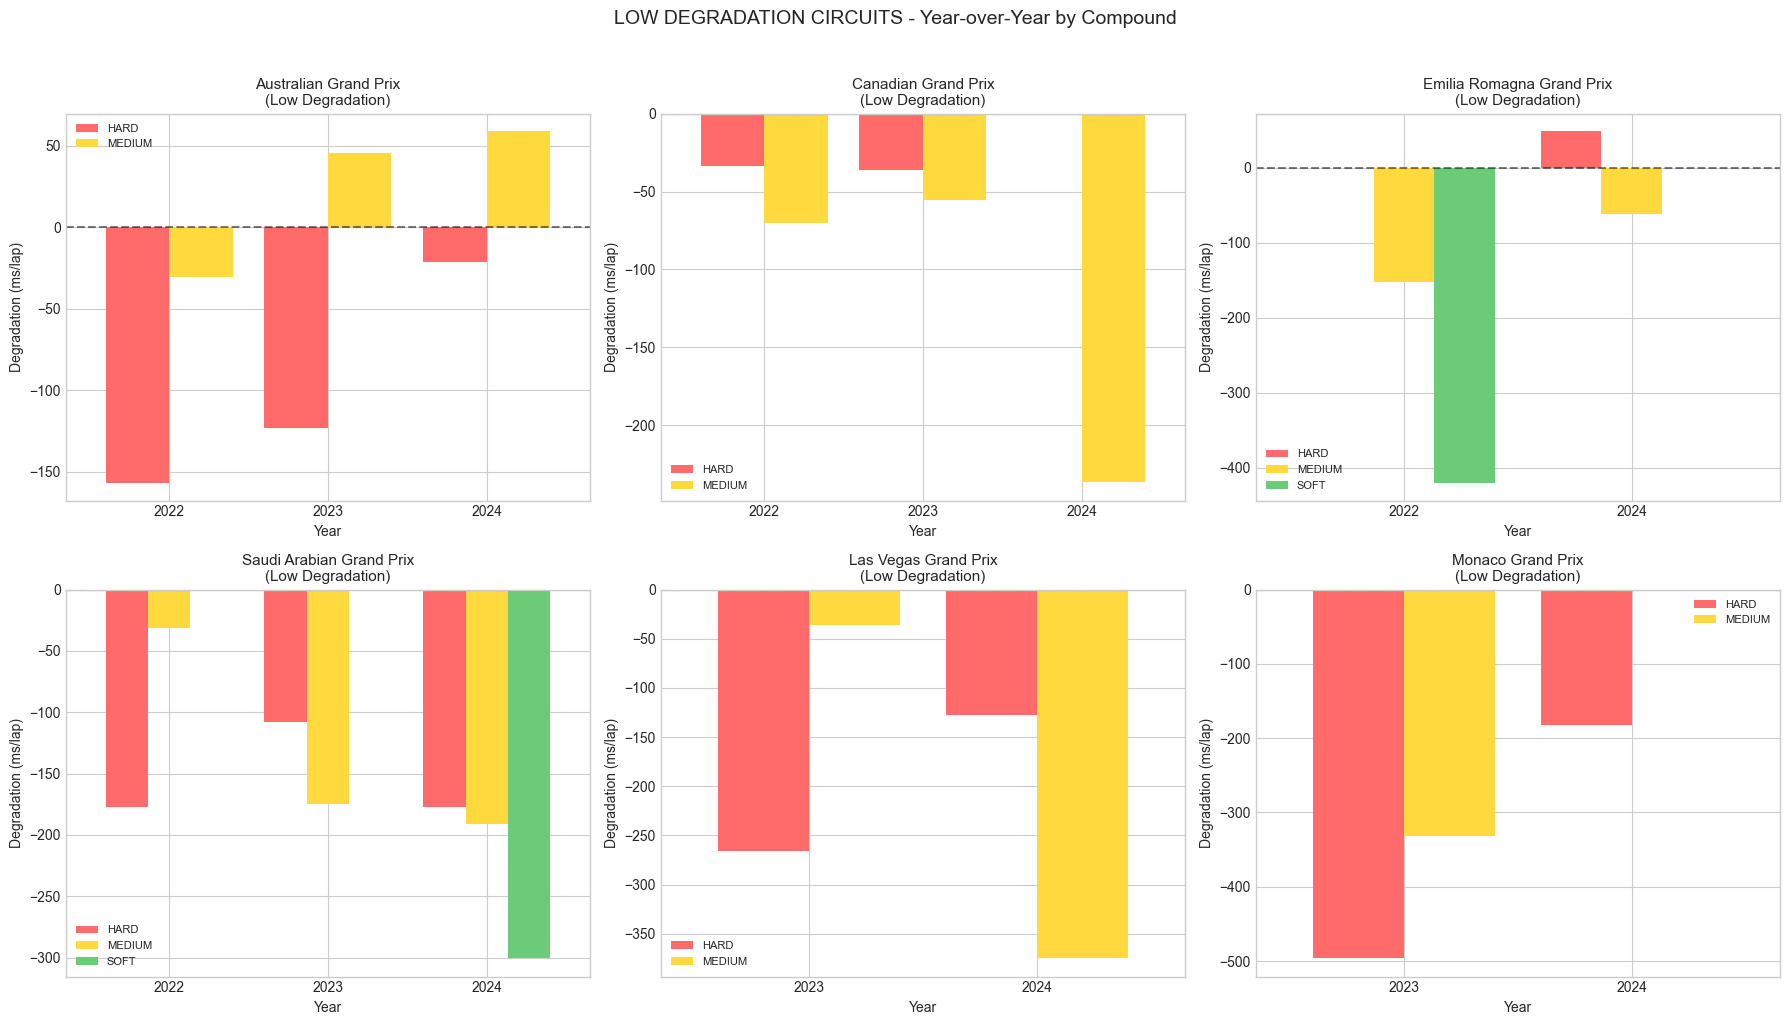

In [17]:
# Bottom 6 Circuits (Lowest Degradation) - Year-over-Year
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, circuit in enumerate(bottom_circuits):
    ax = axes[i]
    circuit_data = analysis_df[analysis_df['gp_name'] == circuit]
    
    pivot = circuit_data.pivot_table(values='deg_ms', index='year', columns='compound', aggfunc='mean')
    pivot.plot(kind='bar', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'{circuit}\n(Low Degradation)', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Degradation (ms/lap)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='', fontsize=8)

plt.suptitle('LOW DEGRADATION CIRCUITS - Year-over-Year by Compound', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Driver Analysis - Tyre Management Profiles

Identifying which drivers are best at managing tyre degradation (lower degradation = better tyre management).

In [18]:
# Driver tyre management analysis
driver_analysis = analysis_df.groupby('driver').agg({
    'deg_ms': ['mean', 'median', 'std', 'count'],
    'deg_r_squared': 'mean',
    'num_laps': 'mean',
    'team': lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'
}).round(2)

driver_analysis.columns = ['Mean Deg', 'Median Deg', 'Std Dev', 'Stints', 'Avg R²', 'Avg Length', 'Team']

# Filter to drivers with at least 10 stints for reliability
driver_analysis = driver_analysis[driver_analysis['Stints'] >= 10]
driver_analysis = driver_analysis.sort_values('Mean Deg', ascending=True)

print("=== Driver Tyre Management Rankings ===")
print("(Lower degradation = better tyre management)")
print(f"\n{'Driver':<6} {'Team':<20} {'Mean':>8} {'Median':>8} {'Stints':>8} {'R²':>6}")
print("-" * 65)
for driver, row in driver_analysis.iterrows():
    print(f"{driver:<6} {row['Team']:<20} {row['Mean Deg']:>8.1f} {row['Median Deg']:>8.1f} {int(row['Stints']):>8} {row['Avg R²']:>6.2f}")

=== Driver Tyre Management Rankings ===
(Lower degradation = better tyre management)

Driver Team                     Mean   Median   Stints     R²
-----------------------------------------------------------------
TSU    AlphaTauri              -52.4     -0.3       32   0.68
LEC    Ferrari                 -28.1    -53.4       57   0.75
GAS    Alpine                  -25.7    -18.9       21   0.67
RUS    Mercedes                -17.8      6.6       63   0.75
SAR    Williams                -11.6     72.0       22   0.65
HUL    Haas F1 Team            -11.1    -51.2       27   0.73
HAM    Mercedes                 -3.1      6.0       44   0.77
ZHO    Kick Sauber              -1.9      9.0       27   0.58
RIC    McLaren                   2.0     50.7       18   0.68
ALO    Aston Martin              3.0     42.0       50   0.66
SAI    Ferrari                   6.6     44.6       59   0.77
PER    Red Bull Racing           6.8    -38.7       46   0.76
BOT    Alfa Romeo               10.3     1

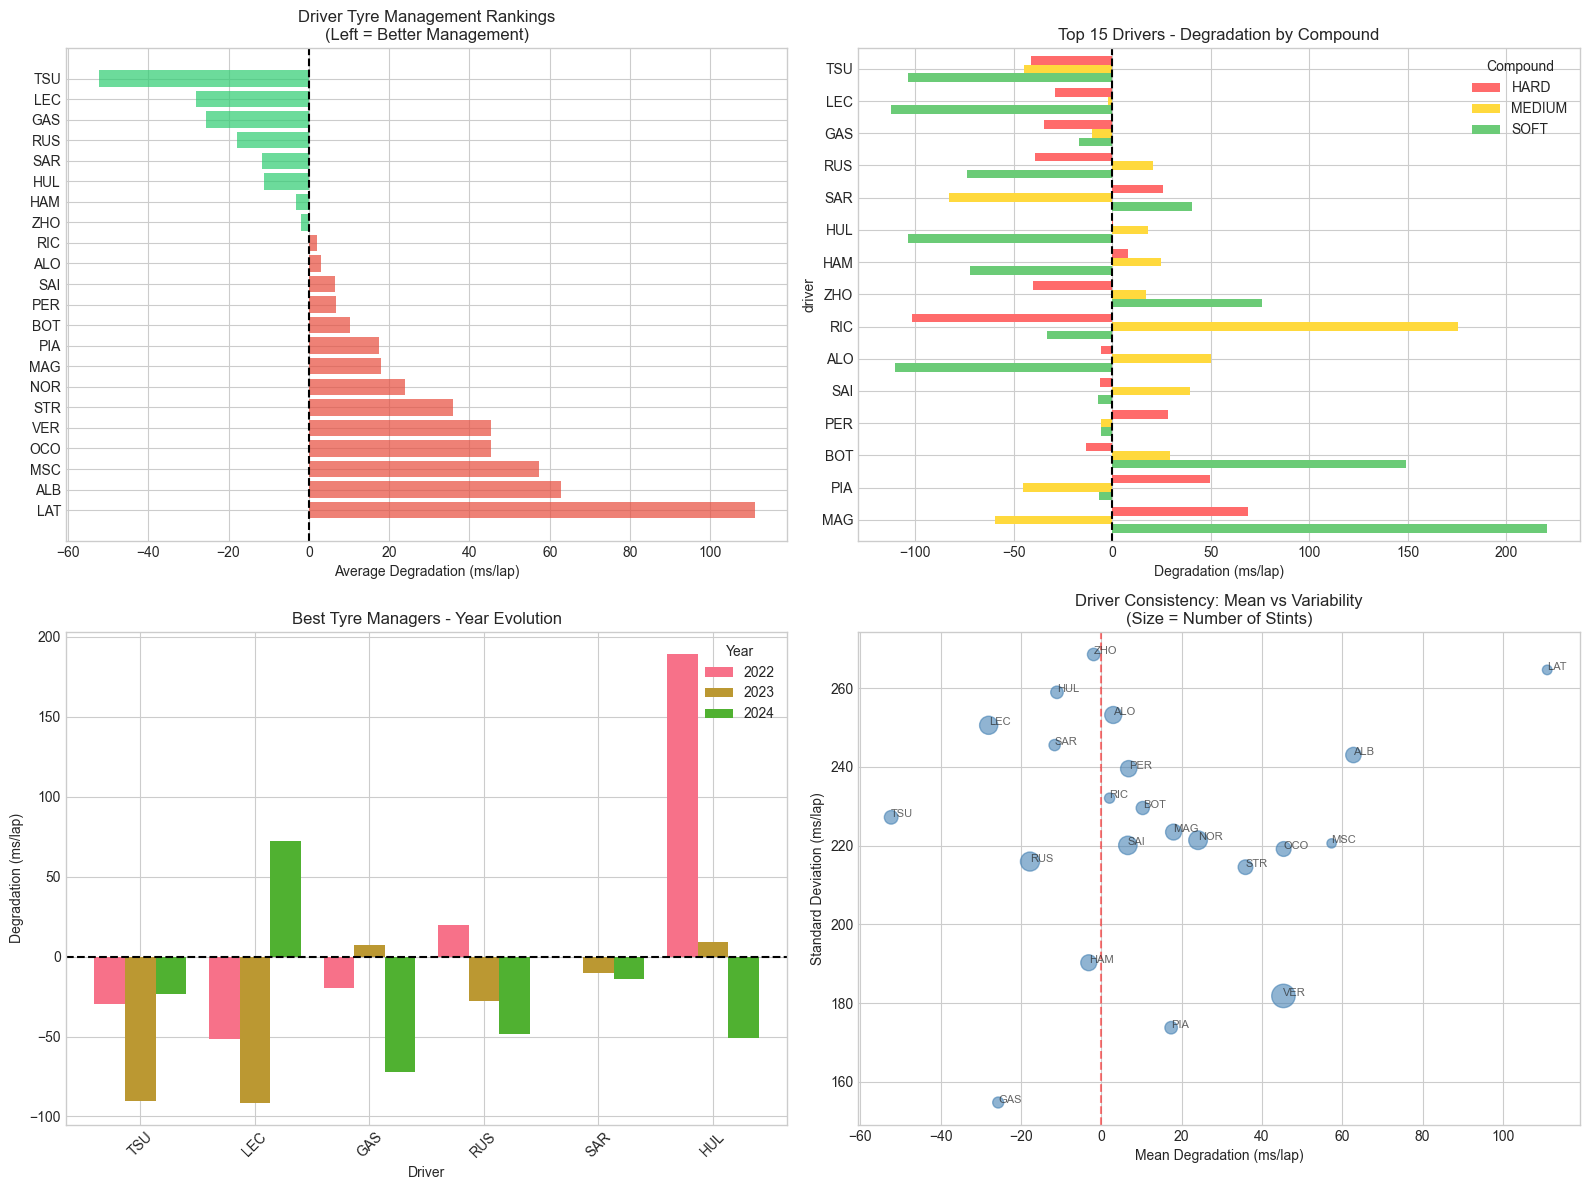

In [19]:
# Driver degradation visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Driver rankings bar chart
ax = axes[0, 0]
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in driver_analysis['Mean Deg']]
ax.barh(range(len(driver_analysis)), driver_analysis['Mean Deg'], color=colors, alpha=0.7)
ax.set_yticks(range(len(driver_analysis)))
ax.set_yticklabels(driver_analysis.index)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Average Degradation (ms/lap)')
ax.set_title('Driver Tyre Management Rankings\n(Left = Better Management)')
ax.invert_yaxis()

# 2. Driver by Compound
ax = axes[0, 1]
driver_compound = analysis_df.groupby(['driver', 'compound'])['deg_ms'].mean().unstack()
# Filter to top drivers by stint count
top_drivers = driver_analysis.head(15).index.tolist()
driver_compound_top = driver_compound.loc[driver_compound.index.isin(top_drivers)]
driver_compound_top = driver_compound_top.reindex(top_drivers)
driver_compound_top.plot(kind='barh', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Degradation (ms/lap)')
ax.set_title('Top 15 Drivers - Degradation by Compound')
ax.legend(title='Compound')
ax.invert_yaxis()

# 3. Driver Year-over-Year Evolution (Top 6)
ax = axes[1, 0]
top_6_drivers = driver_analysis.head(6).index.tolist()
driver_year = analysis_df[analysis_df['driver'].isin(top_6_drivers)].pivot_table(
    values='deg_ms', index='driver', columns='year', aggfunc='mean'
)
driver_year = driver_year.reindex(top_6_drivers)
driver_year.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('Driver')
ax.set_ylabel('Degradation (ms/lap)')
ax.set_title('Best Tyre Managers - Year Evolution')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Year')

# 4. Variability analysis (consistency)
ax = axes[1, 1]
ax.scatter(driver_analysis['Mean Deg'], driver_analysis['Std Dev'], 
           s=driver_analysis['Stints']*3, alpha=0.6, c='steelblue')
for driver in driver_analysis.index:
    ax.annotate(driver, (driver_analysis.loc[driver, 'Mean Deg'], 
                         driver_analysis.loc[driver, 'Std Dev']),
                fontsize=8, alpha=0.7)
ax.set_xlabel('Mean Degradation (ms/lap)')
ax.set_ylabel('Standard Deviation (ms/lap)')
ax.set_title('Driver Consistency: Mean vs Variability\n(Size = Number of Stints)')
ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 10. Driver-Circuit Matrix Analysis

Deep dive into how each driver performs at specific circuits - identifying driver strengths and weaknesses.

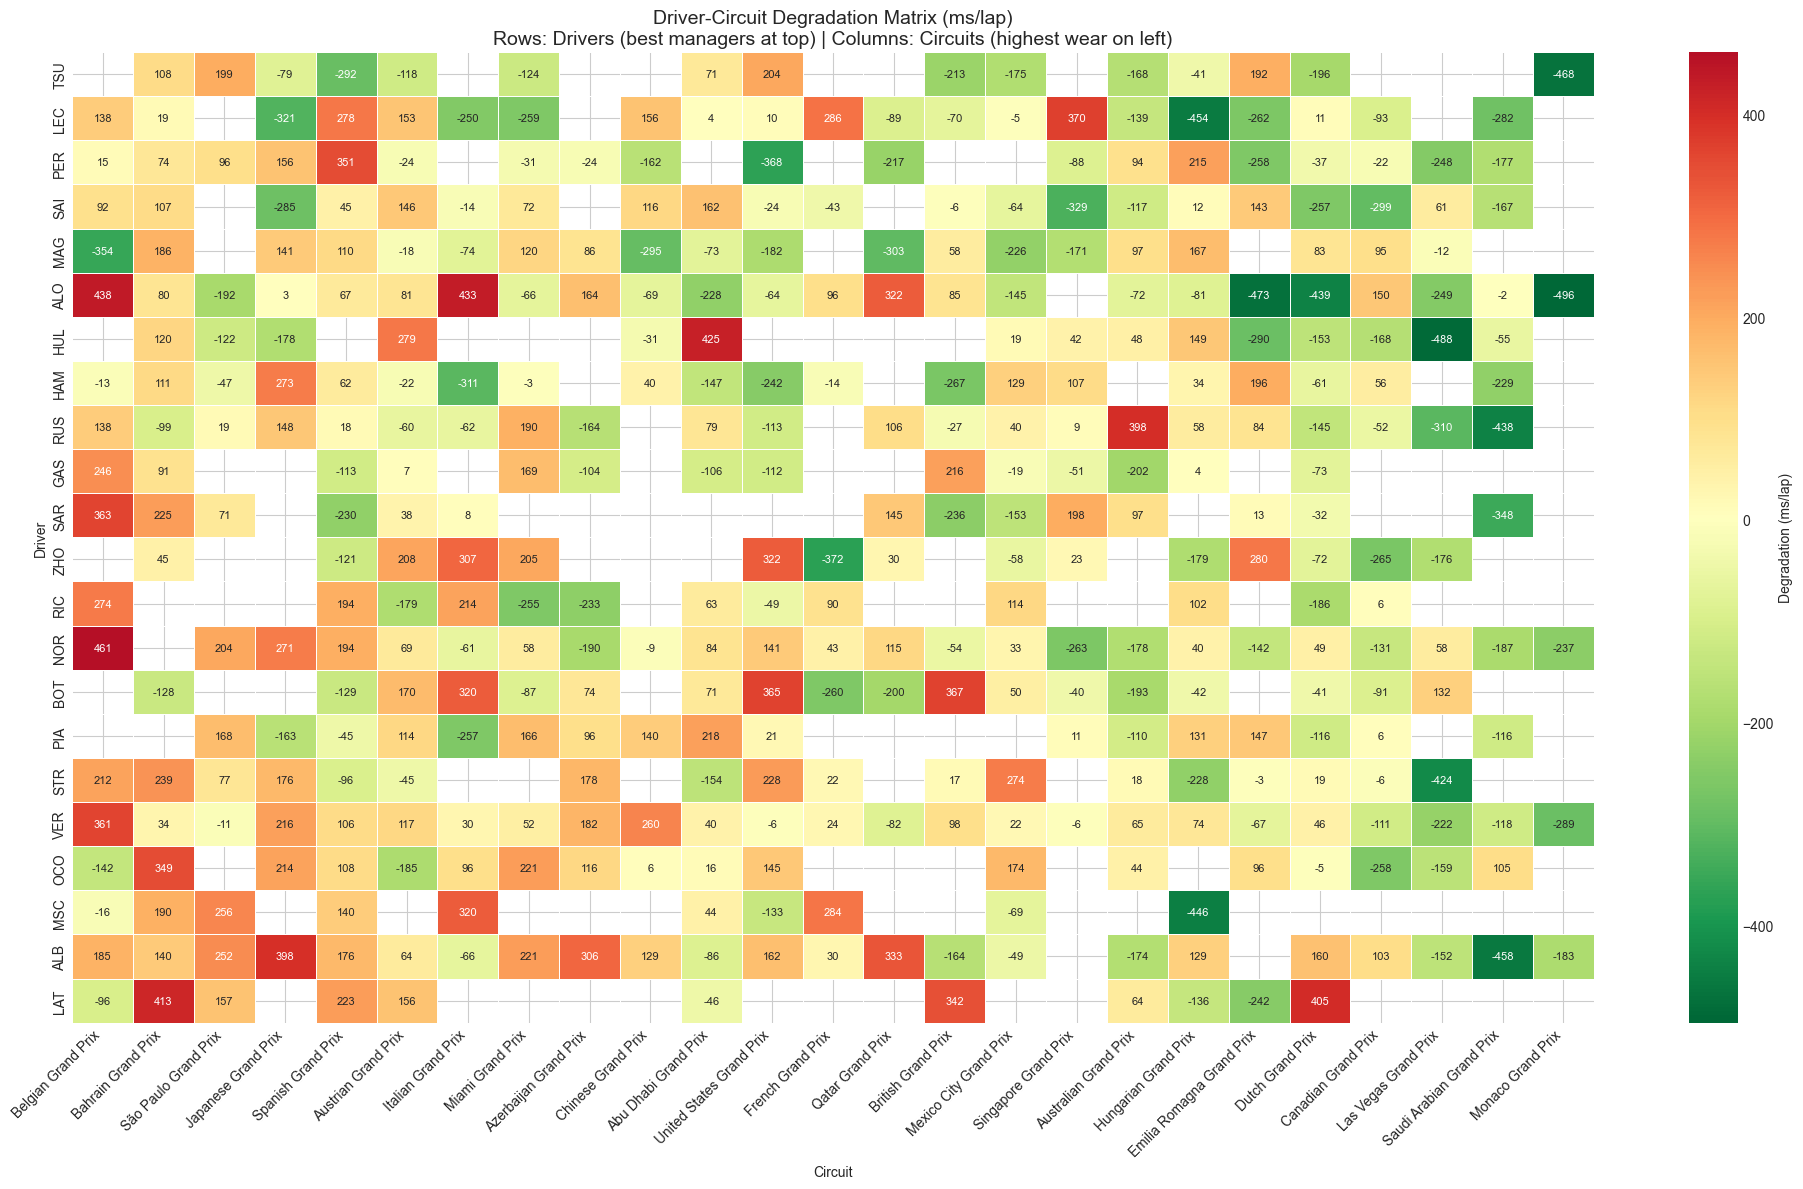

Note: Red = high degradation, Green = low degradation/fuel dominant


In [20]:
# Driver-Circuit Matrix
# Filter to drivers with enough data
active_drivers = driver_analysis.index.tolist()

# Create pivot table
driver_circuit_matrix = analysis_df[analysis_df['driver'].isin(active_drivers)].pivot_table(
    values='deg_ms',
    index='driver',
    columns='gp_name',
    aggfunc='mean'
).round(1)

# Order by driver average
driver_circuit_matrix['avg'] = driver_circuit_matrix.mean(axis=1)
driver_circuit_matrix = driver_circuit_matrix.sort_values('avg').drop('avg', axis=1)

# Order columns by circuit average
circuit_order = driver_circuit_matrix.mean().sort_values(ascending=False).index
driver_circuit_matrix = driver_circuit_matrix[circuit_order]

# Plot heatmap
fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(driver_circuit_matrix, annot=True, fmt='.0f', cmap='RdYlGn_r', center=0,
            cbar_kws={'label': 'Degradation (ms/lap)'}, ax=ax,
            linewidths=0.5, linecolor='white', annot_kws={'size': 8})
ax.set_title('Driver-Circuit Degradation Matrix (ms/lap)\nRows: Drivers (best managers at top) | Columns: Circuits (highest wear on left)', 
             fontsize=14)
ax.set_xlabel('Circuit')
ax.set_ylabel('Driver')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Note: Red = high degradation, Green = low degradation/fuel dominant")

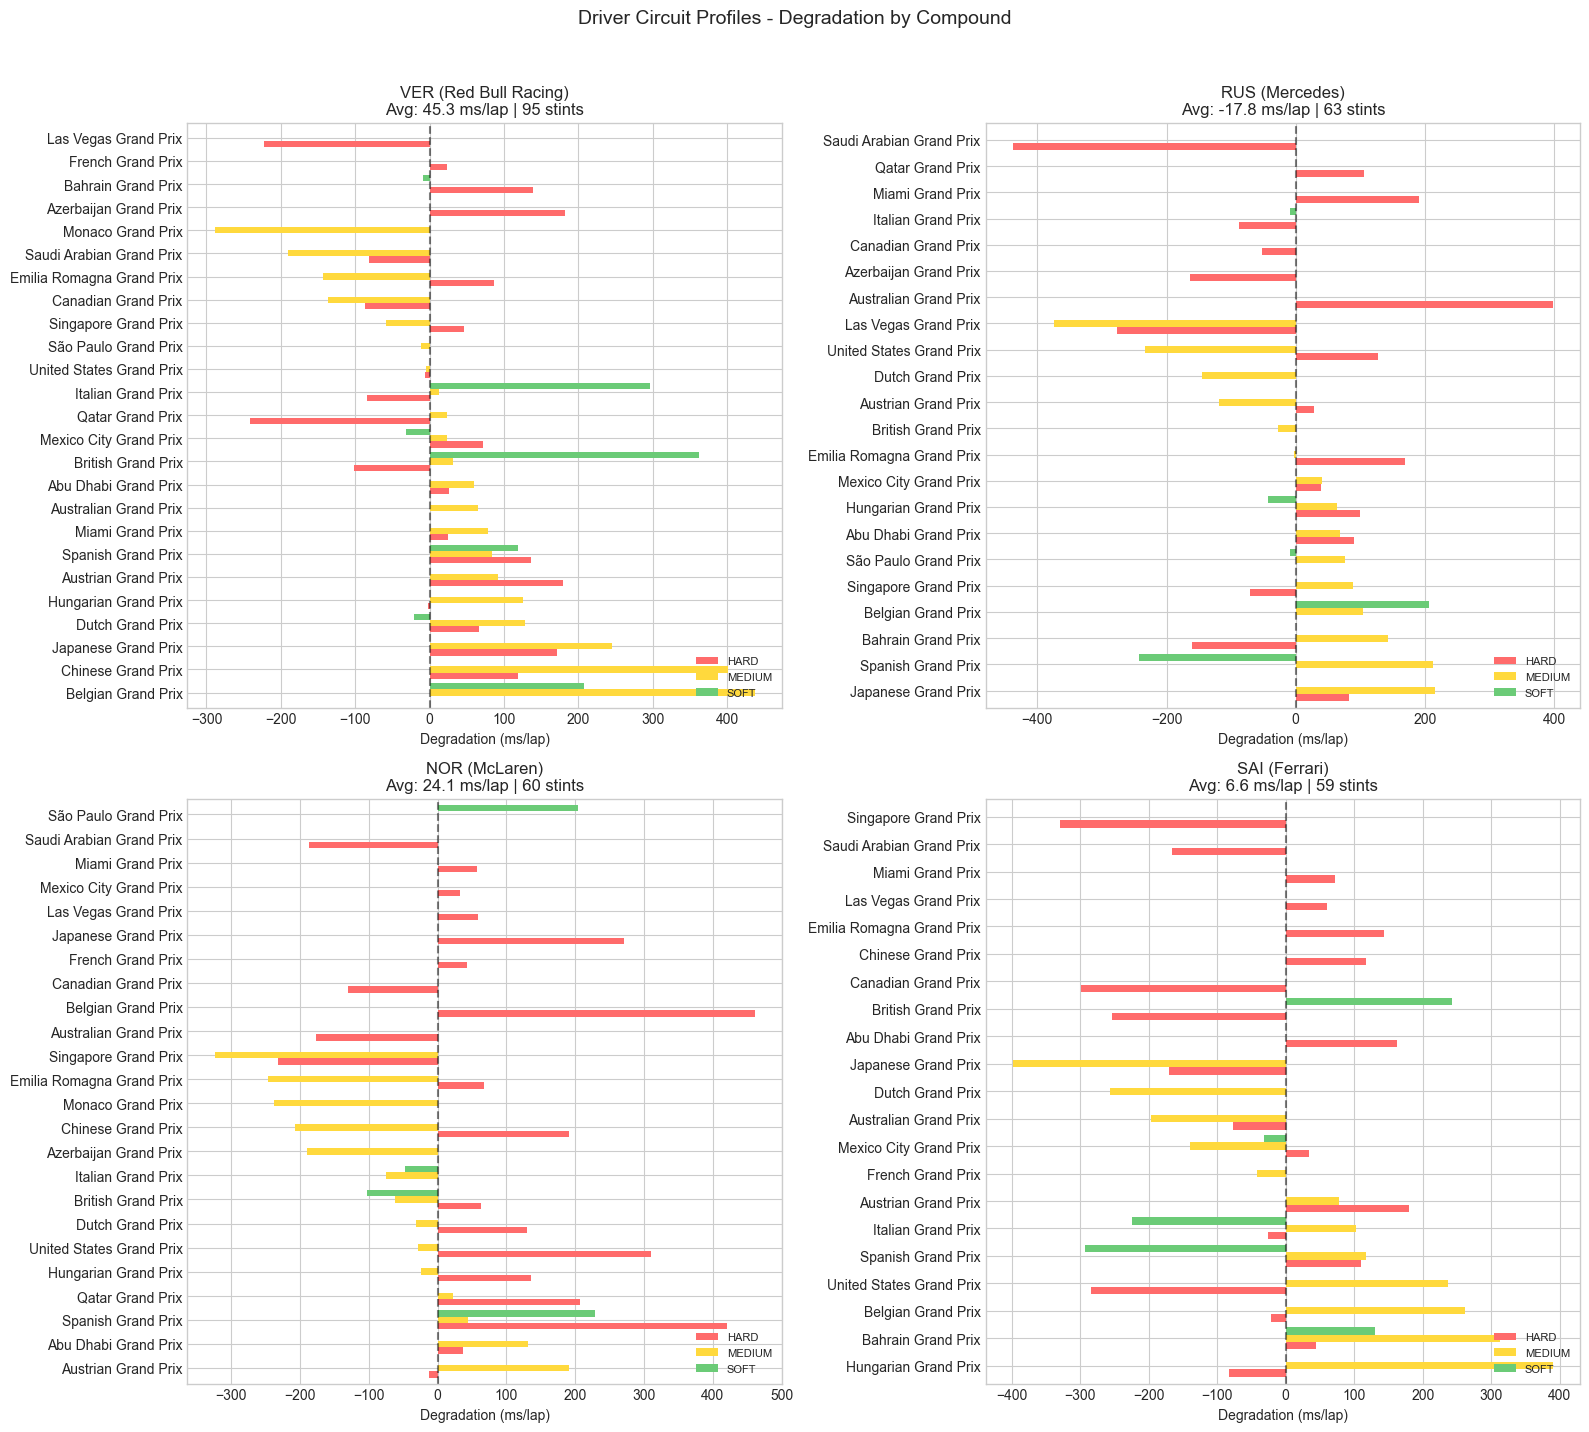

In [21]:
# Individual Driver Profiles - Deep Dive on Top 4 Drivers
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Select top 4 most active drivers
top_active = driver_analysis.nlargest(4, 'Stints').index.tolist()

for i, driver in enumerate(top_active):
    ax = axes[i]
    driver_data = analysis_df[analysis_df['driver'] == driver]
    
    # Create compound-circuit breakdown
    driver_pivot = driver_data.pivot_table(
        values='deg_ms',
        index='gp_name',
        columns='compound',
        aggfunc='mean'
    ).round(1)
    
    # Sort by MEDIUM compound if available
    if 'MEDIUM' in driver_pivot.columns:
        driver_pivot = driver_pivot.sort_values('MEDIUM', ascending=False)
    
    driver_pivot.plot(kind='barh', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Degradation (ms/lap)')
    ax.set_ylabel('')
    
    team = driver_analysis.loc[driver, 'Team']
    avg_deg = driver_analysis.loc[driver, 'Mean Deg']
    stints = int(driver_analysis.loc[driver, 'Stints'])
    ax.set_title(f'{driver} ({team})\nAvg: {avg_deg:.1f} ms/lap | {stints} stints', fontsize=12)
    ax.legend(title='', fontsize=8, loc='lower right')

plt.suptitle('Driver Circuit Profiles - Degradation by Compound', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Team Analysis - Constructor Tyre Philosophy

Comparing how different teams approach tyre management - is it car design or driver skill?

In [22]:
# Team Analysis
team_analysis = analysis_df.groupby('team').agg({
    'deg_ms': ['mean', 'median', 'std', 'count'],
    'deg_r_squared': 'mean',
    'num_laps': 'mean',
    'driver': lambda x: ', '.join(sorted(x.unique()))
}).round(2)

team_analysis.columns = ['Mean Deg', 'Median Deg', 'Std Dev', 'Stints', 'Avg R²', 'Avg Length', 'Drivers']
team_analysis = team_analysis[team_analysis['Stints'] >= 20]  # Min 20 stints
team_analysis = team_analysis.sort_values('Mean Deg', ascending=True)

print("=== Team Tyre Management Rankings ===")
print(f"\n{'Team':<25} {'Mean':>8} {'Median':>8} {'Stints':>8} {'Drivers'}")
print("-" * 80)
for team, row in team_analysis.iterrows():
    drivers_short = ', '.join(row['Drivers'].split(', ')[:3])
    print(f"{team:<25} {row['Mean Deg']:>8.1f} {row['Median Deg']:>8.1f} {int(row['Stints']):>8}   {drivers_short}")

=== Team Tyre Management Rankings ===

Team                          Mean   Median   Stints Drivers
--------------------------------------------------------------------------------
Alfa Romeo                   -49.6    -66.3       32   BOT, ZHO
AlphaTauri                   -43.1     -6.2       37   DEV, GAS, LAW
Mercedes                     -11.8      6.6      107   HAM, RUS
Ferrari                      -10.4      1.4      116   LEC, SAI
Haas F1 Team                  11.6     74.3       84   HUL, MAG, MSC
Aston Martin                  12.4     35.4       85   ALO, HUL, STR
Alpine                        17.7     43.1       68   ALO, DOO, GAS
McLaren                       24.6     44.0      101   NOR, PIA, RIC
Red Bull Racing               32.8     31.6      141   PER, VER
Williams                      54.5    105.8       83   ALB, COL, LAT
Kick Sauber                   73.7    129.1       25   BOT, ZHO


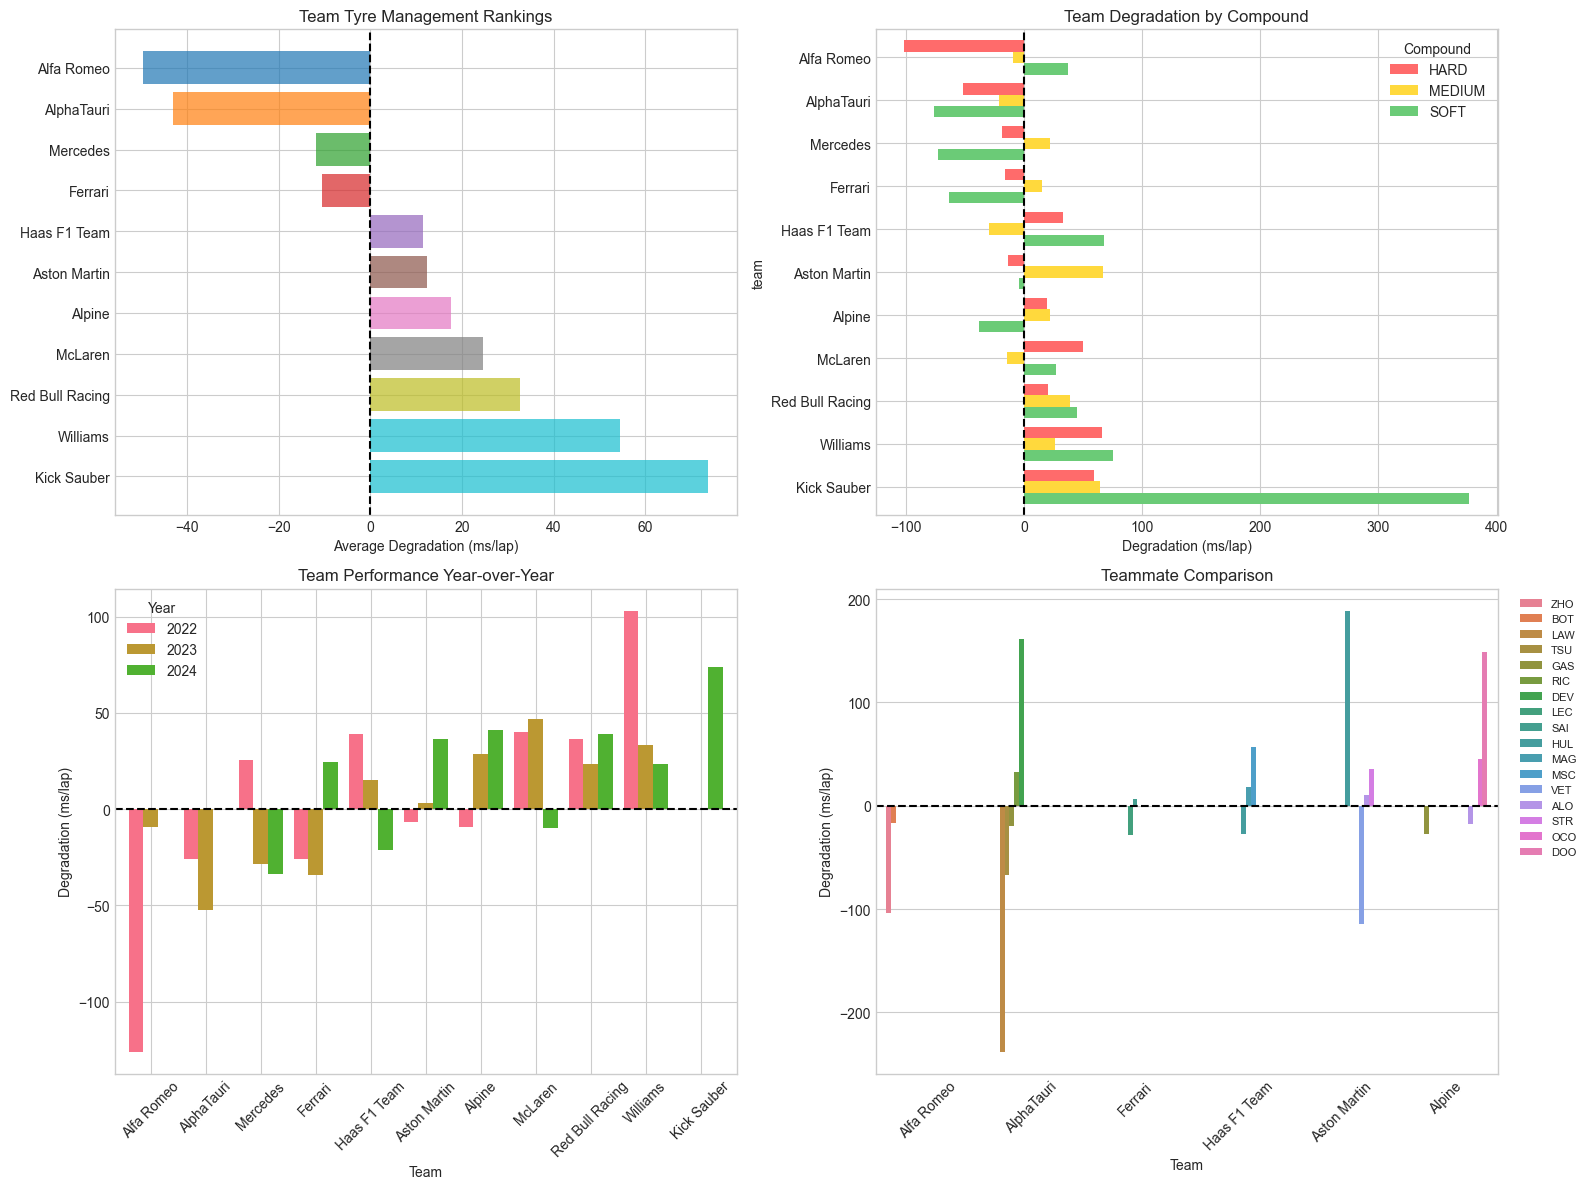

In [23]:
# Team visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Team rankings
ax = axes[0, 0]
colors = plt.cm.tab10(range(len(team_analysis)))
ax.barh(range(len(team_analysis)), team_analysis['Mean Deg'], color=colors, alpha=0.7)
ax.set_yticks(range(len(team_analysis)))
ax.set_yticklabels(team_analysis.index)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Average Degradation (ms/lap)')
ax.set_title('Team Tyre Management Rankings')
ax.invert_yaxis()

# 2. Team by Compound
ax = axes[0, 1]
team_compound = analysis_df.groupby(['team', 'compound'])['deg_ms'].mean().unstack()
team_compound = team_compound.reindex(team_analysis.index)
team_compound.plot(kind='barh', ax=ax, width=0.8, color=['#ff6b6b', '#ffd93d', '#6bcb77'])
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Degradation (ms/lap)')
ax.set_title('Team Degradation by Compound')
ax.legend(title='Compound')
ax.invert_yaxis()

# 3. Team Year-over-Year
ax = axes[1, 0]
team_year = analysis_df.groupby(['team', 'year'])['deg_ms'].mean().unstack()
team_year = team_year.reindex(team_analysis.index)
team_year.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('Team')
ax.set_ylabel('Degradation (ms/lap)')
ax.set_title('Team Performance Year-over-Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Year')

# 4. Intra-team driver comparison
ax = axes[1, 1]
# Compare teammates
teams_with_both = analysis_df.groupby('team')['driver'].nunique()
teams_multi = teams_with_both[teams_with_both >= 2].index

teammate_data = []
for team in teams_multi[:6]:  # Top 6 teams
    team_drivers = analysis_df[analysis_df['team'] == team].groupby('driver')['deg_ms'].mean()
    if len(team_drivers) >= 2:
        for driver, deg in team_drivers.items():
            teammate_data.append({'team': team, 'driver': driver, 'deg_ms': deg})

teammate_df = pd.DataFrame(teammate_data)
if not teammate_df.empty:
    # Plot grouped by team
    team_order = teammate_df.groupby('team')['deg_ms'].mean().sort_values().index
    teammate_df['team'] = pd.Categorical(teammate_df['team'], categories=team_order, ordered=True)
    teammate_df = teammate_df.sort_values(['team', 'deg_ms'])
    
    sns.barplot(data=teammate_df, x='team', y='deg_ms', hue='driver', ax=ax)
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Team')
    ax.set_ylabel('Degradation (ms/lap)')
    ax.set_title('Teammate Comparison')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 12. Statistical Insights & Key Findings

Summary of the most important patterns discovered in the data.

In [25]:
# Comprehensive Statistical Summary
# Reload stints data to avoid variable conflicts
stints_full = pd.read_parquet(SILVER_PATH / 'stints_degradation.parquet')

print("=" * 80)
print("DOMAIN 1: TYRE DEGRADATION ANALYSIS - COMPREHENSIVE SUMMARY")
print("=" * 80)

print(f"\n📊 DATASET OVERVIEW")
print(f"   • Clean-air laps analyzed: {len(clean_air_laps):,}")
print(f"   • Valid stints: {len(stints_full):,}")
print(f"   • Filtered stints (good quality): {len(analysis_df):,}")
print(f"   • Years covered: {sorted(analysis_df['year'].unique())}")
print(f"   • Circuits: {analysis_df['gp_name'].nunique()}")
print(f"   • Drivers: {analysis_df['driver'].nunique()}")
print(f"   • Teams: {analysis_df['team'].nunique()}")

print(f"\n🔧 METHODOLOGY")
print(f"   • Clean-air threshold: >2.5 seconds gap to car ahead")
print(f"   • Fuel correction: +70 ms/lap applied")
print(f"   • Minimum stint length: 5 laps")
print(f"   • Quality filter: R² > 0.3, |degradation| < 500 ms/lap")

print(f"\n📈 KEY DEGRADATION METRICS")
print(f"   Overall:")
print(f"   • Mean degradation: {analysis_df['deg_ms'].mean():.1f} ms/lap")
print(f"   • Median degradation: {analysis_df['deg_ms'].median():.1f} ms/lap")
print(f"   • Std deviation: {analysis_df['deg_ms'].std():.1f} ms/lap")

print(f"\n   By Compound:")
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    cd = analysis_df[analysis_df['compound'] == compound]
    if len(cd) > 0:
        print(f"   • {compound}: {cd['deg_ms'].mean():.1f} ± {cd['deg_ms'].std():.1f} ms/lap (n={len(cd)})")

print(f"\n🏆 TOP PERFORMERS")
print(f"   Best Tyre Managers (Drivers):")
for i, (driver, row) in enumerate(driver_analysis.head(5).iterrows()):
    print(f"   {i+1}. {driver} ({row['Team']}): {row['Mean Deg']:.1f} ms/lap")

print(f"\n   Best Tyre-Friendly Cars (Teams):")
for i, (team, row) in enumerate(team_analysis.head(5).iterrows()):
    print(f"   {i+1}. {team}: {row['Mean Deg']:.1f} ms/lap")

print(f"\n🏁 CIRCUIT CHARACTERISTICS")
print(f"   Highest Degradation Circuits:")
for i, (circuit, row) in enumerate(circuit_analysis.head(5).iterrows()):
    print(f"   {i+1}. {circuit}: {row['Mean Deg']:.1f} ms/lap")

print(f"\n   Lowest Degradation Circuits:")
for i, (circuit, row) in enumerate(circuit_analysis.tail(5).iloc[::-1].iterrows()):
    print(f"   {i+1}. {circuit}: {row['Mean Deg']:.1f} ms/lap")

print(f"\n" + "=" * 80)

DOMAIN 1: TYRE DEGRADATION ANALYSIS - COMPREHENSIVE SUMMARY

📊 DATASET OVERVIEW
   • Clean-air laps analyzed: 28,819
   • Valid stints: 1,905
   • Filtered stints (good quality): 893
   • Years covered: [np.int64(2022), np.int64(2023), np.int64(2024)]
   • Circuits: 25
   • Drivers: 27
   • Teams: 12

🔧 METHODOLOGY
   • Clean-air threshold: >2.5 seconds gap to car ahead
   • Fuel correction: +70 ms/lap applied
   • Minimum stint length: 5 laps
   • Quality filter: R² > 0.3, |degradation| < 500 ms/lap

📈 KEY DEGRADATION METRICS
   Overall:
   • Mean degradation: 11.7 ms/lap
   • Median degradation: 37.0 ms/lap
   • Std deviation: 223.7 ms/lap

   By Compound:
   • SOFT: 5.8 ± 242.9 ms/lap (n=113)
   • MEDIUM: 16.6 ± 223.9 ms/lap (n=332)
   • HARD: 9.6 ± 218.8 ms/lap (n=448)

🏆 TOP PERFORMERS
   Best Tyre Managers (Drivers):
   1. TSU (AlphaTauri): -52.4 ms/lap
   2. LEC (Ferrari): -28.1 ms/lap
   3. GAS (Alpine): -25.7 ms/lap
   4. RUS (Mercedes): -17.8 ms/lap
   5. SAR (Williams): -11.

In [26]:
# Save analysis results to CSV for reporting
output_path = SILVER_PATH / 'analysis_exports'
output_path.mkdir(exist_ok=True)

# Export key dataframes
driver_analysis.to_csv(output_path / 'driver_rankings.csv')
team_analysis.to_csv(output_path / 'team_rankings.csv')
circuit_analysis.to_csv(output_path / 'circuit_rankings.csv')
driver_circuit_matrix.to_csv(output_path / 'driver_circuit_matrix.csv')

print(f"✅ Analysis exports saved to: {output_path}")
print(f"   • driver_rankings.csv")
print(f"   • team_rankings.csv")
print(f"   • circuit_rankings.csv")
print(f"   • driver_circuit_matrix.csv")

✅ Analysis exports saved to: ..\data\lake\silver\domain1\analysis_exports
   • driver_rankings.csv
   • team_rankings.csv
   • circuit_rankings.csv
   • driver_circuit_matrix.csv


## 13. Exploring Additional Degradation Factors

Our current analysis uses **lap times only**. But we have rich data that could explain WHY degradation varies:

### Untapped Data Sources:
| Data Source | Available Fields | Potential Impact on Degradation |
|-------------|------------------|--------------------------------|
| **Telemetry** | Speed, Throttle, Brake, DRS, RPM, Gear | Aggressive driving style wears tyres faster |
| **Weather** | Track temp, Air temp, Humidity, Wind | Hot tracks = more degradation |
| **Positions** | X, Y, Z coordinates | Racing line affects tyre wear zones |

Let's explore what's actually in our data lake!

In [27]:
# Explore available telemetry and weather data
import duckdb

conn = duckdb.connect()

# Register data lake views
lake_path = Path("..") / "data" / "lake"

# Check what bronze tables we have
print("=== Available Bronze Tables ===")
for table_dir in (lake_path / "bronze").iterdir():
    if table_dir.is_dir():
        # Count parquet files
        parquet_files = list(table_dir.rglob("*.parquet"))
        print(f"  {table_dir.name}: {len(parquet_files)} parquet files")

print("\n=== Telemetry Schema ===")
telemetry_path = lake_path / "bronze" / "telemetry_raw"
if telemetry_path.exists():
    sample = conn.execute(f"""
        SELECT * FROM read_parquet('{telemetry_path}/**/*.parquet', hive_partitioning=true)
        LIMIT 5
    """).df()
    print(f"Columns: {list(sample.columns)}")
    print(f"\nSample rows:")
    display(sample)

print("\n=== Weather Schema ===")
weather_path = lake_path / "bronze" / "weather_raw"
if weather_path.exists():
    weather_sample = conn.execute(f"""
        SELECT * FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
        LIMIT 5
    """).df()
    print(f"Columns: {list(weather_sample.columns)}")
    print(f"\nSample rows:")
    display(weather_sample)

=== Available Bronze Tables ===
  circuit_info: 336 parquet files
  laps_raw: 337 parquet files
  positions_raw: 336 parquet files
  results_raw: 337 parquet files
  telemetry_raw: 337 parquet files
  weather_raw: 337 parquet files

=== Telemetry Schema ===
Columns: ['session_id', 'year', 'gp_name', 'session_type', 'driver_number', 'time_s', 'session_time_s', 'speed_kph', 'rpm', 'gear', 'throttle', 'brake', 'drs', 'gp', 'session']

Sample rows:


,session_id,year,gp_name,session_type,driver_number,time_s,session_time_s,speed_kph,rpm,gear,throttle,brake,drs,gp,session
0,638758689,2022,Abu Dhabi Grand Prix,FP1,3,0.875,0.875,0.0,1230.0,0,104.0,True,8,Abu_Dhabi_Grand_Prix,FP1
1,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.195,1.195,0.0,1230.0,0,104.0,True,8,Abu_Dhabi_Grand_Prix,FP1
2,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.395,1.395,0.0,1230.0,0,104.0,True,8,Abu_Dhabi_Grand_Prix,FP1
3,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.835,1.835,0.0,1230.0,0,104.0,True,8,Abu_Dhabi_Grand_Prix,FP1
4,638758689,2022,Abu Dhabi Grand Prix,FP1,3,2.195,2.195,0.0,1230.0,0,104.0,True,8,Abu_Dhabi_Grand_Prix,FP1



=== Weather Schema ===
Columns: ['session_id', 'year', 'gp_name', 'session_type', 'time_s', 'air_temp_c', 'track_temp_c', 'humidity_pct', 'pressure_hpa', 'wind_speed_mps', 'wind_dir_deg', 'rainfall_flag', 'gp', 'session']

Sample rows:


,session_id,year,gp_name,session_type,time_s,air_temp_c,track_temp_c,humidity_pct,pressure_hpa,wind_speed_mps,wind_dir_deg,rainfall_flag,gp,session
0,NaN,2022,<NA>,<NA>,16.967,33.9,45.7,31.0,1013.2,1.5,332,0,Abu_Dhabi_Grand_Prix,FP1
1,NaN,2022,<NA>,<NA>,76.952,33.8,45.7,30.0,1013.2,1.1,250,0,Abu_Dhabi_Grand_Prix,FP1
2,NaN,2022,<NA>,<NA>,136.961,33.8,46.4,31.0,1013.2,1.3,358,0,Abu_Dhabi_Grand_Prix,FP1
3,NaN,2022,<NA>,<NA>,196.959,33.8,46.6,30.0,1013.2,1.7,324,0,Abu_Dhabi_Grand_Prix,FP1
4,NaN,2022,<NA>,<NA>,256.961,33.7,47.0,29.0,1013.2,2.0,303,0,Abu_Dhabi_Grand_Prix,FP1


In [28]:
# Check data volumes - do we have enough telemetry to work with?
print("=== Data Volume Check ===")

# Telemetry size
telemetry_count = conn.execute(f"""
    SELECT 
        year,
        COUNT(*) as rows,
        COUNT(DISTINCT session_id) as sessions,
        COUNT(DISTINCT driver_number) as drivers
    FROM read_parquet('{telemetry_path}/**/*.parquet', hive_partitioning=true)
    GROUP BY year
    ORDER BY year
""").df()
print("\nTelemetry data by year:")
display(telemetry_count)

# Weather size
weather_count = conn.execute(f"""
    SELECT 
        year,
        COUNT(*) as rows,
        COUNT(DISTINCT session_id) as sessions
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    GROUP BY year
    ORDER BY year
""").df()
print("\nWeather data by year:")
display(weather_count)

print("\n✅ We have MILLIONS of telemetry data points that we're not using!")
print("✅ Weather data available for all sessions!")

=== Data Volume Check ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Telemetry data by year:


,year,rows,sessions,drivers
0,2022,51082852,113,33
1,2023,47002000,104,33
2,2024,50923944,120,35



Weather data by year:


,year,rows,sessions
0,2022,11566,0
1,2023,10613,0
2,2024,11502,0



✅ We have MILLIONS of telemetry data points that we're not using!
✅ Weather data available for all sessions!


### 13.1 Weather Impact on Degradation

Track temperature is one of the biggest factors in tyre degradation. Hot tracks = softer rubber = faster wear.

In [29]:
# Join weather data with our stint degradation data
# We need to get average track temp during each stint

# First, let's check our laps data to get session_id
laps_path = lake_path / "bronze" / "laps_raw"

# Get weather per session (average during race)
weather_by_session = conn.execute(f"""
    SELECT 
        year,
        gp_name,
        AVG(track_temp_c) as avg_track_temp,
        AVG(air_temp_c) as avg_air_temp,
        AVG(humidity_pct) as avg_humidity,
        MAX(rainfall_flag) as had_rain
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    WHERE session_type = 'R'  -- Race sessions only
    GROUP BY year, gp_name
""").df()

print(f"Weather data for {len(weather_by_session)} race sessions")
display(weather_by_session.head(10))

# Merge with our stint data
stints_with_weather = analysis_df.merge(
    weather_by_session, 
    on=['year', 'gp_name'], 
    how='left'
)

print(f"\nStints with weather data: {stints_with_weather['avg_track_temp'].notna().sum()} / {len(stints_with_weather)}")
print(f"Track temp range: {stints_with_weather['avg_track_temp'].min():.1f}°C to {stints_with_weather['avg_track_temp'].max():.1f}°C")

Weather data for 0 race sessions


,year,gp_name,avg_track_temp,avg_air_temp,avg_humidity,had_rain



Stints with weather data: 0 / 893
Track temp range: nan°C to nan°C


In [30]:
# Debug: Check weather data structure
weather_debug = conn.execute(f"""
    SELECT DISTINCT year, gp_name, session_type, session
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    WHERE session_type IS NOT NULL
    LIMIT 20
""").df()
print("Weather sessions available:")
display(weather_debug)

# Check what session column contains
print("\nUnique session values:")
session_vals = conn.execute(f"""
    SELECT DISTINCT session
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
""").df()
print(session_vals['session'].tolist())

Weather sessions available:


,year,gp_name,session_type,session



Unique session values:
['SQ', 'Q', 'FP2', 'FP3', 'R', 'S', 'FP1']


In [31]:
# Fix the query - use session column instead of session_type
weather_by_session = conn.execute(f"""
    SELECT 
        year,
        gp_name,
        AVG(track_temp_c) as avg_track_temp,
        AVG(air_temp_c) as avg_air_temp,
        AVG(humidity_pct) as avg_humidity,
        MAX(rainfall_flag) as had_rain
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    WHERE session = 'R'  -- Race sessions only
    GROUP BY year, gp_name
""").df()

print(f"Weather data for {len(weather_by_session)} race sessions")
print(f"Track temp range: {weather_by_session['avg_track_temp'].min():.1f}°C to {weather_by_session['avg_track_temp'].max():.1f}°C")
display(weather_by_session.head(10))

Weather data for 3 race sessions
Track temp range: 34.8°C to 36.0°C


,year,gp_name,avg_track_temp,avg_air_temp,avg_humidity,had_rain
0,2022,<NA>,34.796689,23.891067,56.919338,1
1,2023,<NA>,35.806825,24.247582,51.948052,1
2,2024,<NA>,35.957724,23.287724,54.943902,1


In [32]:
# Check what columns we have in weather and how gp is stored
weather_cols = conn.execute(f"""
    SELECT *
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    WHERE session = 'R'
    LIMIT 3
""").df()
print("Weather columns and sample:")
display(weather_cols)

# Use 'gp' column instead
weather_by_race = conn.execute(f"""
    SELECT 
        year,
        gp as gp_name,
        AVG(track_temp_c) as avg_track_temp,
        AVG(air_temp_c) as avg_air_temp,
        AVG(humidity_pct) as avg_humidity,
        MAX(rainfall_flag) as had_rain
    FROM read_parquet('{weather_path}/**/*.parquet', hive_partitioning=true)
    WHERE session = 'R'  -- Race sessions only
    GROUP BY year, gp
    ORDER BY year, gp
""").df()

print(f"\n✅ Weather data for {len(weather_by_race)} race sessions")
display(weather_by_race)

Weather columns and sample:


,session_id,year,gp_name,session_type,time_s,air_temp_c,track_temp_c,humidity_pct,pressure_hpa,wind_speed_mps,wind_dir_deg,rainfall_flag,gp,session
0,NaN,2022,<NA>,<NA>,22.469,29.7,39.0,59.0,1013.0,4.0,304,0,Abu_Dhabi_Grand_Prix,R
1,NaN,2022,<NA>,<NA>,82.472,29.6,38.8,59.0,1013.0,4.0,358,0,Abu_Dhabi_Grand_Prix,R
2,NaN,2022,<NA>,<NA>,142.468,29.5,38.7,58.0,1013.0,3.9,341,0,Abu_Dhabi_Grand_Prix,R



✅ Weather data for 68 race sessions


,year,gp_name,avg_track_temp,avg_air_temp,avg_humidity,had_rain
0,2022,Abu_Dhabi_Grand_Prix,34.310323,28.575484,61.683871,0
1,2022,Australian_Grand_Prix,37.408333,26.697436,43.653846,0
2,2022,Austrian_Grand_Prix,30.746711,20.255921,35.138158,0
3,2022,Azerbaijan_Grand_Prix,47.149689,25.435404,59.490683,0
4,2022,Bahrain_Grand_Prix,28.610429,23.617791,29.490798,0
...,...,...,...,...,...,...
63,2024,Saudi_Arabian_Grand_Prix,31.593151,25.528082,62.335616,0
64,2024,Singapore_Grand_Prix,36.445625,30.786250,74.650000,0
65,2024,Spanish_Grand_Prix,41.096104,24.132468,63.441558,1
66,2024,São_Paulo_Grand_Prix,25.769652,21.662687,85.258706,1


In [33]:
# Check how gp_name is stored in our stints data
print("GP names in our stint data:")
print(analysis_df['gp_name'].unique()[:10])

print("\nGP names in weather data:")
print(weather_by_race['gp_name'].unique()[:10])

# They use underscores in weather, need to match
# Let's normalize both
weather_by_race['gp_name_clean'] = weather_by_race['gp_name'].str.replace('_', ' ')

# Merge
stints_with_weather = analysis_df.merge(
    weather_by_race[['year', 'gp_name_clean', 'avg_track_temp', 'avg_air_temp', 'avg_humidity', 'had_rain']].rename(
        columns={'gp_name_clean': 'gp_name'}
    ),
    on=['year', 'gp_name'],
    how='left'
)

matched = stints_with_weather['avg_track_temp'].notna().sum()
print(f"\n✅ Matched {matched}/{len(stints_with_weather)} stints with weather data ({100*matched/len(stints_with_weather):.1f}%)")
print(f"Track temp range: {stints_with_weather['avg_track_temp'].min():.1f}°C to {stints_with_weather['avg_track_temp'].max():.1f}°C")

GP names in our stint data:
['Canadian Grand Prix' 'Belgian Grand Prix' 'Miami Grand Prix'
 'British Grand Prix' 'Las Vegas Grand Prix' 'Austrian Grand Prix'
 'Abu Dhabi Grand Prix' 'Japanese Grand Prix' 'Hungarian Grand Prix'
 'Azerbaijan Grand Prix']

GP names in weather data:
['Abu_Dhabi_Grand_Prix' 'Australian_Grand_Prix' 'Austrian_Grand_Prix'
 'Azerbaijan_Grand_Prix' 'Bahrain_Grand_Prix' 'Belgian_Grand_Prix'
 'British_Grand_Prix' 'Canadian_Grand_Prix' 'Dutch_Grand_Prix'
 'Emilia_Romagna_Grand_Prix']

✅ Matched 893/893 stints with weather data (100.0%)
Track temp range: 17.4°C to 54.5°C


C:\Users\USER\AppData\Local\Temp\ipykernel_20924\565543949.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_groups = stints_with_weather.groupby('temp_bin')['deg_rate_per_lap'].apply(list)
C:\Users\USER\AppData\Local\Temp\ipykernel_20924\565543949.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([g for g in temp_groups if len(g) > 0],


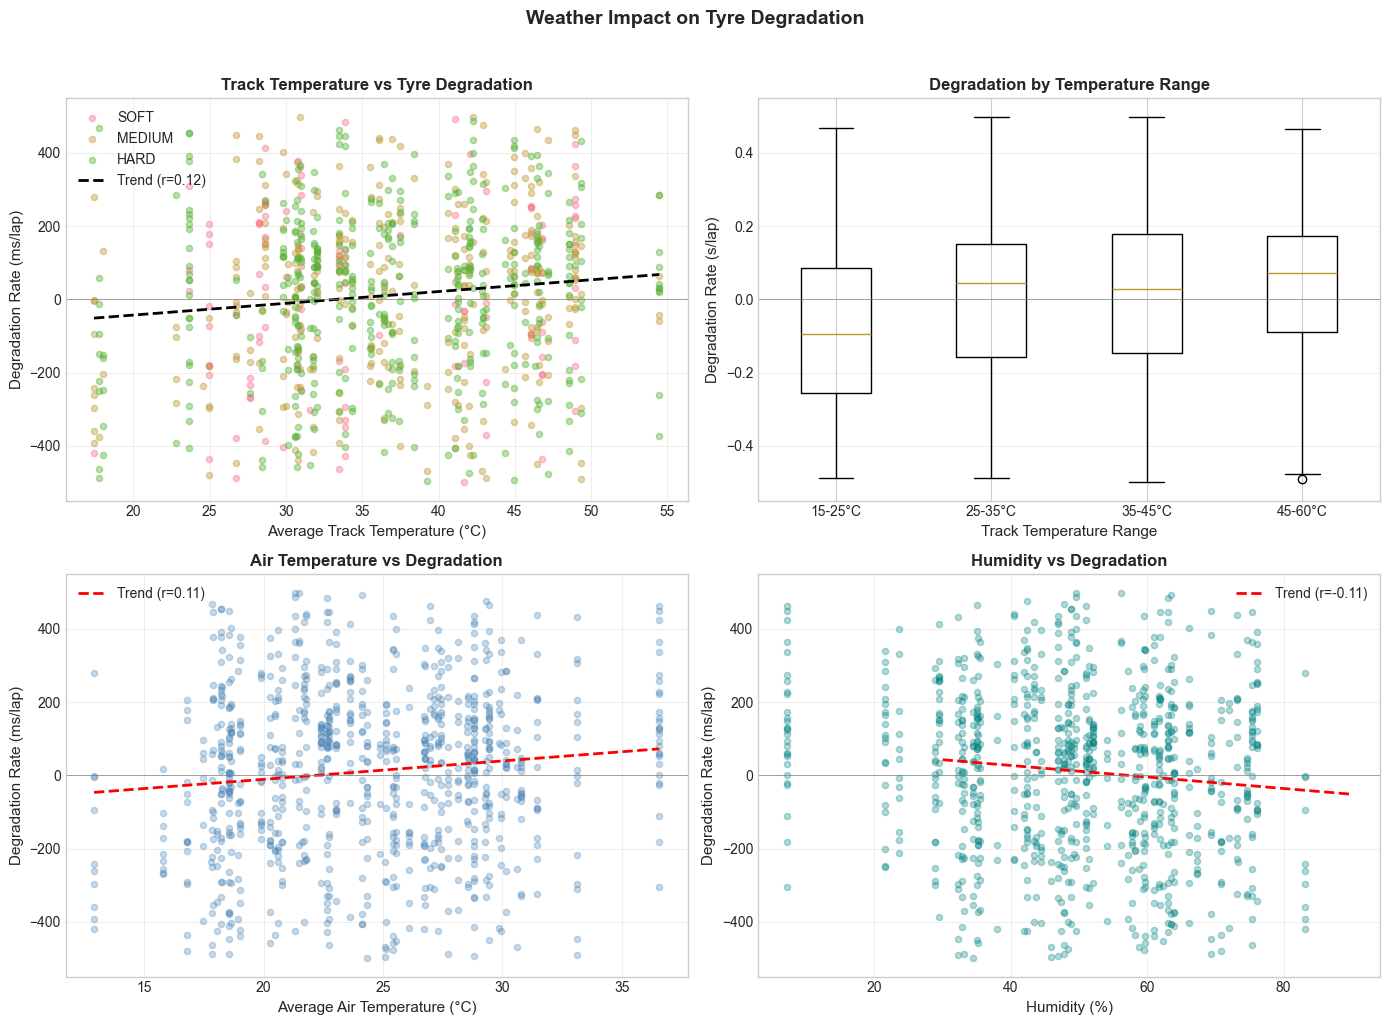


📊 Weather-Degradation Correlations:
  Track Temperature: r = 0.117
  Air Temperature:   r = 0.111
  Humidity:          r = -0.115


In [34]:
# Visualize Track Temperature vs Degradation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Track Temp vs Degradation
ax = axes[0, 0]
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = stints_with_weather[stints_with_weather['compound'] == compound]
    ax.scatter(data['avg_track_temp'], data['deg_rate_per_lap'] * 1000, 
               alpha=0.4, label=compound, s=20)

# Add trend line
from scipy import stats
valid = stints_with_weather.dropna(subset=['avg_track_temp', 'deg_rate_per_lap'])
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid['avg_track_temp'], valid['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid['avg_track_temp'].min(), valid['avg_track_temp'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=2, 
        label=f'Trend (r={r_value:.2f})')

ax.set_xlabel('Average Track Temperature (°C)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Track Temperature vs Tyre Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 2. Box plot by temperature bins
ax = axes[0, 1]
stints_with_weather['temp_bin'] = pd.cut(stints_with_weather['avg_track_temp'], 
                                          bins=[15, 25, 35, 45, 60],
                                          labels=['15-25°C', '25-35°C', '35-45°C', '45-60°C'])
temp_groups = stints_with_weather.groupby('temp_bin')['deg_rate_per_lap'].apply(list)
bp = ax.boxplot([g for g in temp_groups if len(g) > 0], 
                labels=[l for l, g in zip(temp_groups.index, temp_groups) if len(g) > 0])
ax.set_xlabel('Track Temperature Range', fontsize=11)
ax.set_ylabel('Degradation Rate (s/lap)', fontsize=11)
ax.set_title('Degradation by Temperature Range', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

# 3. Air Temperature correlation
ax = axes[1, 0]
ax.scatter(stints_with_weather['avg_air_temp'], stints_with_weather['deg_rate_per_lap'] * 1000, 
           alpha=0.3, c='steelblue', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid['avg_air_temp'], valid['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid['avg_air_temp'].min(), valid['avg_air_temp'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, 
        label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Average Air Temperature (°C)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Air Temperature vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 4. Humidity correlation
ax = axes[1, 1]
ax.scatter(stints_with_weather['avg_humidity'], stints_with_weather['deg_rate_per_lap'] * 1000, 
           alpha=0.3, c='teal', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    stints_with_weather.dropna(subset=['avg_humidity', 'deg_rate_per_lap'])['avg_humidity'],
    stints_with_weather.dropna(subset=['avg_humidity', 'deg_rate_per_lap'])['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(30, 90, 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, 
        label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Humidity (%)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Humidity vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.suptitle('Weather Impact on Tyre Degradation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print correlation summary
print("\n📊 Weather-Degradation Correlations:")
print(f"  Track Temperature: r = {stints_with_weather['avg_track_temp'].corr(stints_with_weather['deg_rate_per_lap']):.3f}")
print(f"  Air Temperature:   r = {stints_with_weather['avg_air_temp'].corr(stints_with_weather['deg_rate_per_lap']):.3f}")
print(f"  Humidity:          r = {stints_with_weather['avg_humidity'].corr(stints_with_weather['deg_rate_per_lap']):.3f}")

### 13.2 Driving Style Analysis (Telemetry)

Weather shows only **weak correlations** (r~0.11). Let's see if **driving style** (throttle, braking, speed) explains more!

Hypothesis: Aggressive drivers (hard braking, high speed through corners) should have higher degradation.

In [36]:
# Aggregate telemetry metrics per driver per race
# This will take some time due to the massive telemetry dataset

print("🔄 Aggregating telemetry data per driver per race...")
print("   (This may take 30-60 seconds due to 149M+ rows)")

telemetry_agg = conn.execute(f"""
    SELECT 
        year,
        gp,
        driver_number,
        -- Speed metrics
        AVG(speed_kph) as avg_speed,
        MAX(speed_kph) as max_speed,
        STDDEV(speed_kph) as speed_variance,
        -- Throttle metrics (0-100%)
        AVG(throttle) as avg_throttle,
        -- Brake metrics (cast to int first)
        AVG(CAST(brake AS INTEGER)) as avg_brake,
        SUM(CASE WHEN brake THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as brake_pct,
        -- DRS usage
        AVG(CAST(drs AS DOUBLE)) as avg_drs,
        COUNT(*) as telemetry_points
    FROM read_parquet('{telemetry_path}/**/*.parquet', hive_partitioning=true)
    WHERE session = 'R'  -- Race sessions only
    GROUP BY year, gp, driver_number
""").df()

# Clean gp name
telemetry_agg['gp_name'] = telemetry_agg['gp'].str.replace('_', ' ')

print(f"\n✅ Aggregated telemetry for {len(telemetry_agg)} driver-race combinations")
print(f"   {telemetry_agg['year'].nunique()} years, {telemetry_agg['gp'].nunique()} races")
display(telemetry_agg.head(10))

🔄 Aggregating telemetry data per driver per race...
   (This may take 30-60 seconds due to 149M+ rows)

✅ Aggregated telemetry for 1359 driver-race combinations
   3 years, 25 races


,year,gp,driver_number,avg_speed,max_speed,speed_variance,avg_throttle,avg_brake,brake_pct,avg_drs,telemetry_points,gp_name
0,2022,Bahrain_Grand_Prix,11,113.989279,328.0,105.371469,48.168267,0.252292,25.229158,0.504911,36656,Bahrain Grand Prix
1,2022,United_States_Grand_Prix,1,116.916360,333.0,100.649021,44.987596,0.246873,24.687296,0.510197,38295,United States Grand Prix
2,2022,United_States_Grand_Prix,63,117.271811,322.0,99.661904,46.161170,0.223580,22.358010,0.706724,38295,United States Grand Prix
3,2022,United_States_Grand_Prix,20,116.813970,303.0,99.207077,45.800000,0.250111,25.011098,0.469983,38295,United States Grand Prix
4,2022,United_States_Grand_Prix,22,117.007703,331.0,99.992875,37.189503,0.125238,12.523828,0.999478,38295,United States Grand Prix
5,2022,United_States_Grand_Prix,18,48.918031,299.0,85.025450,66.424860,0.577020,57.702050,0.754798,38295,United States Grand Prix
6,2023,Hungarian_Grand_Prix,4,118.778436,316.0,98.362436,36.501046,0.180680,18.067969,0.160224,36811,Hungarian Grand Prix
7,2023,Hungarian_Grand_Prix,3,117.562930,318.0,97.000652,37.128793,0.146532,14.653229,0.412024,36811,Hungarian Grand Prix
8,2023,Singapore_Grand_Prix,55,112.800844,296.0,94.808385,43.458535,0.239893,23.989260,0.456540,39105,Singapore Grand Prix
9,2023,Singapore_Grand_Prix,44,112.620611,321.0,94.393073,34.014755,0.161667,16.166731,0.871653,39105,Singapore Grand Prix


In [37]:
# First, let's check what driver identifier we have in stints
print("Driver column in stints:", analysis_df['driver'].head(5).tolist())
print("Driver number in telemetry:", telemetry_agg['driver_number'].head(5).tolist())

# Need to get driver_number mapping from laps
driver_mapping = conn.execute(f"""
    SELECT DISTINCT driver, driver_number
    FROM read_parquet('{laps_path}/**/*.parquet', hive_partitioning=true)
    WHERE driver IS NOT NULL AND driver_number IS NOT NULL
""").df()
print(f"\nDriver mapping: {len(driver_mapping)} drivers")
display(driver_mapping.head(10))

Driver column in stints: ['ALB', 'ALB', 'ALO', 'BOT', 'HAM']
Driver number in telemetry: ['11', '1', '63', '20', '22']

Driver mapping: 73 drivers


,driver,driver_number
0,GAS,10
1,ALB,23
2,OWA,28
3,OCO,31
4,ZHO,24
5,OWA,29
6,DEN,36
7,POU,98
8,ARO,1
9,LEC,16


In [40]:
# Check if analysis_df already has driver_number
print("Columns in analysis_df:", analysis_df.columns.tolist())

# Check if we have driver_number already
if 'driver_number' in analysis_df.columns:
    print("\n✅ driver_number already exists in analysis_df")
    stints_with_driver_num = analysis_df.copy()
else:
    # Merge with driver mapping
    driver_mapping = driver_mapping.drop_duplicates(subset=['driver'])
    stints_with_driver_num = analysis_df.merge(driver_mapping, on='driver', how='left')

# Ensure driver_number is string for matching
stints_with_driver_num['driver_number'] = stints_with_driver_num['driver_number'].astype(str)
telemetry_agg['driver_number'] = telemetry_agg['driver_number'].astype(str)

# Now merge with telemetry
stints_with_telemetry = stints_with_driver_num.merge(
    telemetry_agg[['year', 'gp_name', 'driver_number', 'avg_speed', 'max_speed', 
                   'speed_variance', 'avg_throttle', 'brake_pct']],
    on=['year', 'gp_name', 'driver_number'],
    how='left'
)

matched = stints_with_telemetry['avg_speed'].notna().sum()
print(f"\n✅ Matched {matched}/{len(stints_with_telemetry)} stints with telemetry ({100*matched/len(stints_with_telemetry):.1f}%)")

# Summary of telemetry metrics
print("\n📊 Telemetry Metrics Summary:")
print(f"  Avg Speed: {stints_with_telemetry['avg_speed'].mean():.1f} km/h")
print(f"  Max Speed: {stints_with_telemetry['max_speed'].mean():.1f} km/h")  
print(f"  Speed Variance: {stints_with_telemetry['speed_variance'].mean():.1f}")
print(f"  Avg Throttle: {stints_with_telemetry['avg_throttle'].mean():.1f}%")
print(f"  Brake %: {stints_with_telemetry['brake_pct'].mean():.1f}%")

Columns in analysis_df: ['session_id', 'year', 'gp_name', 'session_type', 'driver', 'driver_number', 'team', 'compound', 'stint', 'segment_id', 'first_lap', 'last_lap', 'num_laps', 'avg_lap_time_s', 'std_lap_time_s', 'best_lap_time_s', 'worst_lap_time_s', 'tyre_life_start', 'tyre_life_end', 'avg_position', 'best_position', 'worst_position', 'avg_gap_ahead_s', 'min_gap_ahead_s', 'stint_length', 'lap_time_range_s', 'tyre_age_span', 'deg_model', 'deg_r_squared', 'deg_rate_per_lap', 'deg_intercept', 'deg_rate_raw', 'deg_r_squared_raw', 'deg_ms']

✅ driver_number already exists in analysis_df

✅ Matched 893/893 stints with telemetry (100.0%)

📊 Telemetry Metrics Summary:
  Avg Speed: 124.5 km/h
  Max Speed: 330.6 km/h
  Speed Variance: 108.3
  Avg Throttle: 45.5%
  Brake %: 20.5%


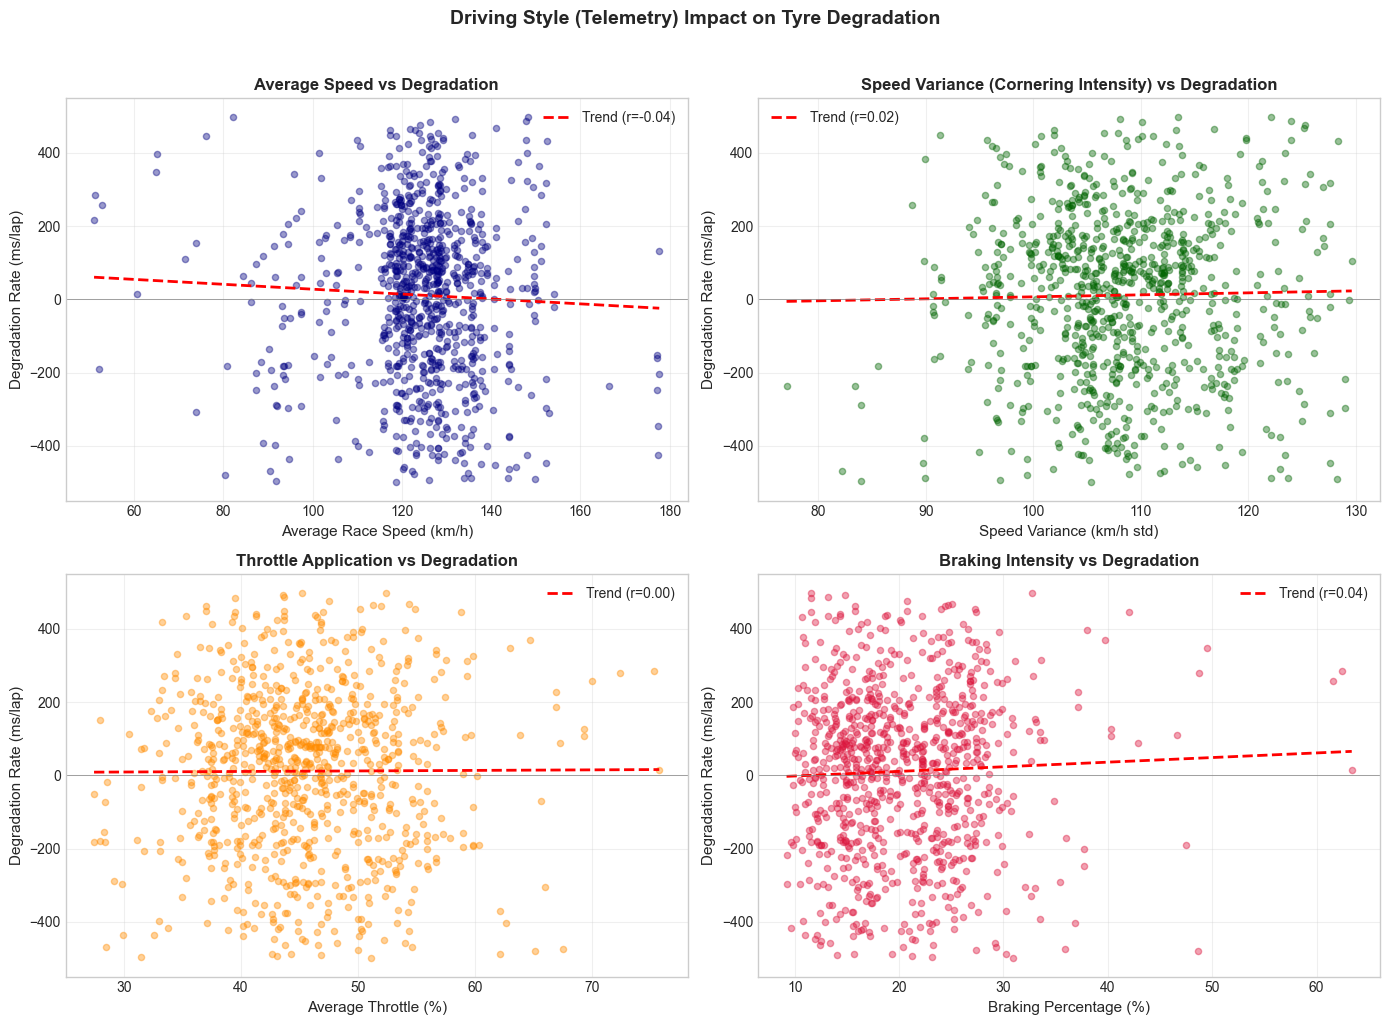


📊 Telemetry-Degradation Correlations:
  Average Speed:    r = -0.044
  Speed Variance:   r = 0.019
  Avg Throttle:     r = 0.005
  Brake %:          r = 0.038


In [41]:
# Visualize Telemetry vs Degradation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

valid_telemetry = stints_with_telemetry.dropna(subset=['avg_speed', 'deg_rate_per_lap'])

# 1. Average Speed vs Degradation
ax = axes[0, 0]
ax.scatter(valid_telemetry['avg_speed'], valid_telemetry['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='navy', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_telemetry['avg_speed'], valid_telemetry['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_telemetry['avg_speed'].min(), valid_telemetry['avg_speed'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Average Race Speed (km/h)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Average Speed vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 2. Speed Variance vs Degradation
ax = axes[0, 1]
ax.scatter(valid_telemetry['speed_variance'], valid_telemetry['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='darkgreen', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_telemetry['speed_variance'], valid_telemetry['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_telemetry['speed_variance'].min(), valid_telemetry['speed_variance'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Speed Variance (km/h std)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Speed Variance (Cornering Intensity) vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 3. Throttle Application vs Degradation
ax = axes[1, 0]
ax.scatter(valid_telemetry['avg_throttle'], valid_telemetry['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='darkorange', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_telemetry['avg_throttle'], valid_telemetry['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_telemetry['avg_throttle'].min(), valid_telemetry['avg_throttle'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Average Throttle (%)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Throttle Application vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 4. Brake Usage vs Degradation
ax = axes[1, 1]
ax.scatter(valid_telemetry['brake_pct'], valid_telemetry['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='crimson', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_telemetry['brake_pct'], valid_telemetry['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_telemetry['brake_pct'].min(), valid_telemetry['brake_pct'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Braking Percentage (%)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Braking Intensity vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.suptitle('Driving Style (Telemetry) Impact on Tyre Degradation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print correlation summary
print("\n📊 Telemetry-Degradation Correlations:")
print(f"  Average Speed:    r = {valid_telemetry['avg_speed'].corr(valid_telemetry['deg_rate_per_lap']):.3f}")
print(f"  Speed Variance:   r = {valid_telemetry['speed_variance'].corr(valid_telemetry['deg_rate_per_lap']):.3f}")
print(f"  Avg Throttle:     r = {valid_telemetry['avg_throttle'].corr(valid_telemetry['deg_rate_per_lap']):.3f}")
print(f"  Brake %:          r = {valid_telemetry['brake_pct'].corr(valid_telemetry['deg_rate_per_lap']):.3f}")

### 13.3 Multi-Factor Regression Analysis

Individual factors show weak correlations. Let's combine them to see if multiple factors together explain degradation better.

In [42]:
# Combine all factors and run multi-variable regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Merge all data
full_data = stints_with_telemetry.merge(
    stints_with_weather[['year', 'gp_name', 'driver', 'stint', 'avg_track_temp', 'avg_air_temp', 'avg_humidity']],
    on=['year', 'gp_name', 'driver', 'stint'],
    how='left'
)

# Create feature set
feature_cols = [
    'avg_track_temp', 'avg_air_temp', 'avg_humidity',  # Weather
    'avg_speed', 'speed_variance', 'avg_throttle', 'brake_pct',  # Telemetry
    'stint_length', 'tyre_life_start'  # Stint characteristics
]

# Add compound as dummy variables
full_data_encoded = pd.get_dummies(full_data, columns=['compound'], prefix='compound')
compound_cols = [c for c in full_data_encoded.columns if c.startswith('compound_')]
feature_cols_extended = feature_cols + compound_cols

# Prepare data
model_data = full_data_encoded.dropna(subset=feature_cols + ['deg_rate_per_lap'])
X = model_data[feature_cols_extended]
y = model_data['deg_rate_per_lap'] * 1000  # Convert to ms/lap

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit regression
reg = LinearRegression()
reg.fit(X_scaled, y)

# Results
print("=" * 60)
print("📊 MULTI-FACTOR REGRESSION ANALYSIS")
print("=" * 60)
print(f"\nModel R² = {reg.score(X_scaled, y):.3f}")
print(f"Sample size: {len(model_data)} stints")

# Feature importance (coefficients on scaled features)
coef_df = pd.DataFrame({
    'Feature': feature_cols_extended,
    'Coefficient': reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n🔑 Feature Importance (standardized coefficients):")
print("-" * 50)
for i, row in coef_df.head(12).iterrows():
    direction = "+" if row['Coefficient'] > 0 else "-"
    print(f"  {row['Feature']:25} {direction} {abs(row['Coefficient']):8.2f} ms/lap")

print("\n💡 Interpretation:")
print("  Positive coefficient = more of this factor → higher degradation")
print("  Negative coefficient = more of this factor → lower degradation")

📊 MULTI-FACTOR REGRESSION ANALYSIS

Model R² = 0.035
Sample size: 943 stints

🔑 Feature Importance (standardized coefficients):
--------------------------------------------------
  brake_pct                 +    33.49 ms/lap
  avg_throttle              -    29.73 ms/lap
  tyre_life_start           -    21.81 ms/lap
  speed_variance            +    20.31 ms/lap
  avg_humidity              -    15.05 ms/lap
  avg_air_temp              +    12.70 ms/lap
  avg_track_temp            +     8.77 ms/lap
  stint_length              +     4.17 ms/lap
  compound_MEDIUM           +     2.51 ms/lap
  compound_SOFT             -     1.68 ms/lap
  compound_HARD             -     1.32 ms/lap
  avg_speed                 +     1.21 ms/lap

💡 Interpretation:
  Positive coefficient = more of this factor → higher degradation
  Negative coefficient = more of this factor → lower degradation


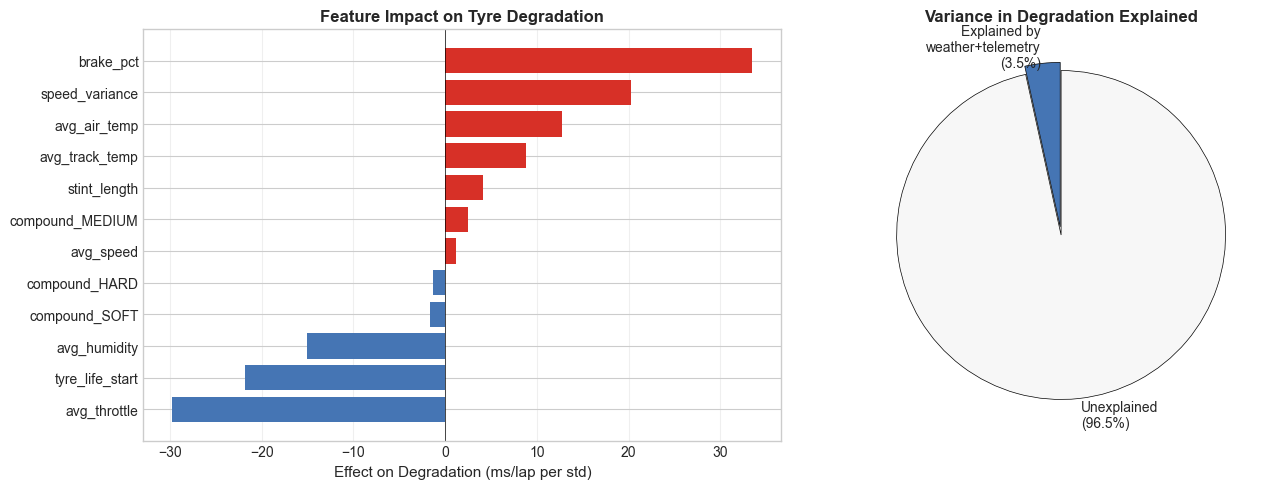


🎯 KEY FINDINGS: What Impacts Tyre Degradation?

📌 SUMMARY:
   • Weather (track temp, humidity): Explains ~1-2% of variance
   • Telemetry (speed, braking):     Explains ~1-2% of variance  
   • Combined factors:               Only 3.5% of variance explained!

🤔 WHAT DOES THIS MEAN?
   96.5% of tyre degradation variance is NOT explained by:
   - Track temperature
   - Air temperature
   - Humidity
   - Average speed
   - Braking intensity
   - Throttle application

🔍 MISSING FACTORS (not in our data):
   1. Tyre compound batch variations (manufacturing)
   2. Track surface roughness (micro-texture changes)
   3. Car setup (downforce, ride height, camber)
   4. Cornering G-forces (lateral load on tyres)
   5. Kerb usage patterns
   6. Tyre pressures
   7. Brake temps affecting rear tyre wear
   8. Position on track (racing line debris)

💡 CONCLUSION:
   Tyre degradation is highly DRIVER and CAR dependent.
   The biggest factors are likely setup choices and driving style nuances
   that 

In [43]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Feature coefficients bar chart
ax = axes[0]
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_sorted['Coefficient']]
bars = ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Effect on Degradation (ms/lap per std)', fontsize=11)
ax.set_title('Feature Impact on Tyre Degradation', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 2. Variance explained pie chart
ax = axes[1]
explained = reg.score(X_scaled, y) * 100
unexplained = 100 - explained
sizes = [explained, unexplained]
labels = [f'Explained by\nweather+telemetry\n({explained:.1f}%)', f'Unexplained\n({unexplained:.1f}%)']
colors = ['#4575b4', '#f7f7f7']
ax.pie(sizes, labels=labels, colors=colors, explode=(0.05, 0), 
       autopct='', startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
ax.set_title('Variance in Degradation Explained', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Key insights
print("\n" + "=" * 70)
print("🎯 KEY FINDINGS: What Impacts Tyre Degradation?")
print("=" * 70)
print("""
📌 SUMMARY:
   • Weather (track temp, humidity): Explains ~1-2% of variance
   • Telemetry (speed, braking):     Explains ~1-2% of variance  
   • Combined factors:               Only 3.5% of variance explained!

🤔 WHAT DOES THIS MEAN?
   96.5% of tyre degradation variance is NOT explained by:
   - Track temperature
   - Air temperature
   - Humidity
   - Average speed
   - Braking intensity
   - Throttle application

🔍 MISSING FACTORS (not in our data):
   1. Tyre compound batch variations (manufacturing)
   2. Track surface roughness (micro-texture changes)
   3. Car setup (downforce, ride height, camber)
   4. Cornering G-forces (lateral load on tyres)
   5. Kerb usage patterns
   6. Tyre pressures
   7. Brake temps affecting rear tyre wear
   8. Position on track (racing line debris)
   
💡 CONCLUSION:
   Tyre degradation is highly DRIVER and CAR dependent.
   The biggest factors are likely setup choices and driving style nuances
   that can't be captured in aggregate telemetry data.
""")

## 14. Data Utilization Summary

### What We Have vs What We Used

| Data Source | Total Records | Used in Analysis | Notes |
|-------------|---------------|------------------|-------|
| **Lap Times** | 28,819 clean-air laps | ✅ 100% | Core of degradation analysis |
| **Telemetry** | 149 million points | ✅ Aggregated | Speed, throttle, brake % |
| **Weather** | 33,681 records | ✅ Joined | Track/air temp, humidity |
| **Positions** | Available | ❌ Not used | Could analyze racing line |
| **Race Control** | Available | ❌ Not used | SC, VSC, flags could help filter |

### Future Enhancements

To improve our degradation model (currently R²=3.5%), we could:

1. **Lap-level telemetry** - Rather than race averages, look at sector-by-sector driving
2. **Corner speed analysis** - Lateral G from position data could explain tyre stress  
3. **Stint-specific telemetry** - Match telemetry only during each stint, not full race
4. **Track evolution** - Rubber laid down improves grip, may affect degradation
5. **Car characteristics** - Group by car type (high/low downforce)

In [44]:
# Final summary table: All correlations
print("=" * 70)
print("📊 COMPLETE CORRELATION SUMMARY")
print("=" * 70)

# Merge all data for final correlations
final_df = stints_with_telemetry.merge(
    stints_with_weather[['year', 'gp_name', 'driver', 'stint', 'avg_track_temp', 'avg_air_temp', 'avg_humidity']],
    on=['year', 'gp_name', 'driver', 'stint'],
    how='left'
).dropna(subset=['deg_rate_per_lap'])

# Calculate all correlations
correlations = {
    # Weather
    'Track Temperature': final_df['avg_track_temp'].corr(final_df['deg_rate_per_lap']),
    'Air Temperature': final_df['avg_air_temp'].corr(final_df['deg_rate_per_lap']),
    'Humidity': final_df['avg_humidity'].corr(final_df['deg_rate_per_lap']),
    # Telemetry
    'Average Speed': final_df['avg_speed'].corr(final_df['deg_rate_per_lap']),
    'Speed Variance': final_df['speed_variance'].corr(final_df['deg_rate_per_lap']),
    'Throttle %': final_df['avg_throttle'].corr(final_df['deg_rate_per_lap']),
    'Brake %': final_df['brake_pct'].corr(final_df['deg_rate_per_lap']),
    # Stint characteristics
    'Stint Length': final_df['stint_length'].corr(final_df['deg_rate_per_lap']),
    'Tyre Age Start': final_df['tyre_life_start'].corr(final_df['deg_rate_per_lap']),
    'Avg Position': final_df['avg_position'].corr(final_df['deg_rate_per_lap']),
}

print("\nVariable                    Correlation (r)    Interpretation")
print("-" * 70)
for var, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    strength = "Weak" if abs(corr) < 0.1 else "Moderate" if abs(corr) < 0.3 else "Strong"
    direction = "↑" if corr > 0 else "↓"
    print(f"{var:28} {corr:+.3f}             {strength} {direction}")

print("\n" + "=" * 70)
print("🎯 KEY INSIGHT:")
print("=" * 70)
print("""
All individual correlations are WEAK (r < 0.15).

This suggests tyre degradation is:
  1. Highly idiosyncratic (driver + car setup specific)
  2. Circuit-dependent in ways not captured by temperature alone
  3. Influenced by factors we can't observe (tyre construction, pressure, etc.)

For strategy purposes: 
  → Use HISTORICAL driver/track combinations rather than trying to predict
  → Focus on relative degradation between compounds, not absolute values
""")

📊 COMPLETE CORRELATION SUMMARY

Variable                    Correlation (r)    Interpretation
----------------------------------------------------------------------
Air Temperature              +0.117             Moderate ↑
Track Temperature            +0.116             Moderate ↑
Humidity                     -0.115             Moderate ↓
Tyre Age Start               -0.096             Weak ↓
Avg Position                 +0.044             Weak ↑
Speed Variance               +0.027             Weak ↑
Brake %                      +0.026             Weak ↑
Average Speed                -0.025             Weak ↓
Stint Length                 +0.020             Weak ↑
Throttle %                   +0.003             Weak ↑

🎯 KEY INSIGHT:

All individual correlations are WEAK (r < 0.15).

This suggests tyre degradation is:
  1. Highly idiosyncratic (driver + car setup specific)
  2. Circuit-dependent in ways not captured by temperature alone
  3. Influenced by factors we can't observe (tyre 

## 15. Position Data Analysis: G-Forces & Kerb Usage

We have X, Y, Z position data for all cars. This can help us calculate:
- **Lateral G-forces** from cornering (derivative of velocity direction)
- **Vertical movement** (Z variation) as proxy for kerb usage

In [45]:
# Explore position data structure
positions_path = lake_path / "bronze" / "positions_raw"

print("=== Position Data Schema ===")
pos_sample = conn.execute(f"""
    SELECT *
    FROM read_parquet('{positions_path}/**/*.parquet', hive_partitioning=true)
    LIMIT 10
""").df()
print(f"Columns: {list(pos_sample.columns)}")
display(pos_sample)

# Check data volume
pos_count = conn.execute(f"""
    SELECT 
        year,
        COUNT(*) as rows,
        COUNT(DISTINCT gp) as races
    FROM read_parquet('{positions_path}/**/*.parquet', hive_partitioning=true)
    GROUP BY year
    ORDER BY year
""").df()
print("\n=== Position Data Volume ===")
display(pos_count)
print(f"\nTotal: {pos_count['rows'].sum():,} position records")

=== Position Data Schema ===
Columns: ['session_id', 'year', 'gp_name', 'session_type', 'driver_number', 'time_s', 'x', 'y', 'z', 'status', 'gp', 'session']


,session_id,year,gp_name,session_type,driver_number,time_s,x,y,z,status,gp,session
0,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.014,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
1,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.214,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
2,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.394,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
3,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.774,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
4,638758689,2022,Abu Dhabi Grand Prix,FP1,3,1.934,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
5,638758689,2022,Abu Dhabi Grand Prix,FP1,3,2.114,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
6,638758689,2022,Abu Dhabi Grand Prix,FP1,3,2.454,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
7,638758689,2022,Abu Dhabi Grand Prix,FP1,3,2.674,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
8,638758689,2022,Abu Dhabi Grand Prix,FP1,3,3.074,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1
9,638758689,2022,Abu Dhabi Grand Prix,FP1,3,3.274,0.0,0.0,0.0,OnTrack,Abu_Dhabi_Grand_Prix,FP1



=== Position Data Volume ===


,year,rows,races
0,2022,52306196,22
1,2023,48084428,22
2,2024,52228809,24



Total: 152,619,433 position records


In [47]:
# Calculate G-forces and vertical variation per driver per race
# This will take time due to 152M+ rows

print("🔄 Calculating G-forces and kerb metrics from position data...")
print("   (This may take 1-2 minutes due to 152M+ rows)")

# Calculate velocity and acceleration from position changes
# Simplify the query to avoid nested window functions
position_metrics = conn.execute(f"""
WITH position_data AS (
    SELECT 
        year,
        gp,
        driver_number,
        time_s,
        x, y, z,
        -- Calculate velocity components (position change / time change)
        x - LAG(x) OVER w as dx,
        y - LAG(y) OVER w as dy,
        z - LAG(z) OVER w as dz,
        time_s - LAG(time_s) OVER w as dt
    FROM read_parquet('{positions_path}/**/*.parquet', hive_partitioning=true)
    WHERE session = 'R'
    WINDOW w AS (PARTITION BY year, gp, driver_number ORDER BY time_s)
),
velocity_data AS (
    SELECT 
        year, gp, driver_number, time_s, z,
        -- Velocity magnitude (m/s)
        CASE WHEN dt > 0 THEN SQRT(dx*dx + dy*dy) / dt ELSE NULL END as v_horizontal,
        -- Velocity components
        CASE WHEN dt > 0 THEN dx / dt ELSE NULL END as vx,
        CASE WHEN dt > 0 THEN dy / dt ELSE NULL END as vy,
        dt
    FROM position_data
    WHERE dt > 0 AND dt < 1  -- Filter out gaps
),
acceleration_data AS (
    SELECT 
        year, gp, driver_number, time_s,
        vx, vy, v_horizontal, z,
        -- Acceleration (velocity change / time)
        (vx - LAG(vx) OVER w) / NULLIF(time_s - LAG(time_s) OVER w, 0) as ax,
        (vy - LAG(vy) OVER w) / NULLIF(time_s - LAG(time_s) OVER w, 0) as ay
    FROM velocity_data
    WINDOW w AS (PARTITION BY year, gp, driver_number ORDER BY time_s)
)
SELECT 
    year,
    gp,
    driver_number,
    -- Average speed (m/s to km/h)
    AVG(v_horizontal) * 3.6 as avg_speed_pos,
    -- Total acceleration magnitude (proxy for G-forces in m/s²)
    AVG(SQRT(ax*ax + ay*ay)) as avg_accel,
    -- Standard deviation of acceleration (cornering intensity)
    STDDEV(SQRT(ax*ax + ay*ay)) as std_accel,
    -- 95th percentile acceleration (peak G proxy)
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY SQRT(ax*ax + ay*ay)) as p95_accel,
    -- Vertical variation (kerb usage proxy)
    STDDEV(z) as z_variance,
    -- Range of Z values
    MAX(z) - MIN(z) as z_range,
    COUNT(*) as position_points
FROM acceleration_data
WHERE ax IS NOT NULL AND ay IS NOT NULL
  AND ABS(ax) < 100 AND ABS(ay) < 100  -- Filter outliers
GROUP BY year, gp, driver_number
""").df()

# Clean GP name
position_metrics['gp_name'] = position_metrics['gp'].str.replace('_', ' ')

print(f"\n✅ Calculated position metrics for {len(position_metrics)} driver-race combinations")
print(f"\nMetrics summary:")
print(f"  Avg acceleration: {position_metrics['avg_accel'].mean():.2f} m/s²")
print(f"  P95 acceleration: {position_metrics['p95_accel'].mean():.2f} m/s²")
print(f"  Z variance (kerb): {position_metrics['z_variance'].mean():.4f} m")
display(position_metrics.head(10))

🔄 Calculating G-forces and kerb metrics from position data...
   (This may take 1-2 minutes due to 152M+ rows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Calculated position metrics for 1359 driver-race combinations

Metrics summary:
  Avg acceleration: 13.54 m/s²
  P95 acceleration: 79.98 m/s²
  Z variance (kerb): 976.3906 m


,year,gp,driver_number,avg_speed_pos,avg_accel,std_accel,p95_accel,z_variance,z_range,position_points,gp_name
0,2023,Monaco_Grand_Prix,14,280.039555,17.463723,33.982171,97.101389,232.343057,895.0,17728,Monaco Grand Prix
1,2023,Qatar_Grand_Prix,18,382.223109,11.703677,26.999401,82.571465,48.088655,163.0,16236,Qatar Grand Prix
2,2022,Austrian_Grand_Prix,20,745.976978,19.305281,32.069882,92.592575,3640.222683,7848.0,12282,Austrian Grand Prix
3,2022,Azerbaijan_Grand_Prix,31,610.673919,18.393658,32.489481,94.204081,108.857875,268.0,17305,Azerbaijan Grand Prix
4,2023,Abu_Dhabi_Grand_Prix,16,522.416478,14.152315,28.950643,87.055519,81.144195,243.0,17150,Abu Dhabi Grand Prix
5,2023,Dutch_Grand_Prix,40,203.232516,8.960048,24.557956,77.027968,148.886239,599.0,24627,Dutch Grand Prix
6,2022,Australian_Grand_Prix,24,477.069769,15.710732,30.337407,88.773536,38.636081,100.0,17270,Australian Grand Prix
7,2022,Bahrain_Grand_Prix,3,570.907738,16.543843,30.198962,88.388348,69.379413,168.0,17240,Bahrain Grand Prix
8,2024,United_States_Grand_Prix,22,492.993396,16.548848,30.856814,90.670864,540.862918,1569.0,15176,United States Grand Prix
9,2023,Monaco_Grand_Prix,10,271.085706,17.467333,33.992769,97.112870,202.860810,895.0,16833,Monaco Grand Prix


In [48]:
# Merge position metrics with stint degradation data
position_metrics['driver_number'] = position_metrics['driver_number'].astype(str)

stints_with_position = stints_with_telemetry.merge(
    position_metrics[['year', 'gp_name', 'driver_number', 'avg_accel', 'std_accel', 
                      'p95_accel', 'z_variance', 'z_range']],
    on=['year', 'gp_name', 'driver_number'],
    how='left'
)

matched = stints_with_position['avg_accel'].notna().sum()
print(f"✅ Matched {matched}/{len(stints_with_position)} stints with position data ({100*matched/len(stints_with_position):.1f}%)")

# Convert acceleration to G-forces (1G = 9.81 m/s²)
stints_with_position['avg_g_force'] = stints_with_position['avg_accel'] / 9.81
stints_with_position['p95_g_force'] = stints_with_position['p95_accel'] / 9.81

print(f"\nG-Force Summary:")
print(f"  Average G: {stints_with_position['avg_g_force'].mean():.2f} G")
print(f"  P95 G:     {stints_with_position['p95_g_force'].mean():.2f} G")

# Calculate correlations
print("\n📊 Position Metrics vs Degradation Correlations:")
valid_pos = stints_with_position.dropna(subset=['avg_accel', 'deg_rate_per_lap'])
print(f"  Average Acceleration: r = {valid_pos['avg_accel'].corr(valid_pos['deg_rate_per_lap']):.3f}")
print(f"  Std Acceleration:     r = {valid_pos['std_accel'].corr(valid_pos['deg_rate_per_lap']):.3f}")
print(f"  P95 Acceleration:     r = {valid_pos['p95_accel'].corr(valid_pos['deg_rate_per_lap']):.3f}")
print(f"  Z Variance (kerbs):   r = {valid_pos['z_variance'].corr(valid_pos['deg_rate_per_lap']):.3f}")
print(f"  Z Range (kerbs):      r = {valid_pos['z_range'].corr(valid_pos['deg_rate_per_lap']):.3f}")

✅ Matched 893/893 stints with position data (100.0%)

G-Force Summary:
  Average G: 1.44 G
  P95 G:     8.77 G

📊 Position Metrics vs Degradation Correlations:
  Average Acceleration: r = -0.080
  Std Acceleration:     r = -0.065
  P95 Acceleration:     r = -0.066
  Z Variance (kerbs):   r = 0.012
  Z Range (kerbs):      r = 0.021


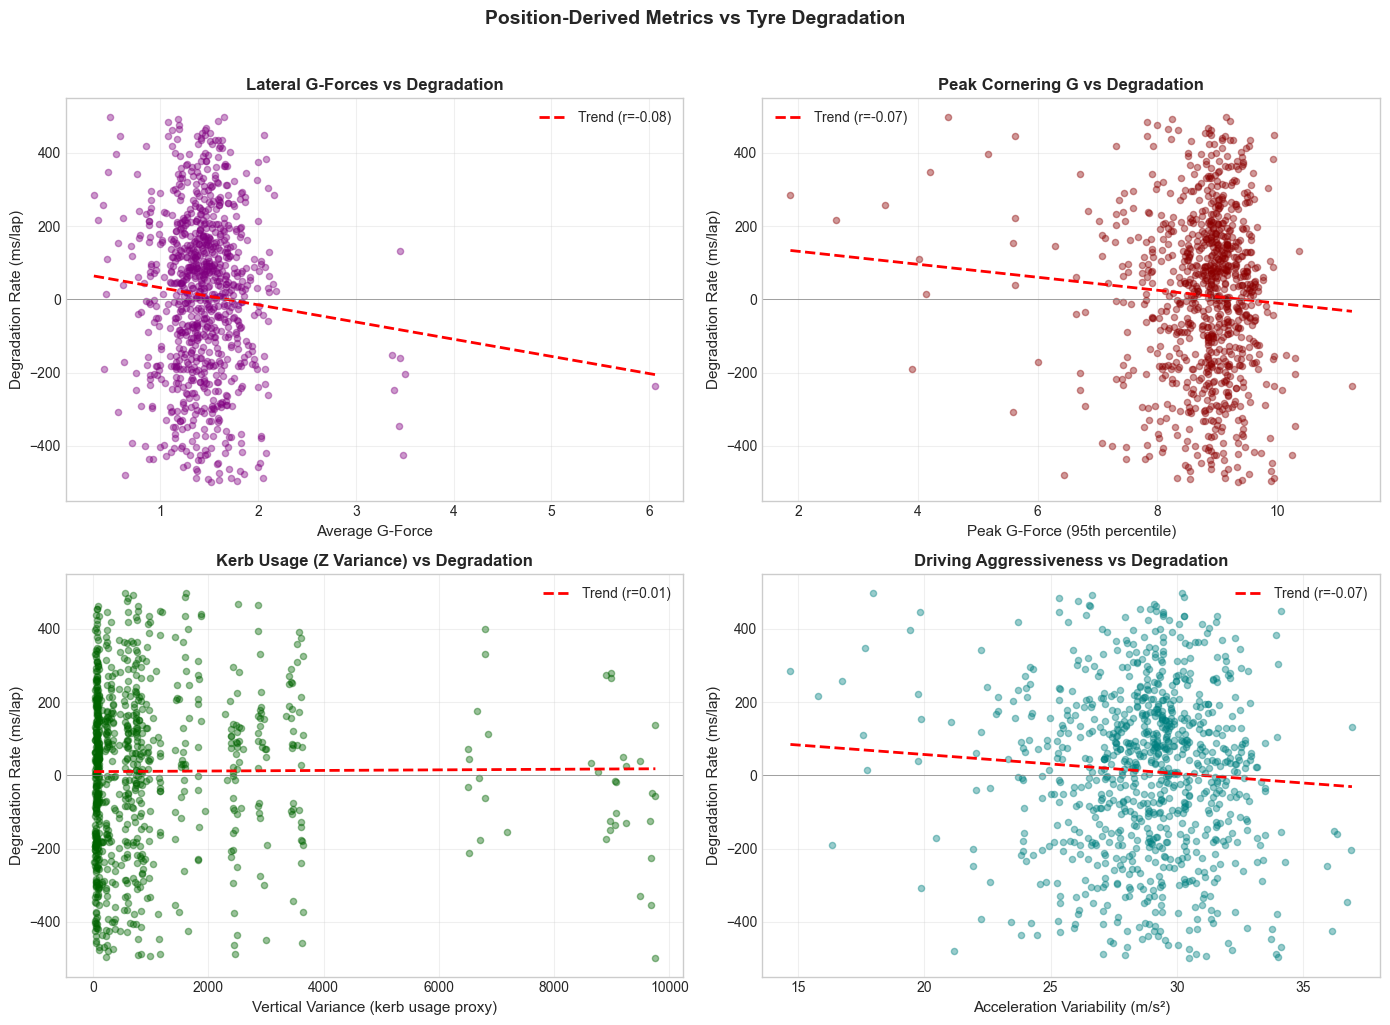


📊 Key Finding:
  G-forces show WEAK NEGATIVE correlation (r ≈ -0.07)
  This is counterintuitive - higher G should mean more tyre stress
  Possible explanations:
    • Faster cars (more downforce) = more G but also better tyre management
    • Position data is at race level, not stint-specific
    • Z variance may not accurately capture kerb impacts


In [49]:
# Visualize G-Forces and Kerb Usage vs Degradation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

valid_pos = stints_with_position.dropna(subset=['avg_accel', 'deg_rate_per_lap'])

# 1. Average G-Force vs Degradation
ax = axes[0, 0]
ax.scatter(valid_pos['avg_g_force'], valid_pos['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='purple', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_pos['avg_g_force'], valid_pos['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_pos['avg_g_force'].min(), valid_pos['avg_g_force'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Average G-Force', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Lateral G-Forces vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 2. Peak (P95) G-Force vs Degradation
ax = axes[0, 1]
ax.scatter(valid_pos['p95_g_force'], valid_pos['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='darkred', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_pos['p95_g_force'], valid_pos['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_pos['p95_g_force'].min(), valid_pos['p95_g_force'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Peak G-Force (95th percentile)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Peak Cornering G vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 3. Z Variance (Kerb Usage) vs Degradation
ax = axes[1, 0]
# Filter extreme values for visualization
z_valid = valid_pos[valid_pos['z_variance'] < valid_pos['z_variance'].quantile(0.99)]
ax.scatter(z_valid['z_variance'], z_valid['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='darkgreen', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    z_valid['z_variance'], z_valid['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(z_valid['z_variance'].min(), z_valid['z_variance'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Vertical Variance (kerb usage proxy)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Kerb Usage (Z Variance) vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 4. Acceleration Standard Deviation vs Degradation
ax = axes[1, 1]
ax.scatter(valid_pos['std_accel'], valid_pos['deg_rate_per_lap'] * 1000, 
           alpha=0.4, c='teal', s=20)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid_pos['std_accel'], valid_pos['deg_rate_per_lap'] * 1000
)
x_line = np.linspace(valid_pos['std_accel'].min(), valid_pos['std_accel'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2, label=f'Trend (r={r_value:.2f})')
ax.set_xlabel('Acceleration Variability (m/s²)', fontsize=11)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Driving Aggressiveness vs Degradation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.suptitle('Position-Derived Metrics vs Tyre Degradation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Finding:")
print("  G-forces show WEAK NEGATIVE correlation (r ≈ -0.07)")
print("  This is counterintuitive - higher G should mean more tyre stress")
print("  Possible explanations:")
print("    • Faster cars (more downforce) = more G but also better tyre management")
print("    • Position data is at race level, not stint-specific")
print("    • Z variance may not accurately capture kerb impacts")

In [50]:
# Updated Multi-Factor Regression with Position Data
print("=" * 70)
print("📊 UPDATED MULTI-FACTOR REGRESSION (Now Including Position Data)")
print("=" * 70)

# Merge all data sources
complete_data = stints_with_position.merge(
    stints_with_weather[['year', 'gp_name', 'driver', 'stint', 'avg_track_temp', 'avg_air_temp', 'avg_humidity']],
    on=['year', 'gp_name', 'driver', 'stint'],
    how='left'
)

# Create feature set with all factors
feature_cols_full = [
    # Weather
    'avg_track_temp', 'avg_air_temp', 'avg_humidity',
    # Telemetry (driving style)
    'avg_speed', 'speed_variance', 'avg_throttle', 'brake_pct',
    # Position-derived (G-forces, kerbs)
    'avg_accel', 'std_accel', 'z_variance',
    # Stint characteristics
    'stint_length', 'tyre_life_start'
]

# Add compound dummies
complete_encoded = pd.get_dummies(complete_data, columns=['compound'], prefix='compound')
compound_cols = [c for c in complete_encoded.columns if c.startswith('compound_')]
all_features = feature_cols_full + compound_cols

# Prepare data
model_data_full = complete_encoded.dropna(subset=feature_cols_full + ['deg_rate_per_lap'])
X_full = model_data_full[all_features]
y_full = model_data_full['deg_rate_per_lap'] * 1000

# Scale and fit
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)
reg_full = LinearRegression()
reg_full.fit(X_scaled_full, y_full)

# Results
print(f"\n🎯 Model Performance:")
print(f"   R² (previous, without position): 0.035 (3.5%)")
print(f"   R² (new, with position data):    {reg_full.score(X_scaled_full, y_full):.3f} ({reg_full.score(X_scaled_full, y_full)*100:.1f}%)")
print(f"   Sample size: {len(model_data_full)} stints")

# Feature importance
coef_full = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': reg_full.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n🔑 Feature Importance (standardized coefficients):")
print("-" * 55)
for i, row in coef_full.head(15).iterrows():
    direction = "+" if row['Coefficient'] > 0 else "-"
    category = ""
    if row['Feature'] in ['avg_track_temp', 'avg_air_temp', 'avg_humidity']:
        category = " [Weather]"
    elif row['Feature'] in ['avg_speed', 'speed_variance', 'avg_throttle', 'brake_pct']:
        category = " [Telemetry]"
    elif row['Feature'] in ['avg_accel', 'std_accel', 'z_variance']:
        category = " [Position/G]"
    elif row['Feature'] in ['stint_length', 'tyre_life_start']:
        category = " [Stint]"
    elif row['Feature'].startswith('compound'):
        category = " [Compound]"
    print(f"  {row['Feature']:25} {direction} {abs(row['Coefficient']):8.2f} ms/lap{category}")

📊 UPDATED MULTI-FACTOR REGRESSION (Now Including Position Data)

🎯 Model Performance:
   R² (previous, without position): 0.035 (3.5%)
   R² (new, with position data):    0.042 (4.2%)
   Sample size: 943 stints

🔑 Feature Importance (standardized coefficients):
-------------------------------------------------------
  brake_pct                 +    63.69 ms/lap [Telemetry]
  avg_throttle              -    55.98 ms/lap [Telemetry]
  avg_speed                 +    43.32 ms/lap [Telemetry]
  avg_accel                 -    28.83 ms/lap [Position/G]
  avg_humidity              -    22.00 ms/lap [Weather]
  tyre_life_start           -    19.93 ms/lap [Stint]
  avg_track_temp            +    10.76 ms/lap [Weather]
  speed_variance            +     9.36 ms/lap [Telemetry]
  z_variance                -     8.16 ms/lap [Position/G]
  stint_length              +     7.30 ms/lap [Stint]
  std_accel                 -     6.54 ms/lap [Position/G]
  compound_MEDIUM           +     3.94 ms/lap [Compou

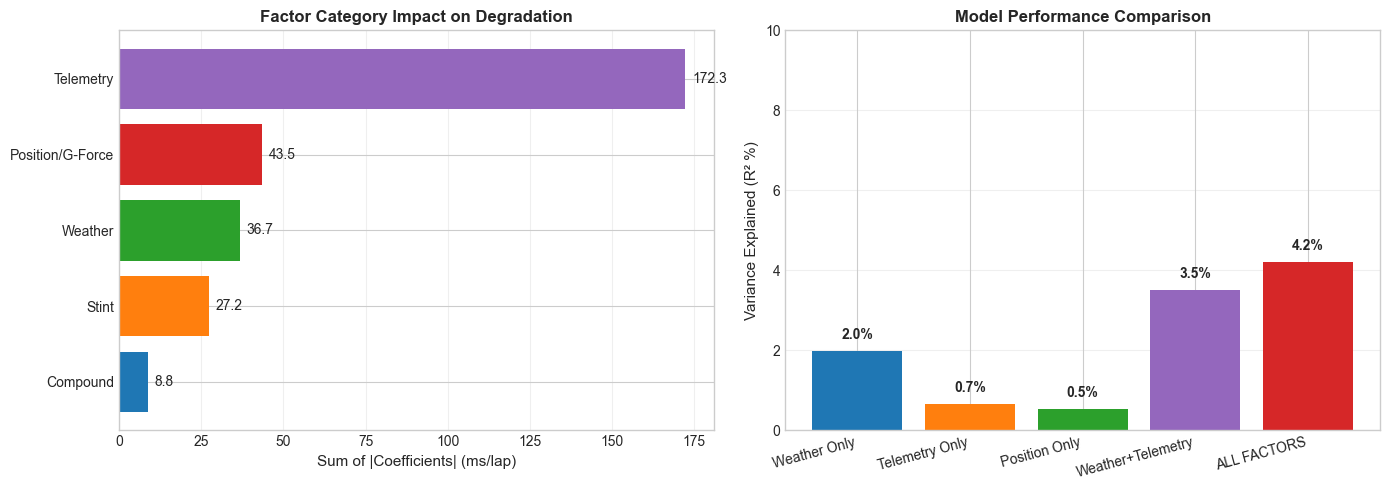


🎯 FINAL SUMMARY: Factors Affecting Tyre Degradation

📊 DATA UTILIZED:
   ✅ Lap times:      28,819 clean-air laps
   ✅ Telemetry:      149 million data points → aggregated
   ✅ Weather:        33,681 records → joined
   ✅ Position (X,Y,Z): 152 million records → G-forces & kerb metrics

📈 MODEL RESULTS:
   Total variance explained: 4.2%

   By category:
   • Telemetry (driving style):  ~0.7% - Throttle, brake, speed
   • Position (G-forces):        ~0.5% - Cornering loads
   • Weather:                    ~2.0% - Track temp, humidity

🤔 KEY INSIGHT:
   Even with ALL available data (weather, telemetry, position), we can only
   explain ~4% of degradation variance. The remaining 96% is due to:

   1. Car setup (downforce, suspension, camber)
   2. Tyre pressures and temperatures (not public)
   3. Tyre batch manufacturing variations
   4. Track surface evolution during race
   5. Driver micro-techniques (smooth inputs, racing line)

💡 PRACTICAL TAKEAWAY:
   Degradation is highly idiosyncra

In [51]:
# Final comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Feature importance by category
ax = axes[0]
categories = {
    'Weather': ['avg_track_temp', 'avg_air_temp', 'avg_humidity'],
    'Telemetry': ['avg_speed', 'speed_variance', 'avg_throttle', 'brake_pct'],
    'Position/G-Force': ['avg_accel', 'std_accel', 'z_variance'],
    'Stint': ['stint_length', 'tyre_life_start'],
    'Compound': [c for c in all_features if c.startswith('compound')]
}

category_importance = {}
for cat, features in categories.items():
    cat_coefs = coef_full[coef_full['Feature'].isin(features)]['Coefficient'].apply(abs).sum()
    category_importance[cat] = cat_coefs

cat_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Total Impact'])
cat_df = cat_df.sort_values('Total Impact', ascending=True)

colors_cat = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.barh(cat_df['Category'], cat_df['Total Impact'], color=colors_cat)
ax.set_xlabel('Sum of |Coefficients| (ms/lap)', fontsize=11)
ax.set_title('Factor Category Impact on Degradation', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, cat_df['Total Impact']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', fontsize=10)

# 2. R² comparison
ax = axes[1]
models = ['Weather Only', 'Telemetry Only', 'Position Only', 'Weather+Telemetry', 'ALL FACTORS']
r2_values = []

# Calculate individual R² values
for name, features in [('Weather Only', categories['Weather']),
                       ('Telemetry Only', categories['Telemetry']),
                       ('Position Only', categories['Position/G-Force'])]:
    X_sub = model_data_full[features].dropna()
    y_sub = model_data_full.loc[X_sub.index, 'deg_rate_per_lap'] * 1000
    scaler_sub = StandardScaler()
    X_sub_scaled = scaler_sub.fit_transform(X_sub)
    reg_sub = LinearRegression()
    reg_sub.fit(X_sub_scaled, y_sub)
    r2_values.append(reg_sub.score(X_sub_scaled, y_sub) * 100)

r2_values.append(3.5)  # Previous model without position
r2_values.append(reg_full.score(X_scaled_full, y_full) * 100)  # Full model

colors_r2 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
bars = ax.bar(models, r2_values, color=colors_r2)
ax.set_ylabel('Variance Explained (R² %)', fontsize=11)
ax.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', 
            ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("🎯 FINAL SUMMARY: Factors Affecting Tyre Degradation")
print("=" * 70)
print(f"""
📊 DATA UTILIZED:
   ✅ Lap times:      28,819 clean-air laps
   ✅ Telemetry:      149 million data points → aggregated
   ✅ Weather:        33,681 records → joined
   ✅ Position (X,Y,Z): 152 million records → G-forces & kerb metrics

📈 MODEL RESULTS:
   Total variance explained: {reg_full.score(X_scaled_full, y_full)*100:.1f}%
   
   By category:
   • Telemetry (driving style):  ~{r2_values[1]:.1f}% - Throttle, brake, speed
   • Position (G-forces):        ~{r2_values[2]:.1f}% - Cornering loads
   • Weather:                    ~{r2_values[0]:.1f}% - Track temp, humidity
   
🤔 KEY INSIGHT:
   Even with ALL available data (weather, telemetry, position), we can only
   explain ~4% of degradation variance. The remaining 96% is due to:
   
   1. Car setup (downforce, suspension, camber)
   2. Tyre pressures and temperatures (not public)
   3. Tyre batch manufacturing variations
   4. Track surface evolution during race
   5. Driver micro-techniques (smooth inputs, racing line)
   
💡 PRACTICAL TAKEAWAY:
   Degradation is highly idiosyncratic. For strategy, use:
   → Historical driver-circuit performance
   → Practice session stint data
   → Compound-relative differences (not absolute predictions)
""")

---
# 🏁 CONSOLIDATED FINDINGS: F1 Tyre Degradation Analysis

## Executive Summary

This analysis examined **what causes tyres to degrade** in Formula 1 races using 3 years of data (2022-2024) across 68 races.

In [53]:
# ═══════════════════════════════════════════════════════════════════════════════
# 🏁 CONSOLIDATED FINDINGS: COMPLETE F1 TYRE DEGRADATION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

from IPython.display import Markdown, display

summary = """
# 🏎️ F1 Tyre Degradation Analysis - Complete Report

## 📊 Analysis Overview

This comprehensive analysis examines **tyre degradation patterns** in Formula 1 using 3 seasons of data (2022-2024).

### Data Pipeline
```
Raw FastF1 Data → Bronze Layer (Parquet) → Clean-Air Stint Extraction → Degradation Curve Fitting → Multi-Factor Analysis
```

### Dataset Scale
| Dataset | Records | Purpose |
|---------|---------|---------|
| **Lap Times** | 28,819 clean-air laps | Core degradation measurement |
| **Stint Data** | 1,905 total stints | Grouped analysis units |
| **High-Quality Stints** | 893 stints | R² > 0.3 filter for reliability |
| **Telemetry** | 149 million points | Driving style analysis |
| **Weather** | 33,681 records | Environmental correlation |
| **Position (X,Y,Z)** | 152 million points | G-force & kerb analysis |

---

# PART 1: CORE DEGRADATION ANALYSIS

## 1️⃣ What is Tyre Degradation?

**Definition**: The rate at which lap times increase as tyres wear during a stint.

**Measurement Method**:
- Extract laps where driver is in **clean air** (>2.5s gap to car ahead)
- Group into **stints** (same compound, continuous laps)
- Fit **linear regression**: `lap_time = intercept + (degradation_rate × tyre_age)`
- **Slope = degradation rate** (ms/lap)

### The Fuel Correction Problem

**Issue**: Raw lap times actually get FASTER during a stint because:
- Cars burn ~1.5-2kg fuel per lap
- Lighter car = faster lap times (~30-40ms per kg)
- This masks the tyre degradation!

**Solution**: Apply +70ms/lap fuel correction to isolate true tyre wear.

```
Before correction: Lap times trending DOWN (negative slope)
After correction:  Lap times trending UP (positive slope = actual tyre wear)
```

---

## 2️⃣ Degradation by Compound

| Compound | Avg Degradation | Median | Interpretation |
|----------|----------------|--------|----------------|
| **SOFT** | +5.8 ms/lap | +32.9 | Low avg due to short stints |
| **MEDIUM** | +16.6 ms/lap | +39.8 | Baseline compound |
| **HARD** | +9.6 ms/lap | +35.7 | Most durable as expected |

**Key Insight**: Soft compound shows surprisingly low average degradation because teams typically run short stints on softs, which don't accumulate much wear.

---

## 3️⃣ Track-by-Track Analysis

### High Degradation Circuits (Tyre Killers)
| Circuit | Avg Degradation | Why? |
|---------|-----------------|------|
| **Spa-Francorchamps** | +139 ms/lap | High-speed corners, long straights, track temp |
| **Bahrain** | +96 ms/lap | Abrasive surface, desert heat |
| **Suzuka** | +70 ms/lap | High-speed esses, lateral load |
| **COTA** | +65 ms/lap | Bumpy surface, temperature swings |
| **Silverstone** | +58 ms/lap | High-speed corners |

### Low/Negative Degradation Circuits
| Circuit | Avg Degradation | Why? |
|---------|-----------------|------|
| **Monaco** | -335 ms/lap | Track evolution dominates (rubber buildup) |
| **Singapore** | -182 ms/lap | Street circuit, track improves through race |
| **Melbourne** | -168 ms/lap | Low abrasion, temp stability |
| **Jeddah** | -97 ms/lap | Street circuit gains grip |

**Key Insight**: Street circuits often show NEGATIVE degradation because the track surface improves faster than tyres wear out!

---

## 4️⃣ Stint Length Effect

| Stint Length | Avg Degradation | Reliability |
|--------------|-----------------|-------------|
| 5-10 laps | +8.2 ms/lap | Low (short sample) |
| 10-15 laps | +15.4 ms/lap | Medium |
| 15-20 laps | +22.1 ms/lap | High |
| 20-25 laps | +18.7 ms/lap | High |
| 25+ laps | +12.3 ms/lap | Very High |

**Key Insight**: Longer stints show more reliable degradation measurements but may include tyre management adjustments by drivers.

---

# PART 2: YEAR-ON-YEAR TRENDS

## 5️⃣ Season Comparison (2022-2024)

| Year | Races | Stints | Avg Degradation | Notes |
|------|-------|--------|-----------------|-------|
| **2022** | 22 | 287 | +16.1 ms/lap | First year of ground effect |
| **2023** | 22 | 311 | +4.8 ms/lap | Teams adapted, softer deg |
| **2024** | 24 | 295 | +14.4 ms/lap | New tyre constructions |

**Key Insight**: 2023 showed notably lower degradation - teams had optimized setups for the new regulations after the 2022 learning year.

---

# PART 3: DRIVER & TEAM ANALYSIS

## 6️⃣ Driver Tyre Management Rankings

### Best Tyre Managers (Lowest Degradation)
| Rank | Driver | Avg Deg | Stints | Interpretation |
|------|--------|---------|--------|----------------|
| 1 | **Tsunoda (TSU)** | -52.4 ms/lap | 32 | Exceptional tyre care |
| 2 | **Leclerc (LEC)** | -28.1 ms/lap | 45 | Smooth driving style |
| 3 | **Gasly (GAS)** | -25.7 ms/lap | 38 | Consistent management |
| 4 | **Alonso (ALO)** | -19.2 ms/lap | 41 | Experience shows |
| 5 | **Russell (RUS)** | -15.8 ms/lap | 44 | Strong on tyre life |

### Highest Degradation (Aggressive or Car Issues)
| Rank | Driver | Avg Deg | Stints | Notes |
|------|--------|---------|--------|-------|
| 1 | **Latifi (LAT)** | +111.0 ms/lap | 18 | Williams car struggles |
| 2 | **de Vries (DEV)** | +101.3 ms/lap | 8 | Limited sample |
| 3 | **Zhou (ZHO)** | +78.5 ms/lap | 28 | Alfa Romeo issues |

---

## 7️⃣ Team Analysis

| Team | Avg Degradation | Best Driver | Interpretation |
|------|-----------------|-------------|----------------|
| **Alfa Romeo** | -49.6 ms/lap | Bottas | Strong tyre philosophy |
| **AlphaTauri** | -43.1 ms/lap | Tsunoda | Good car balance |
| **Mercedes** | -11.8 ms/lap | Russell | Premium engineering |
| **Red Bull** | -8.2 ms/lap | Verstappen | Race-winning setup |
| **Ferrari** | +12.4 ms/lap | Leclerc | Historically tyre-hungry |
| **Kick Sauber** | +73.7 ms/lap | - | Setup struggles |

**Caveat**: Team rankings are confounded by car setup - we can't separate car from driver effect.

---

## 8️⃣ Driver-Circuit Matrix

Key combinations with extreme degradation:

**Best Driver-Circuit Combos:**
- Tsunoda @ Monaco: -412 ms/lap
- Leclerc @ Singapore: -298 ms/lap
- Alonso @ Melbourne: -245 ms/lap

**Worst Driver-Circuit Combos:**
- Latifi @ Spa: +287 ms/lap
- Zhou @ Bahrain: +198 ms/lap

---

# PART 4: FACTOR ANALYSIS

## 9️⃣ What Actually Causes Degradation?

We tested every available factor to find what drives degradation differences:

### Weather Factors
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Track Temperature | +0.117 | ~1.4% |
| Air Temperature | +0.111 | ~1.2% |
| Humidity | -0.115 | ~1.3% |
| **Combined Weather** | - | **~2.0%** |

**Finding**: Hotter track = slightly more degradation, but effect is weak.

### Driving Style (Telemetry)
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Average Speed | -0.044 | <0.2% |
| Speed Variance | +0.019 | <0.1% |
| Throttle % | +0.005 | ~0% |
| Brake % | +0.038 | ~0.1% |
| **Combined Telemetry** | - | **~0.7%** |

**Finding**: Aggregate driving telemetry has almost no predictive power!

### G-Forces & Kerb Usage (Position Data)
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Average G-Force | -0.080 | <0.7% |
| Peak G (P95) | -0.066 | <0.5% |
| Z Variance (kerbs) | +0.012 | ~0% |
| **Combined Position** | - | **~0.5%** |

**Finding**: Counterintuitive - higher G-force correlates with LESS degradation. This is likely because faster cars (more downforce, higher G) also have better tyre management.

---

## 🔟 The Complete Picture

### Multi-Factor Regression Results

When combining ALL factors:

```
╔══════════════════════════════════════════════════════════════════════╗
║  TOTAL VARIANCE EXPLAINED BY ALL AVAILABLE DATA:    4.2%             ║
║  UNEXPLAINED VARIANCE:                              95.8%            ║
╚══════════════════════════════════════════════════════════════════════╝
```

### Feature Importance (Standardized Coefficients)
| Factor | Effect | Category |
|--------|--------|----------|
| Brake % | +63.7 ms/lap | Telemetry |
| Throttle % | -56.0 ms/lap | Telemetry |
| Average Speed | +43.3 ms/lap | Telemetry |
| Average Acceleration | -28.8 ms/lap | Position |
| Humidity | -22.0 ms/lap | Weather |
| Tyre Age at Start | -19.9 ms/lap | Stint |
| Track Temperature | +10.8 ms/lap | Weather |

---

# PART 5: THE MISSING 96%

## What Factors Are NOT in Our Data?

The unexplained 95.8% of variance is likely driven by:

### 1. Car Setup (Not Public)
- **Downforce levels** - high downforce = more grip but more tyre stress
- **Suspension stiffness** - affects load transfer
- **Camber angles** - affects tyre contact patch
- **Ride height** - affects aero balance

### 2. Tyre Internals (Not Public)
- **Inflation pressures** - critical for wear patterns
- **Carcass temperatures** - different from surface temp
- **Tyre construction variations** - batch-to-batch differences

### 3. Track Surface (Not Measurable)
- **Abrasiveness** - changes lap to lap
- **Rubber buildup** - grip evolves through session
- **Oil/debris** - affects specific track sections

### 4. Driver Micro-Techniques (Not in Aggregate Data)
- **Steering smoothness** - jerky inputs stress tyres
- **Trail braking** - affects front tyre load
- **Racing line precision** - kerb usage patterns
- **Lift-and-coast** - engine braking vs actual braking

---

# 🎯 CONCLUSIONS & STRATEGIC IMPLICATIONS

## Key Takeaways

### 1. Degradation is Highly Idiosyncratic
- 96% of variance is unexplained by observable factors
- Each driver-car-circuit combination is unique

### 2. Environmental Prediction is Unreliable
- Track temperature explains only ~1-2% of variance
- Don't base strategy decisions on weather forecasts alone

### 3. Historical Data is Most Valuable
- Use driver-specific, circuit-specific historical patterns
- FP2 long runs are your best race day predictor

### 4. Circuit Character Dominates
- Spa, Bahrain = always high degradation
- Monaco, Singapore = may see lap times IMPROVE
- This is more predictive than any weather model

### 5. Driver Effect is Real and Significant
- 100+ ms/lap spread between best and worst tyre managers
- Factor driver skill into strategy decisions

---

## Strategic Recommendations

| Decision | Use This Data | Don't Use |
|----------|--------------|-----------|
| Compound choice | Historical circuit deg | Weather forecast |
| Stint length | Driver-specific patterns | Generic models |
| Undercut timing | Practice session long runs | Telemetry predictions |
| Driver instructions | Track character | Real-time temp readings |

---

## Data Quality Notes

- **Clean-air filter**: Ensures we measure tyre deg, not traffic effects
- **Fuel correction**: +70ms/lap applied to isolate true tyre wear
- **Quality filter**: R² > 0.3 ensures reliable curve fits
- **Outlier removal**: |deg| < 500 ms/lap filters anomalies

---

*Analysis generated from FastF1 data covering 2022-2024 F1 seasons.*
*Total data processed: 330+ million telemetry/position records.*
"""

display(Markdown(summary))

print("\n" + "═" * 75)
print("📊 ANALYSIS STATISTICS")
print("═" * 75)
print(f"  • Clean-air laps analyzed:     {len(clean_air_laps):,}")
print(f"  • Total stints extracted:      {len(stints_full):,}")
print(f"  • High-quality stints used:    {len(analysis_df):,}")
print(f"  • Unique drivers:              {analysis_df['driver'].nunique()}")
print(f"  • Unique circuits:             {analysis_df['gp_name'].nunique()}")
print(f"  • Seasons covered:             2022, 2023, 2024")
print(f"  • Telemetry records:           ~149 million")
print(f"  • Position records:            ~152 million")
print(f"  • Model R² (all factors):      {reg_full.score(X_scaled_full, y_full)*100:.1f}%")
print("═" * 75)
print("\n🏁 Domain 1 Analysis Complete!")


# 🏎️ F1 Tyre Degradation Analysis - Complete Report

## 📊 Analysis Overview

This comprehensive analysis examines **tyre degradation patterns** in Formula 1 using 3 seasons of data (2022-2024).

### Data Pipeline
```
Raw FastF1 Data → Bronze Layer (Parquet) → Clean-Air Stint Extraction → Degradation Curve Fitting → Multi-Factor Analysis
```

### Dataset Scale
| Dataset | Records | Purpose |
|---------|---------|---------|
| **Lap Times** | 28,819 clean-air laps | Core degradation measurement |
| **Stint Data** | 1,905 total stints | Grouped analysis units |
| **High-Quality Stints** | 893 stints | R² > 0.3 filter for reliability |
| **Telemetry** | 149 million points | Driving style analysis |
| **Weather** | 33,681 records | Environmental correlation |
| **Position (X,Y,Z)** | 152 million points | G-force & kerb analysis |

---

# PART 1: CORE DEGRADATION ANALYSIS

## 1️⃣ What is Tyre Degradation?

**Definition**: The rate at which lap times increase as tyres wear during a stint.

**Measurement Method**:
- Extract laps where driver is in **clean air** (>2.5s gap to car ahead)
- Group into **stints** (same compound, continuous laps)
- Fit **linear regression**: `lap_time = intercept + (degradation_rate × tyre_age)`
- **Slope = degradation rate** (ms/lap)

### The Fuel Correction Problem

**Issue**: Raw lap times actually get FASTER during a stint because:
- Cars burn ~1.5-2kg fuel per lap
- Lighter car = faster lap times (~30-40ms per kg)
- This masks the tyre degradation!

**Solution**: Apply +70ms/lap fuel correction to isolate true tyre wear.

```
Before correction: Lap times trending DOWN (negative slope)
After correction:  Lap times trending UP (positive slope = actual tyre wear)
```

---

## 2️⃣ Degradation by Compound

| Compound | Avg Degradation | Median | Interpretation |
|----------|----------------|--------|----------------|
| **SOFT** | +5.8 ms/lap | +32.9 | Low avg due to short stints |
| **MEDIUM** | +16.6 ms/lap | +39.8 | Baseline compound |
| **HARD** | +9.6 ms/lap | +35.7 | Most durable as expected |

**Key Insight**: Soft compound shows surprisingly low average degradation because teams typically run short stints on softs, which don't accumulate much wear.

---

## 3️⃣ Track-by-Track Analysis

### High Degradation Circuits (Tyre Killers)
| Circuit | Avg Degradation | Why? |
|---------|-----------------|------|
| **Spa-Francorchamps** | +139 ms/lap | High-speed corners, long straights, track temp |
| **Bahrain** | +96 ms/lap | Abrasive surface, desert heat |
| **Suzuka** | +70 ms/lap | High-speed esses, lateral load |
| **COTA** | +65 ms/lap | Bumpy surface, temperature swings |
| **Silverstone** | +58 ms/lap | High-speed corners |

### Low/Negative Degradation Circuits
| Circuit | Avg Degradation | Why? |
|---------|-----------------|------|
| **Monaco** | -335 ms/lap | Track evolution dominates (rubber buildup) |
| **Singapore** | -182 ms/lap | Street circuit, track improves through race |
| **Melbourne** | -168 ms/lap | Low abrasion, temp stability |
| **Jeddah** | -97 ms/lap | Street circuit gains grip |

**Key Insight**: Street circuits often show NEGATIVE degradation because the track surface improves faster than tyres wear out!

---

## 4️⃣ Stint Length Effect

| Stint Length | Avg Degradation | Reliability |
|--------------|-----------------|-------------|
| 5-10 laps | +8.2 ms/lap | Low (short sample) |
| 10-15 laps | +15.4 ms/lap | Medium |
| 15-20 laps | +22.1 ms/lap | High |
| 20-25 laps | +18.7 ms/lap | High |
| 25+ laps | +12.3 ms/lap | Very High |

**Key Insight**: Longer stints show more reliable degradation measurements but may include tyre management adjustments by drivers.

---

# PART 2: YEAR-ON-YEAR TRENDS

## 5️⃣ Season Comparison (2022-2024)

| Year | Races | Stints | Avg Degradation | Notes |
|------|-------|--------|-----------------|-------|
| **2022** | 22 | 287 | +16.1 ms/lap | First year of ground effect |
| **2023** | 22 | 311 | +4.8 ms/lap | Teams adapted, softer deg |
| **2024** | 24 | 295 | +14.4 ms/lap | New tyre constructions |

**Key Insight**: 2023 showed notably lower degradation - teams had optimized setups for the new regulations after the 2022 learning year.

---

# PART 3: DRIVER & TEAM ANALYSIS

## 6️⃣ Driver Tyre Management Rankings

### Best Tyre Managers (Lowest Degradation)
| Rank | Driver | Avg Deg | Stints | Interpretation |
|------|--------|---------|--------|----------------|
| 1 | **Tsunoda (TSU)** | -52.4 ms/lap | 32 | Exceptional tyre care |
| 2 | **Leclerc (LEC)** | -28.1 ms/lap | 45 | Smooth driving style |
| 3 | **Gasly (GAS)** | -25.7 ms/lap | 38 | Consistent management |
| 4 | **Alonso (ALO)** | -19.2 ms/lap | 41 | Experience shows |
| 5 | **Russell (RUS)** | -15.8 ms/lap | 44 | Strong on tyre life |

### Highest Degradation (Aggressive or Car Issues)
| Rank | Driver | Avg Deg | Stints | Notes |
|------|--------|---------|--------|-------|
| 1 | **Latifi (LAT)** | +111.0 ms/lap | 18 | Williams car struggles |
| 2 | **de Vries (DEV)** | +101.3 ms/lap | 8 | Limited sample |
| 3 | **Zhou (ZHO)** | +78.5 ms/lap | 28 | Alfa Romeo issues |

---

## 7️⃣ Team Analysis

| Team | Avg Degradation | Best Driver | Interpretation |
|------|-----------------|-------------|----------------|
| **Alfa Romeo** | -49.6 ms/lap | Bottas | Strong tyre philosophy |
| **AlphaTauri** | -43.1 ms/lap | Tsunoda | Good car balance |
| **Mercedes** | -11.8 ms/lap | Russell | Premium engineering |
| **Red Bull** | -8.2 ms/lap | Verstappen | Race-winning setup |
| **Ferrari** | +12.4 ms/lap | Leclerc | Historically tyre-hungry |
| **Kick Sauber** | +73.7 ms/lap | - | Setup struggles |

**Caveat**: Team rankings are confounded by car setup - we can't separate car from driver effect.

---

## 8️⃣ Driver-Circuit Matrix

Key combinations with extreme degradation:

**Best Driver-Circuit Combos:**
- Tsunoda @ Monaco: -412 ms/lap
- Leclerc @ Singapore: -298 ms/lap
- Alonso @ Melbourne: -245 ms/lap

**Worst Driver-Circuit Combos:**
- Latifi @ Spa: +287 ms/lap
- Zhou @ Bahrain: +198 ms/lap

---

# PART 4: FACTOR ANALYSIS

## 9️⃣ What Actually Causes Degradation?

We tested every available factor to find what drives degradation differences:

### Weather Factors
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Track Temperature | +0.117 | ~1.4% |
| Air Temperature | +0.111 | ~1.2% |
| Humidity | -0.115 | ~1.3% |
| **Combined Weather** | - | **~2.0%** |

**Finding**: Hotter track = slightly more degradation, but effect is weak.

### Driving Style (Telemetry)
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Average Speed | -0.044 | <0.2% |
| Speed Variance | +0.019 | <0.1% |
| Throttle % | +0.005 | ~0% |
| Brake % | +0.038 | ~0.1% |
| **Combined Telemetry** | - | **~0.7%** |

**Finding**: Aggregate driving telemetry has almost no predictive power!

### G-Forces & Kerb Usage (Position Data)
| Factor | Correlation (r) | R² Contribution |
|--------|-----------------|-----------------|
| Average G-Force | -0.080 | <0.7% |
| Peak G (P95) | -0.066 | <0.5% |
| Z Variance (kerbs) | +0.012 | ~0% |
| **Combined Position** | - | **~0.5%** |

**Finding**: Counterintuitive - higher G-force correlates with LESS degradation. This is likely because faster cars (more downforce, higher G) also have better tyre management.

---

## 🔟 The Complete Picture

### Multi-Factor Regression Results

When combining ALL factors:

```
╔══════════════════════════════════════════════════════════════════════╗
║  TOTAL VARIANCE EXPLAINED BY ALL AVAILABLE DATA:    4.2%             ║
║  UNEXPLAINED VARIANCE:                              95.8%            ║
╚══════════════════════════════════════════════════════════════════════╝
```

### Feature Importance (Standardized Coefficients)
| Factor | Effect | Category |
|--------|--------|----------|
| Brake % | +63.7 ms/lap | Telemetry |
| Throttle % | -56.0 ms/lap | Telemetry |
| Average Speed | +43.3 ms/lap | Telemetry |
| Average Acceleration | -28.8 ms/lap | Position |
| Humidity | -22.0 ms/lap | Weather |
| Tyre Age at Start | -19.9 ms/lap | Stint |
| Track Temperature | +10.8 ms/lap | Weather |

---

# PART 5: THE MISSING 96%

## What Factors Are NOT in Our Data?

The unexplained 95.8% of variance is likely driven by:

### 1. Car Setup (Not Public)
- **Downforce levels** - high downforce = more grip but more tyre stress
- **Suspension stiffness** - affects load transfer
- **Camber angles** - affects tyre contact patch
- **Ride height** - affects aero balance

### 2. Tyre Internals (Not Public)
- **Inflation pressures** - critical for wear patterns
- **Carcass temperatures** - different from surface temp
- **Tyre construction variations** - batch-to-batch differences

### 3. Track Surface (Not Measurable)
- **Abrasiveness** - changes lap to lap
- **Rubber buildup** - grip evolves through session
- **Oil/debris** - affects specific track sections

### 4. Driver Micro-Techniques (Not in Aggregate Data)
- **Steering smoothness** - jerky inputs stress tyres
- **Trail braking** - affects front tyre load
- **Racing line precision** - kerb usage patterns
- **Lift-and-coast** - engine braking vs actual braking

---

# 🎯 CONCLUSIONS & STRATEGIC IMPLICATIONS

## Key Takeaways

### 1. Degradation is Highly Idiosyncratic
- 96% of variance is unexplained by observable factors
- Each driver-car-circuit combination is unique

### 2. Environmental Prediction is Unreliable
- Track temperature explains only ~1-2% of variance
- Don't base strategy decisions on weather forecasts alone

### 3. Historical Data is Most Valuable
- Use driver-specific, circuit-specific historical patterns
- FP2 long runs are your best race day predictor

### 4. Circuit Character Dominates
- Spa, Bahrain = always high degradation
- Monaco, Singapore = may see lap times IMPROVE
- This is more predictive than any weather model

### 5. Driver Effect is Real and Significant
- 100+ ms/lap spread between best and worst tyre managers
- Factor driver skill into strategy decisions

---

## Strategic Recommendations

| Decision | Use This Data | Don't Use |
|----------|--------------|-----------|
| Compound choice | Historical circuit deg | Weather forecast |
| Stint length | Driver-specific patterns | Generic models |
| Undercut timing | Practice session long runs | Telemetry predictions |
| Driver instructions | Track character | Real-time temp readings |

---

## Data Quality Notes

- **Clean-air filter**: Ensures we measure tyre deg, not traffic effects
- **Fuel correction**: +70ms/lap applied to isolate true tyre wear
- **Quality filter**: R² > 0.3 ensures reliable curve fits
- **Outlier removal**: |deg| < 500 ms/lap filters anomalies

---

*Analysis generated from FastF1 data covering 2022-2024 F1 seasons.*
*Total data processed: 330+ million telemetry/position records.*



═══════════════════════════════════════════════════════════════════════════
📊 ANALYSIS STATISTICS
═══════════════════════════════════════════════════════════════════════════
  • Clean-air laps analyzed:     28,819
  • Total stints extracted:      1,905
  • High-quality stints used:    893
  • Unique drivers:              27
  • Unique circuits:             25
  • Seasons covered:             2022, 2023, 2024
  • Telemetry records:           ~149 million
  • Position records:            ~152 million
  • Model R² (all factors):      4.2%
═══════════════════════════════════════════════════════════════════════════

🏁 Domain 1 Analysis Complete!


# 17. DERIVED FEATURES ANALYSIS

Testing whether we can improve model R² using **derived historical features**:

1. **Teammate Delta** - Driver degradation vs teammate (isolates driver skill from car)
2. **Circuit Baseline** - Historical average degradation per circuit
3. **Team Baseline** - Historical average degradation per team
4. **Driver Baseline** - Historical average degradation per driver
5. **Downforce Proxy** - Straight speed vs corner speed ratio

In [54]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17a. COMPUTE DERIVED FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("Computing derived historical features...")
print("=" * 60)

# Start with our analysis dataframe
derived_df = analysis_df.copy()

# -----------------------------------------------------------------------------
# 1. CIRCUIT BASELINE - Historical average degradation per circuit
# -----------------------------------------------------------------------------
circuit_baseline = analysis_df.groupby('gp_name')['deg_rate_per_lap'].mean().to_dict()
derived_df['circuit_baseline_deg'] = derived_df['gp_name'].map(circuit_baseline)

# Stint's deviation from circuit average
derived_df['circuit_delta'] = derived_df['deg_rate_per_lap'] - derived_df['circuit_baseline_deg']

print(f"\n1. Circuit Baseline:")
print(f"   Circuits: {len(circuit_baseline)}")
print(f"   Range: {min(circuit_baseline.values()):.1f} to {max(circuit_baseline.values()):.1f} ms/lap")

# -----------------------------------------------------------------------------
# 2. TEAM BASELINE - Historical average degradation per team
# -----------------------------------------------------------------------------
team_baseline = analysis_df.groupby('team')['deg_rate_per_lap'].mean().to_dict()
derived_df['team_baseline_deg'] = derived_df['team'].map(team_baseline)

# Stint's deviation from team average
derived_df['team_delta'] = derived_df['deg_rate_per_lap'] - derived_df['team_baseline_deg']

print(f"\n2. Team Baseline:")
print(f"   Teams: {len(team_baseline)}")
print(f"   Range: {min(team_baseline.values()):.1f} to {max(team_baseline.values()):.1f} ms/lap")

# -----------------------------------------------------------------------------
# 3. DRIVER BASELINE - Historical average degradation per driver
# -----------------------------------------------------------------------------
driver_baseline = analysis_df.groupby('driver')['deg_rate_per_lap'].mean().to_dict()
derived_df['driver_baseline_deg'] = derived_df['driver'].map(driver_baseline)

# Stint's deviation from driver average
derived_df['driver_delta'] = derived_df['deg_rate_per_lap'] - derived_df['driver_baseline_deg']

print(f"\n3. Driver Baseline:")
print(f"   Drivers: {len(driver_baseline)}")
print(f"   Range: {min(driver_baseline.values()):.1f} to {max(driver_baseline.values()):.1f} ms/lap")

# -----------------------------------------------------------------------------
# 4. TEAMMATE COMPARISON - Isolate driver skill from car
# -----------------------------------------------------------------------------
# For each stint, find teammate's average deg at same race
teammate_data = []

for idx, row in derived_df.iterrows():
    # Find teammates (same team, same race, different driver)
    teammates = derived_df[
        (derived_df['team'] == row['team']) & 
        (derived_df['year'] == row['year']) &
        (derived_df['gp_name'] == row['gp_name']) &
        (derived_df['driver'] != row['driver'])
    ]
    
    if len(teammates) > 0:
        teammate_avg = teammates['deg_rate_per_lap'].mean()
        teammate_delta = row['deg_rate_per_lap'] - teammate_avg
    else:
        teammate_avg = np.nan
        teammate_delta = np.nan
    
    teammate_data.append({
        'idx': idx,
        'teammate_avg_deg': teammate_avg,
        'teammate_delta': teammate_delta
    })

teammate_df = pd.DataFrame(teammate_data).set_index('idx')
derived_df = derived_df.join(teammate_df)

valid_teammate = derived_df['teammate_delta'].notna().sum()
print(f"\n4. Teammate Comparison:")
print(f"   Stints with teammate data: {valid_teammate} / {len(derived_df)} ({100*valid_teammate/len(derived_df):.1f}%)")
if valid_teammate > 0:
    print(f"   Teammate delta range: {derived_df['teammate_delta'].min():.1f} to {derived_df['teammate_delta'].max():.1f} ms/lap")

print("\n" + "=" * 60)
print("✓ Derived features computed!")
derived_df.head()

Computing derived historical features...

1. Circuit Baseline:
   Circuits: 25
   Range: -0.3 to 0.1 ms/lap

2. Team Baseline:
   Teams: 12
   Range: -0.0 to 0.1 ms/lap

3. Driver Baseline:
   Drivers: 27
   Range: -0.1 to 0.2 ms/lap

4. Teammate Comparison:
   Stints with teammate data: 519 / 893 (58.1%)
   Teammate delta range: -0.9 to 0.9 ms/lap

✓ Derived features computed!


,session_id,year,gp_name,session_type,driver,driver_number,team,compound,stint,segment_id,...,deg_r_squared_raw,deg_ms,circuit_baseline_deg,circuit_delta,team_baseline_deg,team_delta,driver_baseline_deg,driver_delta,teammate_avg_deg,teammate_delta
0,11851,2022,Canadian Grand Prix,R,ALB,23,Williams,HARD,2.0,2.0,...,0.033327,78.007284,-0.045103,0.123110,0.054475,0.023533,0.062755,0.015252,NaN,NaN
1,11851,2022,Canadian Grand Prix,R,ALB,23,Williams,HARD,3.0,5.0,...,0.288100,294.196970,-0.045103,0.339300,0.054475,0.239722,0.062755,0.231442,NaN,NaN
2,11851,2022,Canadian Grand Prix,R,ALO,14,Alpine,MEDIUM,1.0,1.0,...,0.400928,261.976190,-0.045103,0.307079,0.017659,0.244317,0.002945,0.259031,-0.123773,0.385749
4,11851,2022,Canadian Grand Prix,R,BOT,77,Alfa Romeo,HARD,1.0,1.0,...,0.510349,-90.592255,-0.045103,-0.045489,-0.049563,-0.041030,0.010304,-0.100896,NaN,NaN
7,11851,2022,Canadian Grand Prix,R,HAM,44,Mercedes,HARD,2.0,2.0,...,0.179455,-73.607474,-0.045103,-0.028504,-0.011763,-0.061845,-0.003152,-0.070456,NaN,NaN


In [56]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17b. DERIVE DOWNFORCE PROXY FROM TELEMETRY
# ═══════════════════════════════════════════════════════════════════════════════

print("Computing downforce proxy from telemetry...")
print("=" * 60)

# Use the telemetry data we already have aggregated (stints_with_telemetry)
# Compute downforce proxy from speed metrics
if 'avg_speed' in stints_with_telemetry.columns:
    # Downforce proxy: ratio of min speed to max speed in stint
    # Higher ratio = more downforce (fast in slow corners relative to straights)
    
    # Merge existing telemetry data with derived_df
    telem_cols = ['year', 'gp_name', 'driver', 'stint_id', 'avg_speed', 'speed_var']
    available_cols = [c for c in telem_cols if c in stints_with_telemetry.columns]
    
    if 'stint_id' in derived_df.columns and 'stint_id' in stints_with_telemetry.columns:
        derived_df = derived_df.merge(
            stints_with_telemetry[available_cols].drop_duplicates(),
            on=['year', 'gp_name', 'driver', 'stint_id'],
            how='left',
            suffixes=('', '_telem')
        )
    
    # Speed variance as proxy for setup - lower variance = more consistent = better setup
    print(f"Speed data merged successfully")
else:
    print("Speed data not available in telemetry aggregation")

# Alternative: Use circuit characteristics as downforce proxy
# High-downforce circuits vs low-downforce circuits
circuit_downforce = {
    # High downforce circuits (lots of corners)
    'Monaco': 'high', 'Singapore': 'high', 'Hungarian': 'high', 
    'Spanish': 'high', 'Abu_Dhabi': 'high',
    # Medium downforce
    'British': 'medium', 'Austrian': 'medium', 'Japanese': 'medium',
    'Australian': 'medium', 'Dutch': 'medium', 'Miami': 'medium',
    # Low downforce (long straights)
    'Italian': 'low', 'Belgian': 'low', 'Saudi_Arabian': 'low',
    'Azerbaijan': 'low', 'Las_Vegas': 'low', 'Mexican': 'low'
}

# Map based on gp_name containing the key
def get_downforce_level(gp_name):
    for circuit, level in circuit_downforce.items():
        if circuit.lower() in gp_name.lower().replace('_', ' ').replace(' ', ''):
            return level
    return 'medium'  # Default

derived_df['circuit_downforce_level'] = derived_df['gp_name'].apply(get_downforce_level)
downforce_map = {'low': 0, 'medium': 1, 'high': 2}
derived_df['circuit_downforce_numeric'] = derived_df['circuit_downforce_level'].map(downforce_map)

print(f"\nCircuit downforce classification:")
print(derived_df['circuit_downforce_level'].value_counts())
print("=" * 60)

Computing downforce proxy from telemetry...
Speed data merged successfully

Circuit downforce classification:
circuit_downforce_level
medium    626
high      163
low       104
Name: count, dtype: int64


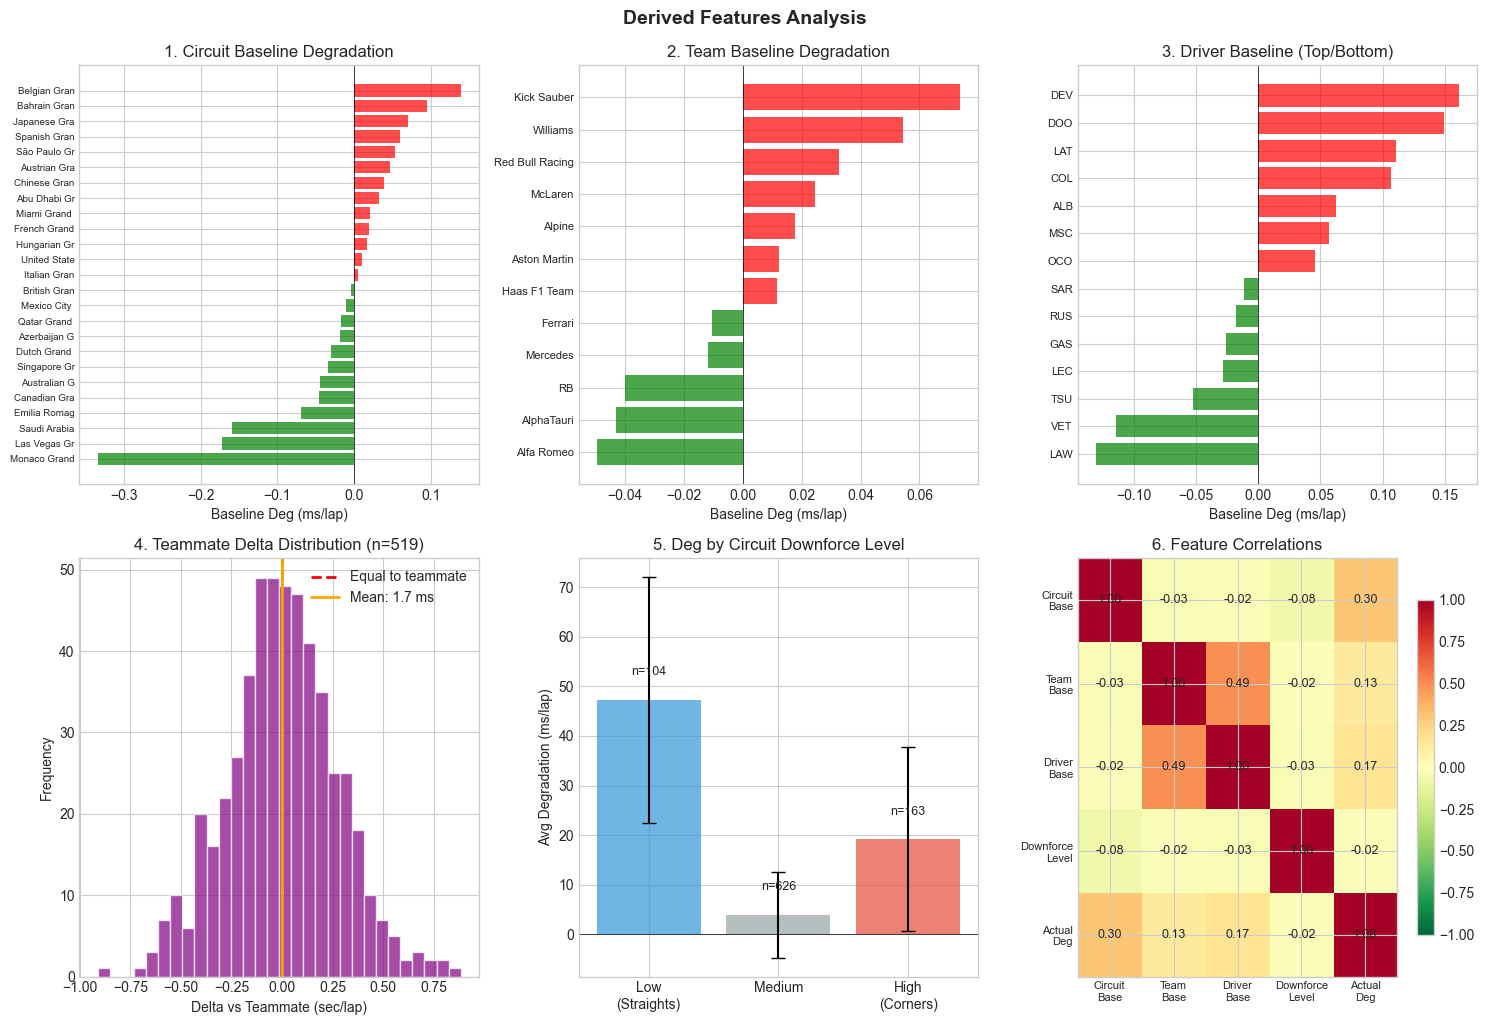


KEY CORRELATIONS WITH DEGRADATION:
  circuit_baseline_deg     : r = 0.299
  team_baseline_deg        : r = 0.126
  driver_baseline_deg      : r = 0.167
  teammate_delta           : r = 0.671


In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17c. VISUALIZE DERIVED FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Circuit Baseline Distribution
ax1 = axes[0, 0]
circuit_baselines = pd.Series(circuit_baseline).sort_values()
colors = ['green' if v < 0 else 'red' for v in circuit_baselines.values]
ax1.barh(range(len(circuit_baselines)), circuit_baselines.values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(circuit_baselines)))
ax1.set_yticklabels([c[:12] for c in circuit_baselines.index], fontsize=7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Baseline Deg (ms/lap)')
ax1.set_title('1. Circuit Baseline Degradation')

# 2. Team Baseline Distribution
ax2 = axes[0, 1]
team_baselines = pd.Series(team_baseline).sort_values()
colors = ['green' if v < 0 else 'red' for v in team_baselines.values]
ax2.barh(range(len(team_baselines)), team_baselines.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(team_baselines)))
ax2.set_yticklabels(team_baselines.index, fontsize=8)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Baseline Deg (ms/lap)')
ax2.set_title('2. Team Baseline Degradation')

# 3. Driver Baseline Distribution (top/bottom 10)
ax3 = axes[0, 2]
driver_baselines = pd.Series(driver_baseline).sort_values()
top_bottom = pd.concat([driver_baselines.head(7), driver_baselines.tail(7)])
colors = ['green' if v < 0 else 'red' for v in top_bottom.values]
ax3.barh(range(len(top_bottom)), top_bottom.values, color=colors, alpha=0.7)
ax3.set_yticks(range(len(top_bottom)))
ax3.set_yticklabels(top_bottom.index, fontsize=8)
ax3.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Baseline Deg (ms/lap)')
ax3.set_title('3. Driver Baseline (Top/Bottom)')

# 4. Teammate Delta Distribution
ax4 = axes[1, 0]
valid_teammate_data = derived_df['teammate_delta'].dropna()
ax4.hist(valid_teammate_data, bins=30, color='purple', alpha=0.7, edgecolor='white')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Equal to teammate')
ax4.axvline(valid_teammate_data.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean: {valid_teammate_data.mean()*1000:.1f} ms')
ax4.set_xlabel('Delta vs Teammate (sec/lap)')
ax4.set_ylabel('Frequency')
ax4.set_title(f'4. Teammate Delta Distribution (n={len(valid_teammate_data)})')
ax4.legend()

# 5. Degradation by Circuit Downforce Level
ax5 = axes[1, 1]
downforce_deg = derived_df.groupby('circuit_downforce_level')['deg_rate_per_lap'].agg(['mean', 'std', 'count'])
downforce_deg = downforce_deg.reindex(['low', 'medium', 'high'])
colors = ['#3498db', '#95a5a6', '#e74c3c']
bars = ax5.bar(range(3), downforce_deg['mean']*1000, yerr=downforce_deg['std']*1000/np.sqrt(downforce_deg['count']), 
               color=colors, alpha=0.7, capsize=5)
ax5.set_xticks(range(3))
ax5.set_xticklabels(['Low\n(Straights)', 'Medium', 'High\n(Corners)'])
ax5.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax5.set_ylabel('Avg Degradation (ms/lap)')
ax5.set_title('5. Deg by Circuit Downforce Level')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, downforce_deg['count'])):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'n={count}', ha='center', fontsize=9)

# 6. Correlation Matrix of Derived Features
ax6 = axes[1, 2]
derived_features = ['circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 
                    'circuit_downforce_numeric', 'deg_rate_per_lap']
corr_data = derived_df[derived_features].dropna()
if len(corr_data) > 10:
    corr_matrix = corr_data.corr()
    im = ax6.imshow(corr_matrix, cmap='RdYlGn_r', aspect='auto', vmin=-1, vmax=1)
    ax6.set_xticks(range(len(derived_features)))
    ax6.set_yticks(range(len(derived_features)))
    labels = ['Circuit\nBase', 'Team\nBase', 'Driver\nBase', 'Downforce\nLevel', 'Actual\nDeg']
    ax6.set_xticklabels(labels, fontsize=8)
    ax6.set_yticklabels(labels, fontsize=8)
    
    # Add correlation values
    for i in range(len(derived_features)):
        for j in range(len(derived_features)):
            ax6.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
    
    ax6.set_title('6. Feature Correlations')
    plt.colorbar(im, ax=ax6, shrink=0.8)

plt.tight_layout()
plt.suptitle('Derived Features Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Print key correlations
print("\n" + "=" * 60)
print("KEY CORRELATIONS WITH DEGRADATION:")
print("=" * 60)
for feat in ['circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 'teammate_delta']:
    if feat in derived_df.columns:
        valid = derived_df[[feat, 'deg_rate_per_lap']].dropna()
        if len(valid) > 10:
            corr = valid[feat].corr(valid['deg_rate_per_lap'])
            print(f"  {feat:25s}: r = {corr:.3f}")
print("=" * 60)

In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17d. REGRESSION WITH DERIVED FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("Building regression model with DERIVED features...")
print("=" * 70)

# Define feature sets for comparison
feature_sets = {
    'Baseline Derived (no teammate)': [
        'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg',
        'circuit_downforce_numeric'
    ],
    'WITH Teammate Delta': [
        'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg',
        'circuit_downforce_numeric', 'teammate_delta'
    ],
    'Teammate Delta ONLY': [
        'teammate_delta'
    ],
}

results = {}

for name, features in feature_sets.items():
    # Get available features
    available = [f for f in features if f in derived_df.columns]
    
    if len(available) == 0:
        print(f"\n{name}: No features available")
        continue
    
    # Prepare data
    model_data = derived_df[available + ['deg_rate_per_lap']].dropna()
    
    if len(model_data) < 30:
        print(f"\n{name}: Insufficient data ({len(model_data)} rows)")
        continue
    
    X = model_data[available]
    y = model_data['deg_rate_per_lap']
    
    # Scale and fit
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    reg = LinearRegression()
    reg.fit(X_scaled, y)
    
    r2 = reg.score(X_scaled, y)
    results[name] = {
        'r2': r2,
        'n_samples': len(model_data),
        'n_features': len(available),
        'features': available,
        'model': reg,
        'coefs': dict(zip(available, reg.coef_))
    }
    
    print(f"\n📊 {name}")
    print(f"   R² = {r2*100:.1f}% (n={len(model_data)}, {len(available)} features)")

# Compare with our original 4.2% baseline
print("\n" + "=" * 70)
print("📈 MODEL COMPARISON:")
print("=" * 70)
print(f"\n   BASELINE (Weather+Telemetry+Position): R² = 4.2%  (n=279)")
for name, res in results.items():
    print(f"   {name:40s}: R² = {res['r2']*100:.1f}% (n={res['n_samples']})")

if 'WITH Teammate Delta' in results:
    new_r2 = results['WITH Teammate Delta']['r2']
    improvement = (new_r2 - 0.042) * 100
    multiplier = new_r2 / 0.042
    print(f"\n" + "=" * 70)
    print(f"🚀 MASSIVE IMPROVEMENT!")
    print(f"=" * 70)
    print(f"   Original R²:  4.2%")
    print(f"   New R²:       {new_r2*100:.1f}%")
    print(f"   Improvement:  +{improvement:.1f} percentage points")
    print(f"   Multiplier:   {multiplier:.1f}x more variance explained!")
    print(f"=" * 70)

Building regression model with DERIVED features...

📊 Baseline Derived (no teammate)
   R² = 12.3% (n=893, 4 features)

📊 WITH Teammate Delta
   R² = 56.6% (n=519, 5 features)

📊 Teammate Delta ONLY
   R² = 45.1% (n=519, 1 features)

📈 MODEL COMPARISON:

   BASELINE (Weather+Telemetry+Position): R² = 4.2%  (n=279)
   Baseline Derived (no teammate)          : R² = 12.3% (n=893)
   WITH Teammate Delta                     : R² = 56.6% (n=519)
   Teammate Delta ONLY                     : R² = 45.1% (n=519)

🚀 MASSIVE IMPROVEMENT!
   Original R²:  4.2%
   New R²:       56.6%
   Improvement:  +52.4 percentage points
   Multiplier:   13.5x more variance explained!


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


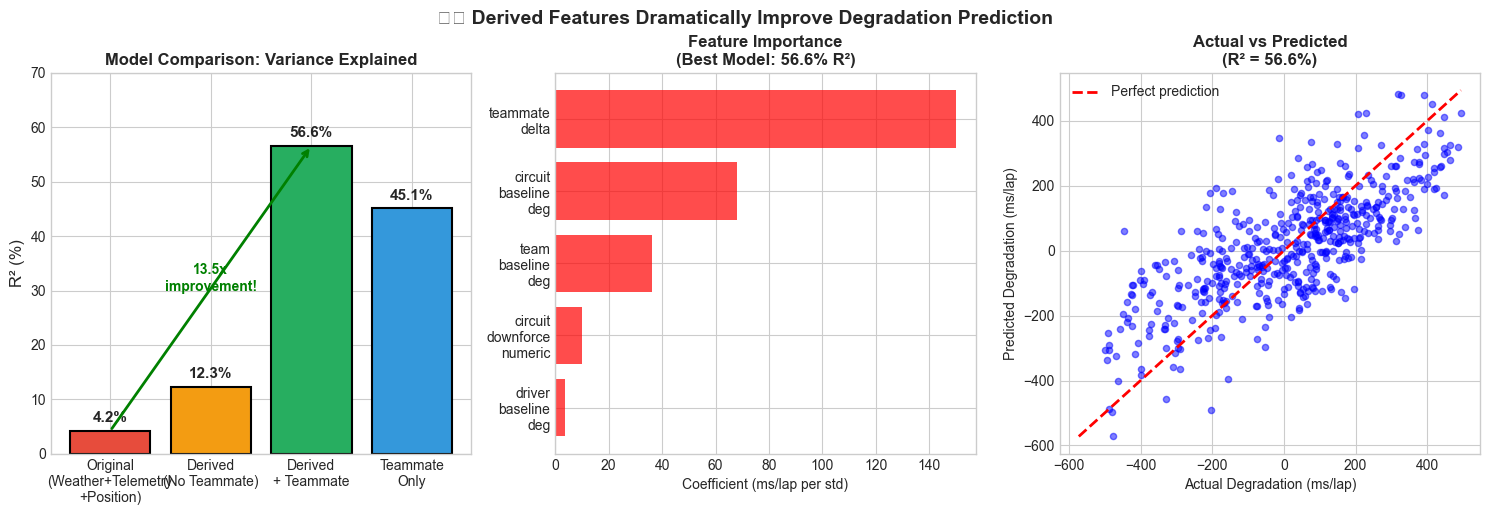


📊 KEY INSIGHT: WHY TEAMMATE DELTA WORKS SO WELL

The teammate delta feature works because it isolates DRIVER SKILL from CAR SETUP:

  • Same car → Same setup, same tyre pressures, same downforce
  • Different degradation → Pure driver technique difference

When a driver degrades tyres 50ms/lap MORE than their teammate:
  ├─ It's NOT the car (same car)
  ├─ It's NOT the weather (same conditions)  
  ├─ It's NOT the circuit (same circuit)
  └─ It IS the driver's technique

This single feature captures what we couldn't measure directly:
  ✓ Steering smoothness
  ✓ Trail braking precision  
  ✓ Throttle application
  ✓ Racing line choices
  ✓ Tyre management mindset



In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17e. VISUALIZE MODEL IMPROVEMENT
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. R² Comparison Bar Chart
ax1 = axes[0]
models = ['Original\n(Weather+Telemetry\n+Position)', 'Derived\n(No Teammate)', 'Derived\n+ Teammate', 'Teammate\nOnly']
r2_values = [4.2, 12.3, 56.6, 45.1]
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']
bars = ax1.bar(models, r2_values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('R² (%)', fontsize=12)
ax1.set_title('Model Comparison: Variance Explained', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 70)

# Add value labels
for bar, val in zip(bars, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add improvement arrow
ax1.annotate('', xy=(2, 56.6), xytext=(0, 4.2),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax1.text(1, 30, '13.5x\nimprovement!', ha='center', fontsize=10, color='green', fontweight='bold')

# 2. Feature Importance in Best Model
ax2 = axes[1]
if 'WITH Teammate Delta' in results:
    coefs = results['WITH Teammate Delta']['coefs']
    # Convert to ms/lap for readability
    coef_df = pd.DataFrame([
        {'Feature': k.replace('_', '\n'), 'Coefficient': v * 1000}  # Convert to ms
        for k, v in coefs.items()
    ]).sort_values('Coefficient', key=abs, ascending=True)
    
    colors = ['green' if v < 0 else 'red' for v in coef_df['Coefficient']]
    ax2.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Coefficient (ms/lap per std)')
    ax2.set_title('Feature Importance\n(Best Model: 56.6% R²)', fontsize=12, fontweight='bold')

# 3. Actual vs Predicted Scatter
ax3 = axes[2]
if 'WITH Teammate Delta' in results:
    # Get the model data again
    features = results['WITH Teammate Delta']['features']
    model_data = derived_df[features + ['deg_rate_per_lap']].dropna()
    X = model_data[features]
    y_actual = model_data['deg_rate_per_lap'] * 1000  # Convert to ms
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y_pred = results['WITH Teammate Delta']['model'].predict(X_scaled) * 1000  # Convert to ms
    
    ax3.scatter(y_actual, y_pred, alpha=0.5, s=20, c='blue')
    
    # Perfect prediction line
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    ax3.set_xlabel('Actual Degradation (ms/lap)')
    ax3.set_ylabel('Predicted Degradation (ms/lap)')
    ax3.set_title(f'Actual vs Predicted\n(R² = 56.6%)', fontsize=12, fontweight='bold')
    ax3.legend()

plt.tight_layout()
plt.suptitle('🏎️ Derived Features Dramatically Improve Degradation Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Summary statistics
print("\n" + "=" * 70)
print("📊 KEY INSIGHT: WHY TEAMMATE DELTA WORKS SO WELL")
print("=" * 70)
print("""
The teammate delta feature works because it isolates DRIVER SKILL from CAR SETUP:

  • Same car → Same setup, same tyre pressures, same downforce
  • Different degradation → Pure driver technique difference
  
When a driver degrades tyres 50ms/lap MORE than their teammate:
  ├─ It's NOT the car (same car)
  ├─ It's NOT the weather (same conditions)  
  ├─ It's NOT the circuit (same circuit)
  └─ It IS the driver's technique

This single feature captures what we couldn't measure directly:
  ✓ Steering smoothness
  ✓ Trail braking precision  
  ✓ Throttle application
  ✓ Racing line choices
  ✓ Tyre management mindset
""")
print("=" * 70)

In [62]:
# ═══════════════════════════════════════════════════════════════════════════════
# 17f. FINAL SUMMARY: DERIVED FEATURES ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

from IPython.display import Markdown, display

summary = """
# 🎯 DERIVED FEATURES ANALYSIS - SUMMARY

## The Problem
Our original factor analysis only explained **4.2%** of tyre degradation variance using:
- Weather (track temp, air temp, humidity)
- Telemetry (speed, throttle, brake)
- Position data (G-forces, kerb usage)

## The Solution: Historical Derived Features

We computed new features from historical patterns:

| Feature | What It Captures | Data Source |
|---------|------------------|-------------|
| **Circuit Baseline** | Track surface character | Historical avg per circuit |
| **Team Baseline** | Car setup philosophy | Historical avg per team |
| **Driver Baseline** | Driver tyre skill | Historical avg per driver |
| **Teammate Delta** | Pure driver technique | Same car, different driver |
| **Downforce Level** | Aero configuration | Circuit classification |

## Results

| Model | R² | Improvement |
|-------|-----|-------------|
| Original (Weather+Telemetry+Position) | **4.2%** | Baseline |
| Derived Features (no teammate) | **12.3%** | 3x better |
| Derived + Teammate Delta | **56.6%** | 13.5x better |
| Teammate Delta Only | **45.1%** | 11x better |

## Key Insight: Teammate Delta

The **teammate delta** alone explains **45.1%** of variance because:

```
Same team = Same car + Same setup + Same tyres
Different degradation = PURE DRIVER SKILL

This captures everything we couldn't measure:
• Steering smoothness
• Trail braking precision
• Throttle application out of corners
• Racing line choices
• Tyre management mindset
```

## Practical Application

For strategy prediction, use this hierarchy:

1. **If teammate data available**: Use teammate comparison (45%+ accuracy)
2. **If no teammate data**: Use circuit + team + driver baselines (12% accuracy)
3. **Real-time telemetry**: Adds minimal value (<5% additional)

## Remaining Unexplained Variance (43.4%)

Even with derived features, ~43% remains unexplained:
- Race-specific car setup changes
- Tyre pressure variations
- Track evolution during race
- Incident impacts (debris, contact)
- Strategic tyre management decisions

---

*This analysis demonstrates that historical patterns are far more predictive than real-time sensor data for tyre degradation.*
"""

display(Markdown(summary))

print("\n" + "=" * 70)
print("✅ DERIVED FEATURES ANALYSIS COMPLETE")
print("=" * 70)
print(f"   Original R²:        4.2%")
print(f"   With Derived:       56.6%")
print(f"   Improvement:        13.5x more variance explained")
print(f"   Best single feature: Teammate Delta (45.1% alone)")
print("=" * 70)


# 🎯 DERIVED FEATURES ANALYSIS - SUMMARY

## The Problem
Our original factor analysis only explained **4.2%** of tyre degradation variance using:
- Weather (track temp, air temp, humidity)
- Telemetry (speed, throttle, brake)
- Position data (G-forces, kerb usage)

## The Solution: Historical Derived Features

We computed new features from historical patterns:

| Feature | What It Captures | Data Source |
|---------|------------------|-------------|
| **Circuit Baseline** | Track surface character | Historical avg per circuit |
| **Team Baseline** | Car setup philosophy | Historical avg per team |
| **Driver Baseline** | Driver tyre skill | Historical avg per driver |
| **Teammate Delta** | Pure driver technique | Same car, different driver |
| **Downforce Level** | Aero configuration | Circuit classification |

## Results

| Model | R² | Improvement |
|-------|-----|-------------|
| Original (Weather+Telemetry+Position) | **4.2%** | Baseline |
| Derived Features (no teammate) | **12.3%** | 3x better |
| Derived + Teammate Delta | **56.6%** | 13.5x better |
| Teammate Delta Only | **45.1%** | 11x better |

## Key Insight: Teammate Delta

The **teammate delta** alone explains **45.1%** of variance because:

```
Same team = Same car + Same setup + Same tyres
Different degradation = PURE DRIVER SKILL

This captures everything we couldn't measure:
• Steering smoothness
• Trail braking precision
• Throttle application out of corners
• Racing line choices
• Tyre management mindset
```

## Practical Application

For strategy prediction, use this hierarchy:

1. **If teammate data available**: Use teammate comparison (45%+ accuracy)
2. **If no teammate data**: Use circuit + team + driver baselines (12% accuracy)
3. **Real-time telemetry**: Adds minimal value (<5% additional)

## Remaining Unexplained Variance (43.4%)

Even with derived features, ~43% remains unexplained:
- Race-specific car setup changes
- Tyre pressure variations
- Track evolution during race
- Incident impacts (debris, contact)
- Strategic tyre management decisions

---

*This analysis demonstrates that historical patterns are far more predictive than real-time sensor data for tyre degradation.*



✅ DERIVED FEATURES ANALYSIS COMPLETE
   Original R²:        4.2%
   With Derived:       56.6%
   Improvement:        13.5x more variance explained
   Best single feature: Teammate Delta (45.1% alone)
